In [1]:
import os
import pandas as pd
import numpy as np
import re

# Load participant metadata (some of the features from the metada can be useful for classification later. Please consider using it in your analysis)##shailendra
participant_info = pd.read_excel("Participant_information_2.xlsx")
participant_info.set_index("Random_id", inplace=True)

# Load eye-tracking data
data_directory = "extracted"
data_dict = {}
for filename in os.listdir(data_directory):
    if filename.endswith(".txt"):
        file_path = os.path.join(data_directory, filename)
        match = re.search(r"participant_(\d+)_trial_(\d+)", filename)
        if match:
            participant_id = int(match.group(1))
            trial_number = int(match.group(2))
            trial_data = np.loadtxt(file_path)
            if trial_data.shape[0] < trial_data.shape[1]:
                trial_data = trial_data.T
            df = pd.DataFrame(trial_data, columns=["time", "x_left", "y_left", "pupil_left", "unused", "category_left"])
            if participant_id in participant_info.index:
                df["Participant_ID"] = participant_id
                df["Group"] = participant_info.loc[participant_id, "Group"]
            if participant_id not in data_dict:
                data_dict[participant_id] = {}
            data_dict[participant_id][trial_number] = df

# Filter out participants with NaN in "Group"
participant_info = participant_info.dropna(subset=["Group"])
adhd_participants = participant_info[participant_info["Group"] == "ADHD"].index.tolist()
td_participants = participant_info[participant_info["Group"] == "TD"].index.tolist()

print(f"Number of ADHD participants: {len(adhd_participants)}")
print(f"Number of TD participants: {len(td_participants)}")

Number of ADHD participants: 60
Number of TD participants: 59


In [67]:
participant_info

,Unnamed: 0,Group,Pilot,PartA_score,z.ASRS_score,SymSpan.PartialScore,z.sspan_score,ravens_score,z.ravens_score,ASD,Frame_rate
Random_id,,,,,,,,,,,
1142,0,ADHD,0,5.0,1.3,26.0,-2.018182,43.478261,10.632411,no,1000
1171,1,ADHD,0,5.0,1.3,16.0,-12.018182,30.434783,-2.411067,no,500
1212,2,TD,0,2.0,-1.3,14.0,-11.000000,21.739130,-6.280193,NaN,500
1379,3,ADHD,0,2.0,-1.7,39.0,10.981818,21.739130,-11.106719,no,1000
1433,4,TD,0,3.0,-0.7,31.0,2.981818,26.086957,-6.758893,NaN,500
...,...,...,...,...,...,...,...,...,...,...,...
9707,114,TD,0,4.0,0.3,22.0,-6.018182,26.086957,-6.758893,NaN,500
9810,115,ADHD,0,3.0,-0.7,27.0,-1.018182,65.217391,32.371541,no,500
9881,116,ADHD,0,6.0,2.3,35.0,6.981818,39.130435,6.284585,no,500


In [2]:
participant_info.iloc[0,10]

1000

In [3]:
participants = pd.read_excel("Participant_information_2.xlsx")


In [4]:
participants

,Unnamed: 0,Random_id,Group,Pilot,PartA_score,z.ASRS_score,SymSpan.PartialScore,z.sspan_score,ravens_score,z.ravens_score,ASD,Frame_rate
0,0,1142,ADHD,0,5.0,1.3,26.0,-2.018182,43.478261,10.632411,no,1000
1,1,1171,ADHD,0,5.0,1.3,16.0,-12.018182,30.434783,-2.411067,no,500
2,2,1212,TD,0,2.0,-1.3,14.0,-11.000000,21.739130,-6.280193,NaN,500
3,3,1379,ADHD,0,2.0,-1.7,39.0,10.981818,21.739130,-11.106719,no,1000
4,4,1433,TD,0,3.0,-0.7,31.0,2.981818,26.086957,-6.758893,NaN,500
...,...,...,...,...,...,...,...,...,...,...,...,...
125,125,5248,NaN,1,NaN,NaN,29.0,0.364293,8.695652,-1.081052,NaN,500
126,126,7311,NaN,1,NaN,NaN,23.0,-0.285527,43.478261,0.987047,NaN,500
127,127,7984,NaN,1,NaN,NaN,28.0,0.255989,47.826087,1.245560,NaN,500
128,128,8308,NaN,1,NaN,NaN,18.0,-0.827043,13.043478,-0.822540,NaN,500


In [5]:
id = 1212

In [6]:
participants.loc[participants['Random_id'] == id, 'Frame_rate'].values[0]

500

In [7]:
data_dict[adhd_participants[0]][0]

,time,x_left,y_left,pupil_left,unused,category_left,Participant_ID,Group
0,1629966.0,313.5,219.2,1012.0,0.0,0.0,1142,ADHD
1,1629967.0,313.6,218.7,1013.0,0.0,0.0,1142,ADHD
2,1629968.0,313.6,219.0,1013.0,0.0,0.0,1142,ADHD
3,1629969.0,313.8,219.6,1011.0,0.0,0.0,1142,ADHD
4,1629970.0,314.0,221.1,1010.0,0.0,0.0,1142,ADHD
...,...,...,...,...,...,...,...,...
27981,1657947.0,427.4,669.7,1091.0,0.0,1.0,1142,ADHD
27982,1657948.0,426.5,669.8,1091.0,0.0,1.0,1142,ADHD
27983,1657949.0,425.9,670.0,1093.0,0.0,1.0,1142,ADHD
27984,1657950.0,425.6,671.2,1095.0,0.0,1.0,1142,ADHD


In [8]:
data_dict[adhd_participants[0]][0].shape

(27986, 8)

# downsampling 

In [9]:
from scipy.interpolate import interp1d
def preprocess_trial(df, frame_rate, target_freq=500, trim_ms=50):
    """
    Preprocess eye-tracking trial data:
    - Downsample to 500 Hz
    - Remove the first and last 50 ms of data
    - Add "Group" column
    """
    # Sort by time
    df = df.sort_values("time").reset_index(drop=True)
    
    # Downsample to 500 Hz (8 ms intervals)
    time_original = df["time"].values
    min_time, max_time = time_original.min(), time_original.max()
    time_step = frame_rate/ target_freq
    new_time = np.arange(np.ceil(min_time / time_step) * time_step, max_time, time_step)
    
    # Interpolate features
    features = ["x_left", "y_left", "pupil_left", "category_left"]
    df_downsampled = pd.DataFrame({"time": new_time})
    for feature in features:
        interp_func = interp1d(time_original, df[feature], 
                              kind='linear' if feature != "category_left" else 'nearest', 
                              fill_value="extrapolate")
        df_downsampled[feature] = interp_func(new_time)
    
    # Trim first and last 50 ms
    trim_start = min_time + trim_ms
    trim_end = max_time - trim_ms
    df_trimmed = df_downsampled[(df_downsampled["time"] >= trim_start) & 
                                (df_downsampled["time"] <= trim_end)].copy()  # Added .copy()
    
    # Add "Group" column
    df_trimmed["Group"] = df["Group"].iloc[0]
    
    return df_trimmed

In [10]:
data_dict[adhd_participants[0]][1]

,time,x_left,y_left,pupil_left,unused,category_left,Participant_ID,Group
0,1669612.0,303.3,208.5,822.0,0.0,0.0,1142,ADHD
1,1669613.0,303.5,211.0,821.0,0.0,0.0,1142,ADHD
2,1669614.0,303.4,213.4,820.0,0.0,0.0,1142,ADHD
3,1669615.0,302.8,213.8,820.0,0.0,0.0,1142,ADHD
4,1669616.0,302.2,214.2,822.0,0.0,0.0,1142,ADHD
...,...,...,...,...,...,...,...,...
9630,1679242.0,249.7,213.5,991.0,0.0,1.0,1142,ADHD
9631,1679243.0,250.9,211.7,991.0,0.0,1.0,1142,ADHD
9632,1679244.0,251.8,213.6,991.0,0.0,1.0,1142,ADHD
9633,1679245.0,251.2,215.7,990.0,0.0,1.0,1142,ADHD


In [11]:
adhd_trial=data_dict[adhd_participants[0]][1]


In [12]:
len(adhd_trial)

9635

In [13]:
frame_rate = participants.loc[participants['Random_id'] == adhd_trial.iloc[0,6], 'Frame_rate'].values[0]

In [14]:
frame_rate

1000

In [15]:
import matplotlib.pyplot as plt

In [16]:
def plot_trajectories(df, msg):
        # Clean data
    plt.figure(figsize=(8, 6))
    plt.plot(df["x_left"], df["y_left"], alpha=1, color='green', label='Gaze Trajectory')
#    plt.gca().invert_yaxis()
    plt.title(f"Gaze Trajectory {msg}")
    plt.xlabel("x_left")
    plt.ylabel("y_left")
    plt.show()
    plt.close()


In [17]:
def clean_outliers(df, x_range = (0, 1920), y_range = (0, 1080)):
    df = df[
        (df["x_left"] >= x_range[0]) & (df["x_left"] <= x_range[1]) &
        (df["y_left"] >= y_range[0]) & (df["y_left"] <= y_range[1])
    ]
    
    return df

In [18]:
def clean_blink(df):
    blink_threshold = df['pupil_left'].quantile(0.01)  # 1st percentile (adjustable)
    # Filter out blinks
    df_cleaned = df.dropna(subset=['pupil_left'])  # Remove rows where pupil size is NaN
    df_cleaned = df_cleaned[df_cleaned['pupil_left'] > 0.001]  # Remove very low pupil sizes
    return df_cleaned

In [19]:
print(len(adhd_trial))

9635


4768


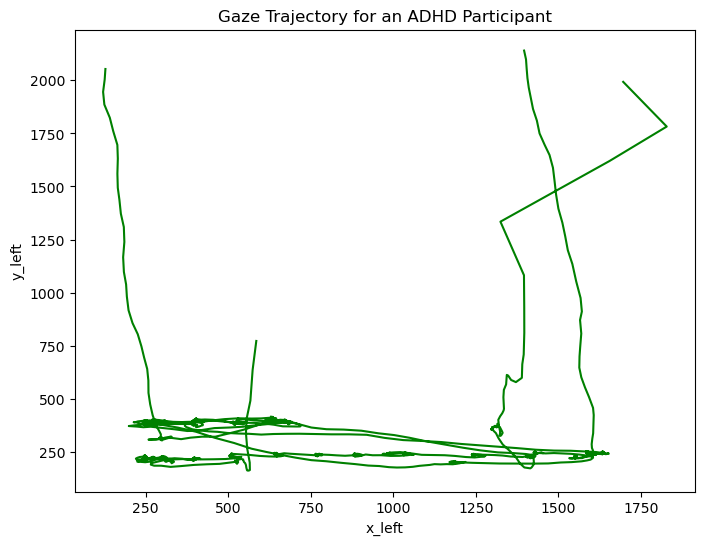

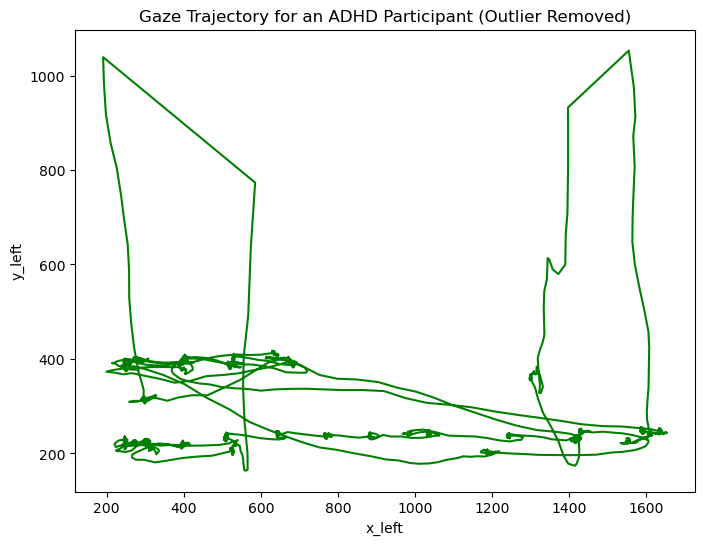

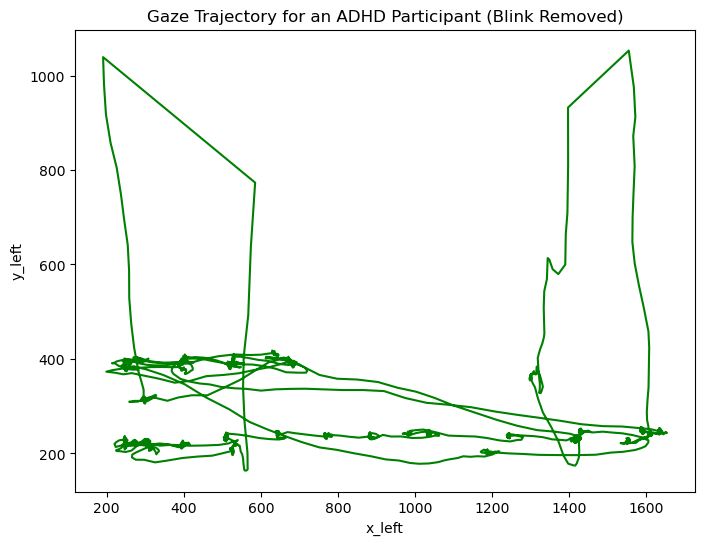

In [20]:
# Apply preprocessing
frame_rate = participants.loc[participants['Random_id'] == data_dict[adhd_participants[0]][1].iloc[0,6], 'Frame_rate'].values[0]
adhd_trial = preprocess_trial(data_dict[adhd_participants[0]][1], frame_rate)
print(len(adhd_trial))
#before cleaning
plot_trajectories(adhd_trial, "for an ADHD Participant")

adhd_trial = clean_outliers(adhd_trial)
#after cleaning outliers
plot_trajectories(adhd_trial, "for an ADHD Participant (Outlier Removed)")


adhd_trial = clean_blink(adhd_trial)
#after_blink_removal
plot_trajectories(adhd_trial, "for an ADHD Participant (Blink Removed)")




In [21]:
len(adhd_trial)

3656

In [22]:
td_trial=data_dict[td_participants[0]][1]


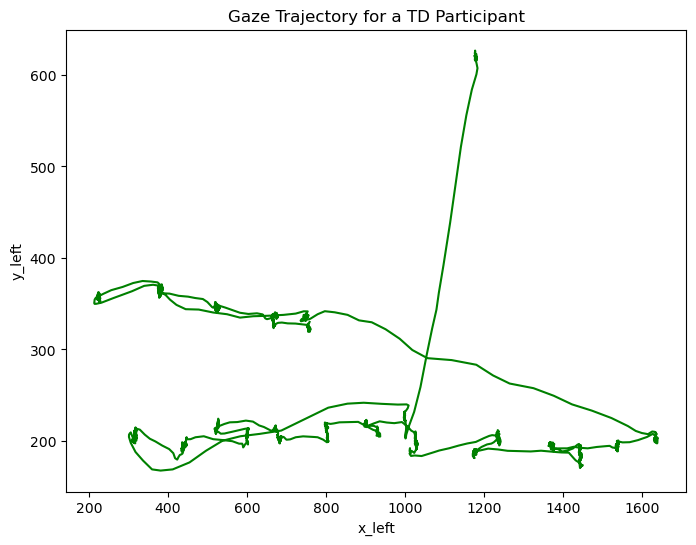

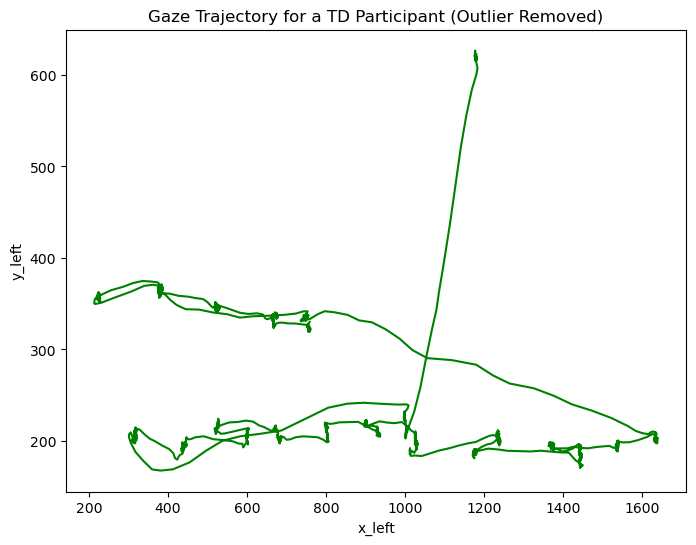

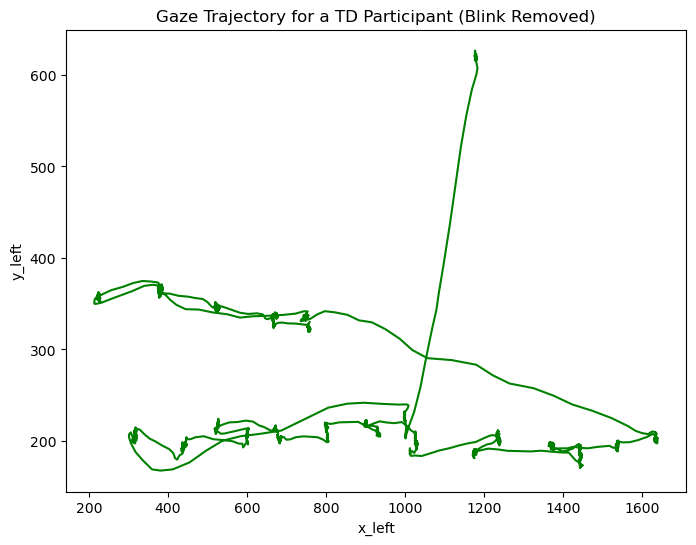

In [23]:
frame_rate = participants.loc[participants['Random_id'] == data_dict[td_participants[0]][1].iloc[0,6], 'Frame_rate'].values[0]
td_trial = preprocess_trial(data_dict[td_participants[0]][1], frame_rate)

#before cleaning
plot_trajectories(td_trial, "for a TD Participant")


td_trial = clean_outliers(td_trial)
#after cleaning outliers
plot_trajectories(td_trial,"for a TD Participant (Outlier Removed)")

td_trial = clean_blink(td_trial)
#after blink removal
plot_trajectories(td_trial, "for a TD Participant (Blink Removed)")



In [24]:
td_trial

,time,x_left,y_left,pupil_left,category_left,Group
50,935520.0,1178.00,621.00,1665.0,1.0,TD
51,935521.0,1177.15,620.95,1665.0,1.0,TD
52,935522.0,1176.30,620.90,1665.0,1.0,TD
53,935523.0,1176.00,620.90,1664.5,1.0,TD
54,935524.0,1175.70,620.90,1664.0,1.0,TD
...,...,...,...,...,...,...
7378,942848.0,758.00,329.50,1577.0,1.0,TD
7379,942849.0,758.10,329.70,1575.5,1.0,TD
7380,942850.0,758.20,329.90,1574.0,1.0,TD
7381,942851.0,758.20,330.00,1573.0,1.0,TD


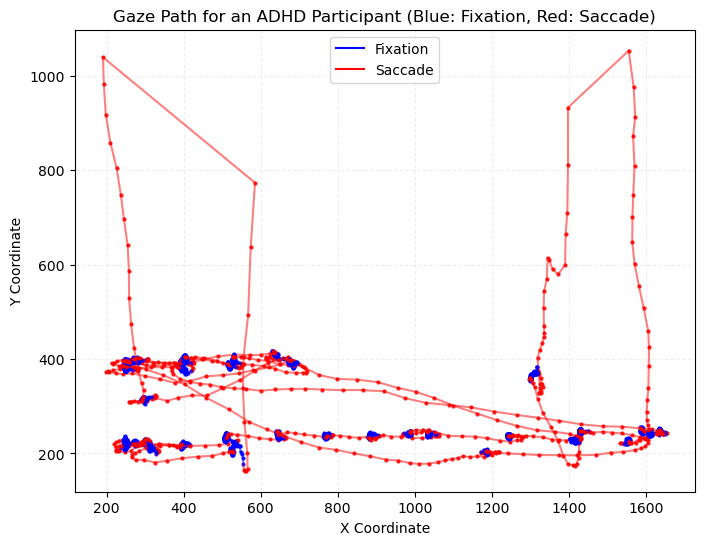

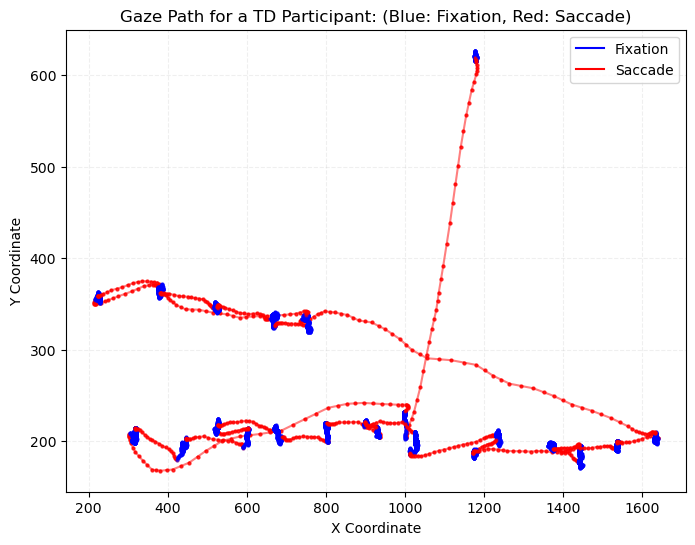

In [25]:
import matplotlib.pyplot as plt

def plot_gaze_path_colored(df, title):
    """Plot gaze path with fixations (blue) and saccades (red)."""
    plt.figure(figsize=(8, 6))
    for i in range(len(df) - 1):
        color = 'blue' if df["category_left"].iloc[i] == 1 else 'red'
        plt.plot(df["x_left"].iloc[i:i+2], df["y_left"].iloc[i:i+2], color=color, alpha=0.5, marker='o', markersize=2)
    plt.title(title)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend(handles=[plt.Line2D([], [], color='blue', label='Fixation'), plt.Line2D([], [], color='red', label='Saccade')])
    plt.grid(True, linestyle='--', alpha=0.2)
    plt.show()

# Plot for ADHD and TD
plot_gaze_path_colored(adhd_trial, "Gaze Path for an ADHD Participant (Blue: Fixation, Red: Saccade)")
plot_gaze_path_colored(td_trial, "Gaze Path for a TD Participant: (Blue: Fixation, Red: Saccade)")

In [26]:
adhd_trial.shape

(3656, 6)

In [27]:
def calculate_velocity_angle_for_participants(df):
    """
    Calculates velocity for all participants from x_left and y_left
    and adds the 'velocity' and 'log_velocity' columns to each participant's DataFrame.
    
    Parameters:
    - dfs_eyetracking: Dictionary of DataFrames, one for each participant.
    
    Returns:
    - dfs_eyetracking: Updated dictionary with velocity columns added to each participant's DataFrame.
    """
        # Calculate differences in X and Y positions
    df['dx'] = df['x_left'].diff()
    df['dy'] = df['y_left'].diff()

        # Calculate velocity (Euclidean distance)
    df['velocity'] = np.sqrt(df['dx']**2 + df['dy']**2)

        # Remove invalid values for velocity
    df['velocity'] = df['velocity'].replace([np.inf, -np.inf], np.nan)
        # Calculate log(velocity), handling invalid cases
    df['log_velocity'] = np.log(df['velocity'].replace(0, np.nan))  # Avoid log(0)
    
    df['angle'] = np.degrees(np.arctan2(df['dy'], df['dx']))

    df['cos2theta'] = np.cos(2*df['angle'])

    df['movement_direction'] = np.select([df['cos2theta'] > 0, df['cos2theta'] < 0], [1, -1])

    # Clean up NaN and inf values
    df.dropna(subset=['dx', 'dy', 'velocity', 'angle', 'log_velocity','cos2theta', 'movement_direction'], inplace=True)

    return df


In [28]:
adhd_trial = calculate_velocity_angle_for_participants(adhd_trial)
td_trial = calculate_velocity_angle_for_participants(td_trial)


In [29]:
adhd_trial

,time,x_left,y_left,pupil_left,category_left,Group,dx,dy,velocity,log_velocity,angle,cos2theta,movement_direction
26,1669664.0,304.4,213.4,822.0,1.0,ADHD,2.1,-4.7,5.147815,1.638572,-65.924502,0.995213,1
27,1669666.0,305.1,218.4,822.0,1.0,ADHD,0.7,5.0,5.048762,1.619143,82.030390,0.766154,1
28,1669668.0,304.3,221.5,821.0,1.0,ADHD,-0.8,3.1,3.201562,1.163639,104.470294,-0.024674,-1
29,1669670.0,302.8,221.0,821.0,1.0,ADHD,-1.5,-0.5,1.581139,0.458145,-161.565051,-0.898726,-1
30,1669672.0,302.6,221.5,821.0,1.0,ADHD,-0.2,0.5,0.538516,-0.618937,111.801409,-0.852660,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4788,1679188.0,246.6,227.4,1022.0,1.0,ADHD,0.4,1.2,1.264911,0.235002,71.565051,0.186538,1
4789,1679190.0,248.0,224.2,1021.0,1.0,ADHD,1.4,-3.2,3.492850,1.250718,-66.370622,0.700746,1
4790,1679192.0,246.0,224.7,1019.0,1.0,ADHD,-2.0,0.5,2.061553,0.723459,165.963757,0.470174,1
4791,1679194.0,243.4,226.9,1017.0,1.0,ADHD,-2.6,2.2,3.405877,1.225503,139.763642,-0.997229,-1


In [30]:
td_trial

,time,x_left,y_left,pupil_left,category_left,Group,dx,dy,velocity,log_velocity,angle,cos2theta,movement_direction
51,935521.0,1177.15,620.95,1665.0,1.0,TD,-0.85,-0.05,0.851469,-0.160792,-176.633539,0.161386,1
52,935522.0,1176.30,620.90,1665.0,1.0,TD,-0.85,-0.05,0.851469,-0.160792,-176.633539,0.161386,1
53,935523.0,1176.00,620.90,1664.5,1.0,TD,-0.30,0.00,0.300000,-1.203973,180.000000,-0.283691,-1
54,935524.0,1175.70,620.90,1664.0,1.0,TD,-0.30,0.00,0.300000,-1.203973,180.000000,-0.283691,-1
55,935525.0,1175.45,620.90,1664.0,1.0,TD,-0.25,0.00,0.250000,-1.386294,180.000000,-0.283691,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7378,942848.0,758.00,329.50,1577.0,1.0,TD,0.95,0.90,1.308625,0.268977,43.451842,0.488078,1
7379,942849.0,758.10,329.70,1575.5,1.0,TD,0.10,0.20,0.223607,-1.497866,63.434949,0.356580,1
7380,942850.0,758.20,329.90,1574.0,1.0,TD,0.10,0.20,0.223607,-1.497866,63.434949,0.356580,1
7381,942851.0,758.20,330.00,1573.0,1.0,TD,0.00,0.10,0.100000,-2.302585,90.000000,-0.598460,-1


In [31]:
def plot_cos2theta(df, msg):
        # Clean data
    plt.figure(figsize=(12,3))
    plt.plot(df["cos2theta"], alpha=1, color='blue', label='Cos2Thata')
    plt.title(f"{msg}")
    plt.xlabel("Time")
    plt.ylabel("Cos2Theta")
    plt.show()
    plt.close()


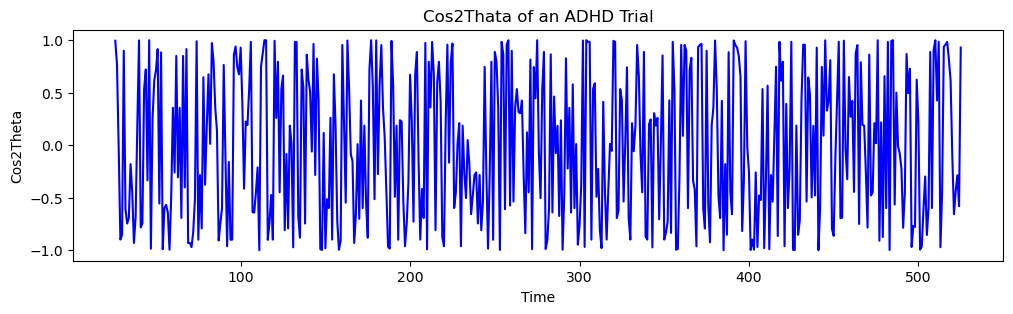

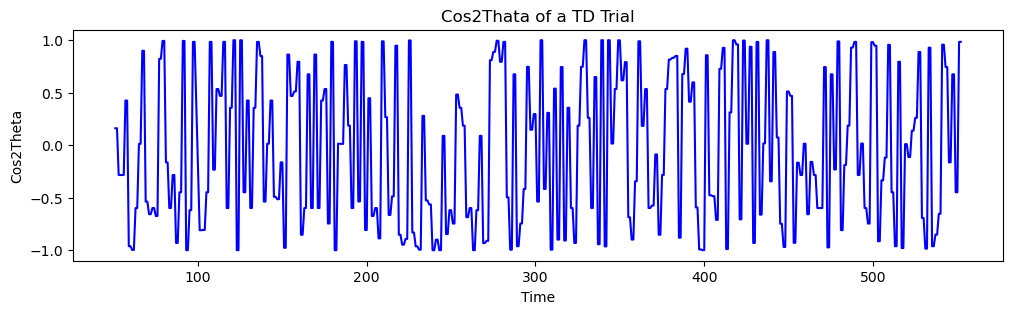

In [32]:
plot_cos2theta(adhd_trial.iloc[:500], "Cos2Thata of an ADHD Trial")
plot_cos2theta(td_trial.iloc[:500], "Cos2Thata of a TD Trial")

In [33]:
def plot_movement(df, msg):
        # Clean data
    plt.figure(figsize=(12,3))
    plt.plot(df["movement_direction"], alpha=1, color='blue', label='Movement')
    plt.title(f"{msg}")
    plt.xlabel("Time")
    plt.ylabel("Direction")
    plt.show()
    plt.close()


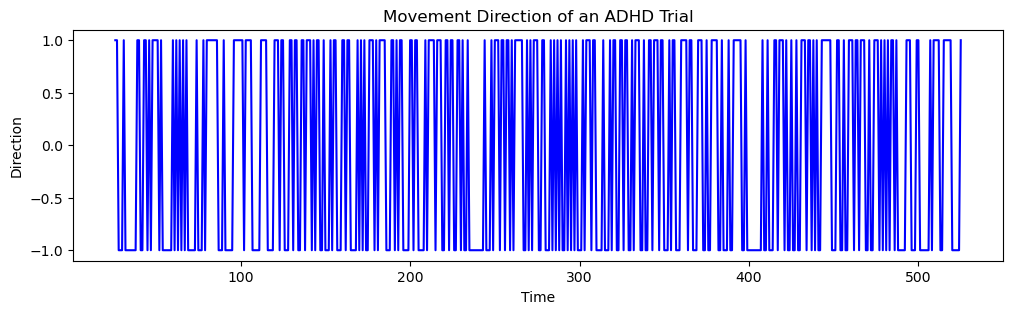

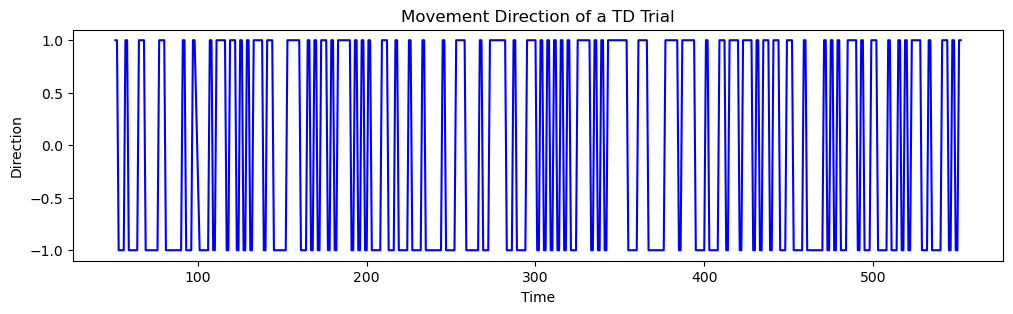

In [34]:
plot_movement(adhd_trial.iloc[:500], "Movement Direction of an ADHD Trial")
plot_movement(td_trial.iloc[:500], "Movement Direction of a TD Trial")

In [35]:
ones_count = (adhd_trial['movement_direction'].iloc[:500]==1).sum().sum()  # Total count of ones
minus_count = (adhd_trial['movement_direction'].iloc[:500]== -1).sum().sum() # Total count of minus ones
print("Horizontal Movements (ADHD): ", ones_count)
print("Vertical Movements (ADHD): ",minus_count)


Horizontal Movements (ADHD):  244
Vertical Movements (ADHD):  256


In [36]:
ones_count = (td_trial['movement_direction'].iloc[:500]== 1).sum().sum()  # Total count of ones
minus_count = (td_trial['movement_direction'].iloc[:500]== -1).sum().sum() # Total count of minus ones
print("Horizontal Movements (td): ", ones_count)
print("Vertical Movements (td): ",minus_count)


Horizontal Movements (td):  242
Vertical Movements (td):  258


In [37]:
def plot_velocity_histograms_for_a_participant(df, msg, bins=50):
    """
    Plots log(velocity) histograms for multiple participants.
    
    Parameters:
    - dfs_eyetracking: Dictionary of DataFrames, one for each participant.
    - bins: Number of bins for the histogram.
    - max_plots: Maximum number of participants to plot (default: 5).
    """
        # Plot histogram of log(velocity)
    plt.figure(figsize=(10, 6))
    plt.hist(df['log_velocity'], bins=bins, edgecolor='black', alpha=0.8)
    plt.title(f"log(Velocity) Distribution for a Participant ({msg})")
    plt.xlabel("log(Velocity)", fontsize=12, fontweight='bold')
    plt.ylabel("Frequency", fontsize=12, fontweight='bold')
    plt.show()


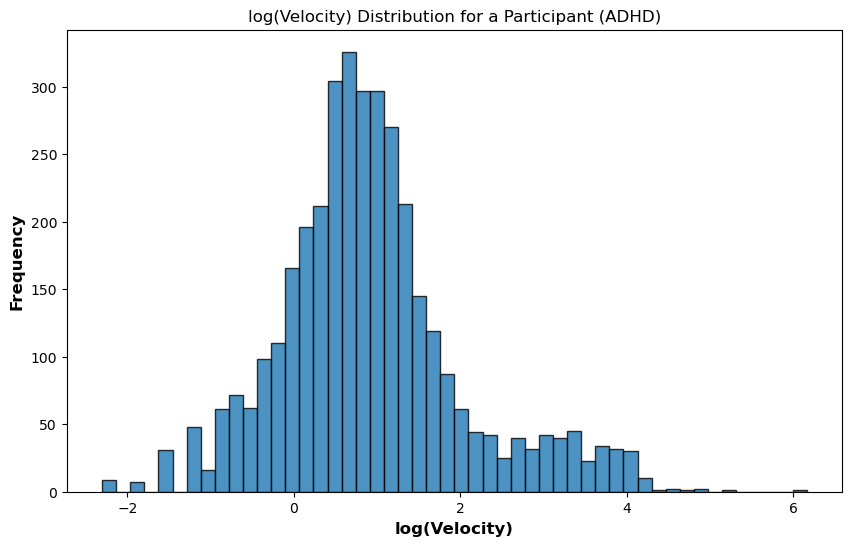

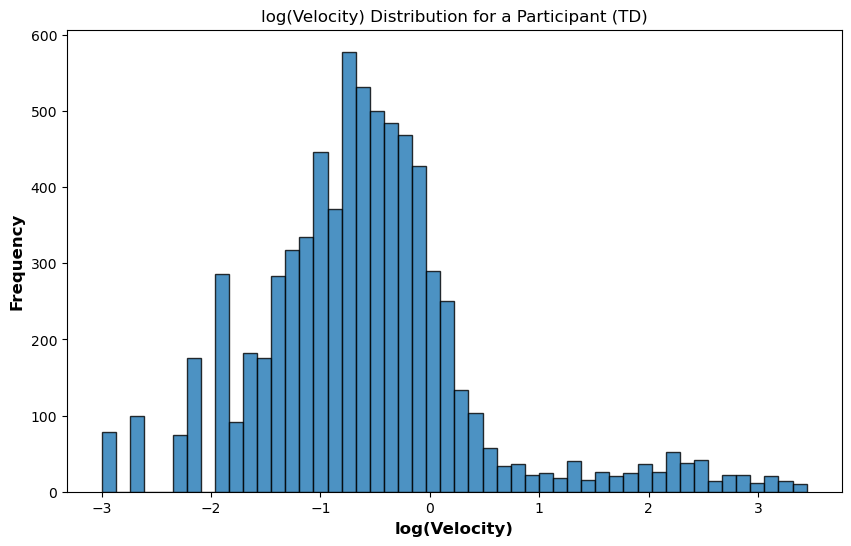

In [38]:
plot_velocity_histograms_for_a_participant(adhd_trial, "ADHD")
plot_velocity_histograms_for_a_participant(td_trial, "TD")


In [39]:
def plot_angle_histograms_for_a_participant(df, msg, bins=180):
    """
    Plots log(velocity) histograms for multiple participants.
    
    Parameters:
    - dfs_eyetracking: Dictionary of DataFrames, one for each participant.
    - bins: Number of bins for the histogram.
    - max_plots: Maximum number of participants to plot (default: 5).
    """
        # Plot histogram of log(velocity)
    plt.figure(figsize=(10, 6))
    plt.hist(df['angle'], bins=bins, edgecolor='black', alpha=0.8)
    plt.title(f"Angle Distribution for a Participant ({msg})")
    plt.xlabel("Angle", fontsize=12, fontweight='bold')
    plt.ylabel("Frequency", fontsize=12, fontweight='bold')
    plt.show()

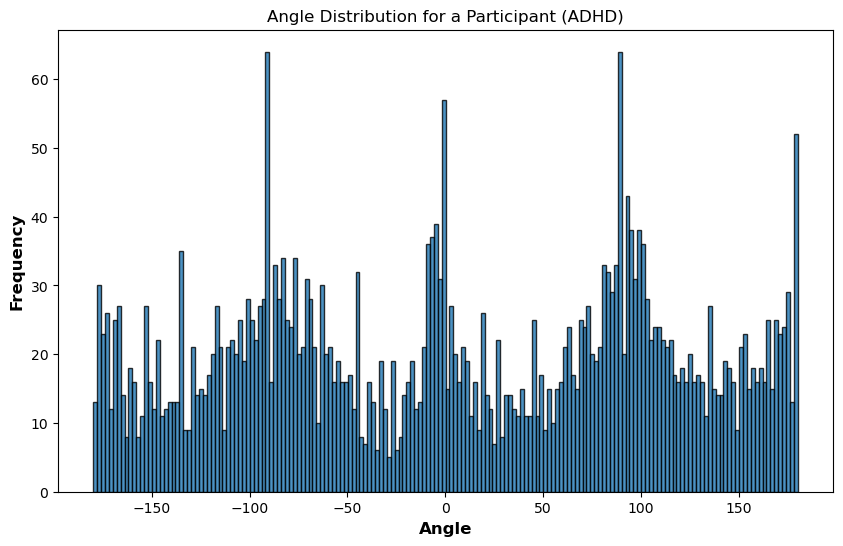

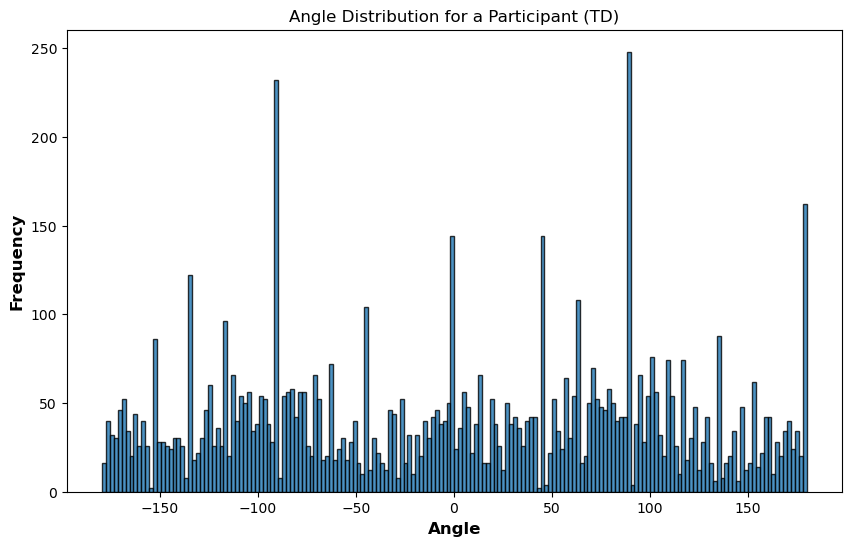

In [40]:
plot_angle_histograms_for_a_participant(adhd_trial, "ADHD")
plot_angle_histograms_for_a_participant(td_trial, "TD")

In [41]:
def plot_pupil_histograms_for_a_participant(df,  msg, bins=50):
    """
    Plots log(velocity) histograms for multiple participants.
    
    Parameters:
    - dfs_eyetracking: Dictionary of DataFrames, one for each participant.
    - bins: Number of bins for the histogram.
    - max_plots: Maximum number of participants to plot (default: 5).
    """
        # Plot histogram of log(velocity)
    plt.figure(figsize=(10, 6))
    plt.hist(df['pupil_left'], bins=bins, edgecolor='black', alpha=0.8)
    plt.title(f"Pupil Distribution for a Participant ({msg})")
    plt.xlabel("Pupil Size", fontsize=12, fontweight='bold')
    plt.ylabel("Frequency", fontsize=12, fontweight='bold')
    plt.show()


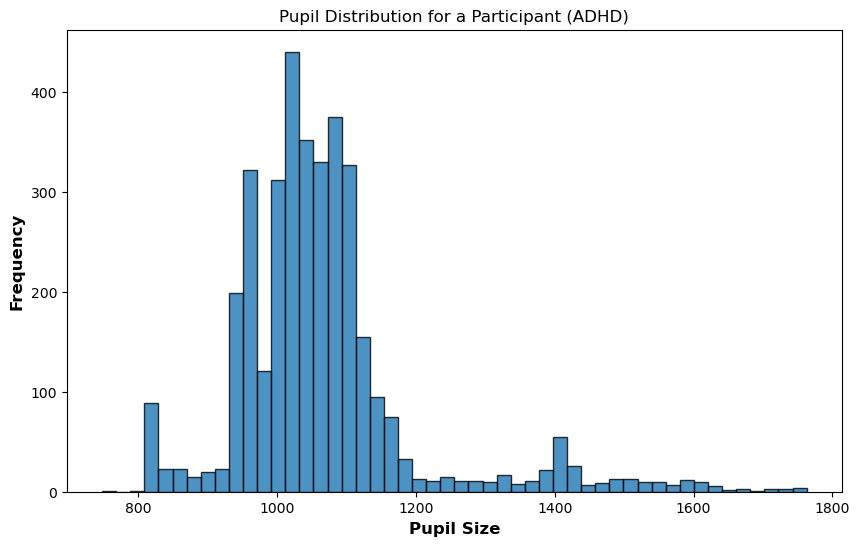

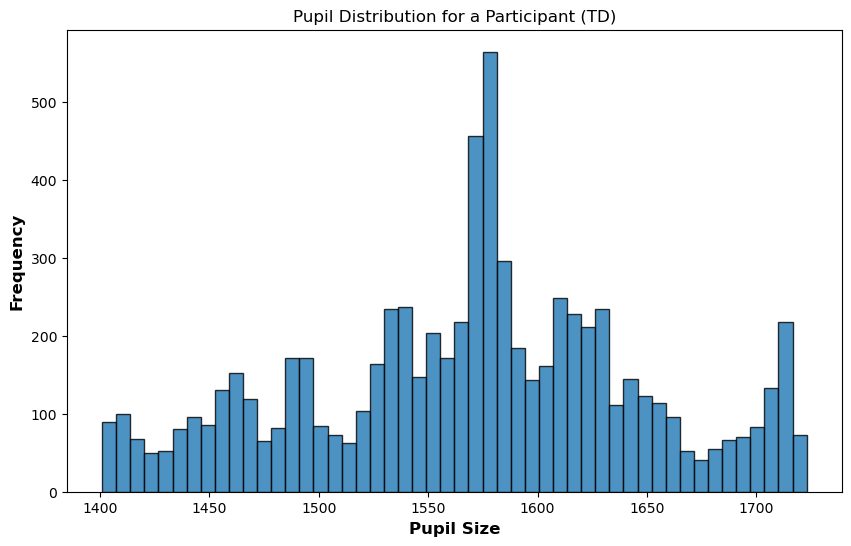

In [42]:
plot_pupil_histograms_for_a_participant(adhd_trial, "ADHD")
plot_pupil_histograms_for_a_participant(td_trial, "TD")

In [43]:
from scipy.signal import correlate

In [44]:
def plot_cross_correlation_valocity_pupil(df, msg):
    velocity = df['velocity'].values
    pupil_left = df['pupil_left'].values

    # Step 3: Detrend the data (optional but helps for clearer cross-correlation)
    velocity = (velocity - np.mean(velocity)) / np.std(velocity)
    pupil_left = (pupil_left - np.mean(pupil_left)) / np.std(pupil_left)

    # Step 4: Compute cross-correlation
    lags = np.arange(-len(velocity) + 1, len(velocity))
    cross_corr = correlate(velocity, pupil_left, mode='full')

    # Normalize the cross-correlation
    cross_corr /= len(velocity)


    # Step 5: Find peak correlation and corresponding lag
    max_corr_idx = np.argmax(cross_corr)
    max_corr_value = cross_corr[max_corr_idx]
    max_corr_lag = lags[max_corr_idx]

    # Print correlation coefficients
    print(f"Maximum Cross-Correlation Coefficient: {max_corr_value:.4f}")
    print(f"Corresponding Lag: {max_corr_lag}")
    # Step 6: Plot the cross-correlation
    plt.figure(figsize=(12, 6))
    plt.plot(lags, cross_corr, color='red')
    plt.title(f"Cross-Correlation between Velocity and Pupil for a Participant ({msg})")
    plt.xlabel('Lag')
    plt.ylabel('Cross-Correlation Coefficient')
    plt.legend()
    plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Maximum Cross-Correlation Coefficient: 0.2617
Corresponding Lag: -17


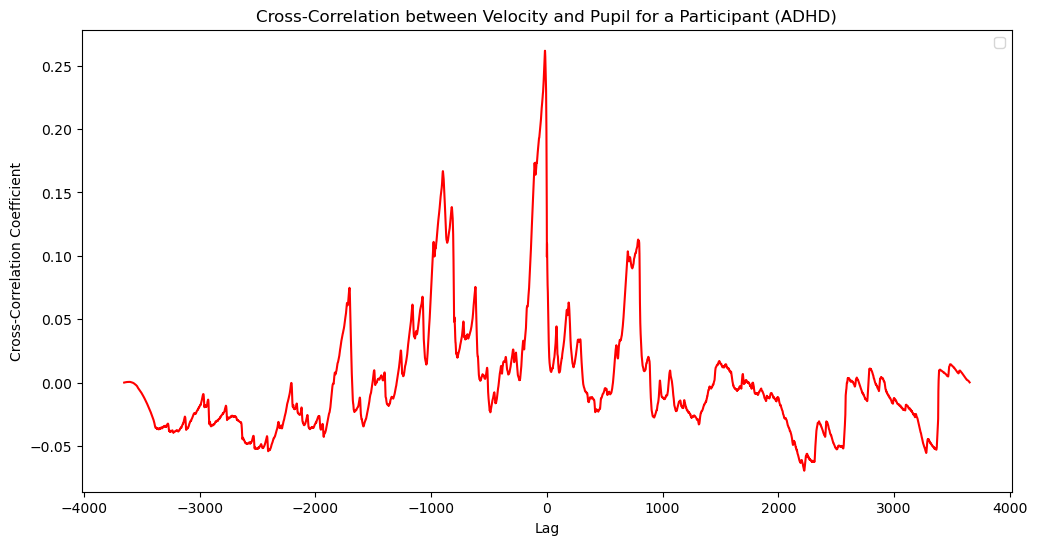

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Maximum Cross-Correlation Coefficient: 0.1121
Corresponding Lag: -3330


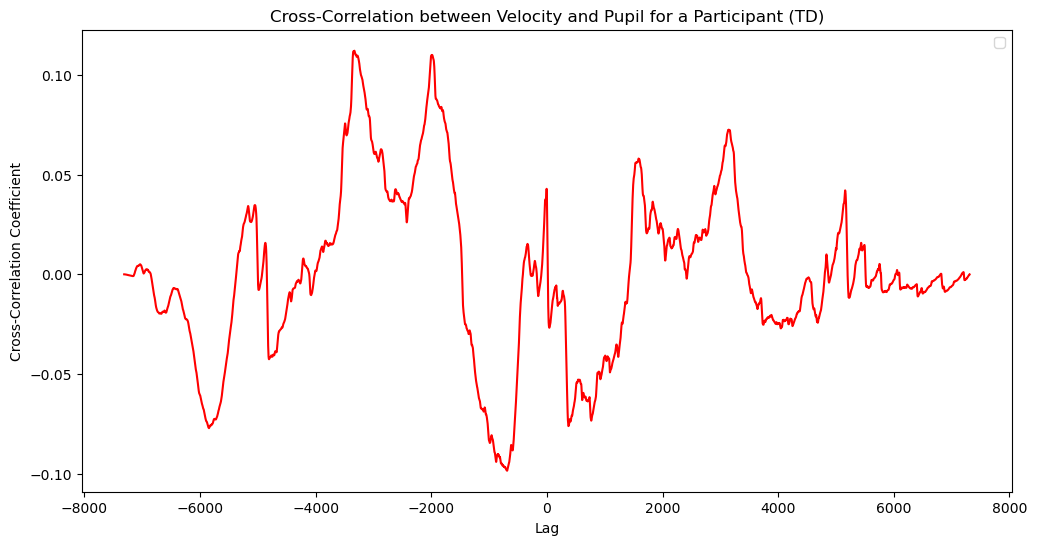

In [45]:
plot_cross_correlation_valocity_pupil(adhd_trial, "ADHD")
plot_cross_correlation_valocity_pupil(td_trial, "TD")


In [46]:
print(f"Number of ADHD participants: {len(adhd_participants)}")
print(f"Number of Trials: {adhd_trial.shape}")


Number of ADHD participants: 60
Number of Trials: (3654, 13)


In [47]:
def maxcross_correlation_valocity_pupil(df):
    velocity = df['velocity'].values
    pupil_left = df['pupil_left'].values

    # Step 3: Detrend the data (optional but helps for clearer cross-correlation)
    velocity = (velocity - np.mean(velocity)) / np.std(velocity)
    pupil_left = (pupil_left - np.mean(pupil_left)) / np.std(pupil_left)

    # Step 4: Compute cross-correlation
    lags = np.arange(-len(velocity) + 1, len(velocity))
    cross_corr = correlate(velocity, pupil_left, mode='full')

    # Normalize the cross-correlation
    cross_corr /= len(velocity)


    # Step 5: Find peak correlation and corresponding lag
    max_corr_idx = np.argmax(cross_corr)
    max_corr_value = cross_corr[max_corr_idx]
    return max_corr_value


In [48]:
def mincross_correlation_valocity_pupil(df):
    velocity = df['velocity'].values
    pupil_left = df['pupil_left'].values

    # Step 3: Detrend the data (optional but helps for clearer cross-correlation)
    velocity = (velocity - np.mean(velocity)) / np.std(velocity)
    pupil_left = (pupil_left - np.mean(pupil_left)) / np.std(pupil_left)

    # Step 4: Compute cross-correlation
    lags = np.arange(-len(velocity) + 1, len(velocity))
    cross_corr = correlate(velocity, pupil_left, mode='full')

    # Normalize the cross-correlation
    cross_corr /= len(velocity)


    # Step 5: Find peak correlation and corresponding lag
    min_corr_idx = np.argmin(cross_corr)
    min_corr_value = cross_corr[min_corr_idx]
    return min_corr_value


In [49]:
from scipy.stats import skew, kurtosis


In [50]:
from scipy.stats import skew, kurtosis
frame_rate = participants.loc[participants['Random_id'] == data_dict[adhd_participants[0]][1].iloc[0,6], 'Frame_rate'].values[0]
adhd_trial = preprocess_trial(data_dict[adhd_participants[0]][1], frame_rate)
adhd_trial = clean_outliers(adhd_trial)
adhd_trial = clean_blink(adhd_trial)
adhd_trial=calculate_velocity_angle_for_participants(adhd_trial)


In [51]:
adhd_trial

,time,x_left,y_left,pupil_left,category_left,Group,dx,dy,velocity,log_velocity,angle,cos2theta,movement_direction
26,1669664.0,304.4,213.4,822.0,1.0,ADHD,2.1,-4.7,5.147815,1.638572,-65.924502,0.995213,1
27,1669666.0,305.1,218.4,822.0,1.0,ADHD,0.7,5.0,5.048762,1.619143,82.030390,0.766154,1
28,1669668.0,304.3,221.5,821.0,1.0,ADHD,-0.8,3.1,3.201562,1.163639,104.470294,-0.024674,-1
29,1669670.0,302.8,221.0,821.0,1.0,ADHD,-1.5,-0.5,1.581139,0.458145,-161.565051,-0.898726,-1
30,1669672.0,302.6,221.5,821.0,1.0,ADHD,-0.2,0.5,0.538516,-0.618937,111.801409,-0.852660,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4788,1679188.0,246.6,227.4,1022.0,1.0,ADHD,0.4,1.2,1.264911,0.235002,71.565051,0.186538,1
4789,1679190.0,248.0,224.2,1021.0,1.0,ADHD,1.4,-3.2,3.492850,1.250718,-66.370622,0.700746,1
4790,1679192.0,246.0,224.7,1019.0,1.0,ADHD,-2.0,0.5,2.061553,0.723459,165.963757,0.470174,1
4791,1679194.0,243.4,226.9,1017.0,1.0,ADHD,-2.6,2.2,3.405877,1.225503,139.763642,-0.997229,-1


In [52]:
adhd_trial_features = participants.loc[participants['Random_id'] == adhd_participants[0]].iloc[:,4:10]
adhd_trial_features=adhd_trial_features.values.tolist()[0]

for col in ['x_left', 'y_left', 'pupil_left', 'dx', 'dy','log_velocity','angle','cos2theta']:
    adhd_trial_features.append(adhd_trial[col].mean())
    adhd_trial_features.append(adhd_trial[col].std())
    adhd_trial_features.append(adhd_trial[col].min())
    adhd_trial_features.append(adhd_trial[col].max())
    adhd_trial_features.append(skew(adhd_trial[col]))
    adhd_trial_features.append(kurtosis(adhd_trial[col]))

        
adhd_trial_features.append(maxcross_correlation_valocity_pupil(adhd_trial)) #max corr between logvel, pupil
adhd_trial_features.append(mincross_correlation_valocity_pupil(adhd_trial)) #max corr between logvel, pupil
adhd_trial_features.append((adhd_trial['category_left']==1.0).sum())  #fixation
adhd_trial_features.append((adhd_trial['category_left']!=1).sum())  #succade 


In [54]:
td_trial_features = participants.loc[participants['Random_id'] == td_participants[0]].iloc[:,4:10]
td_trial_features=td_trial_features.values.tolist()[0]
for col in ['x_left', 'y_left', 'pupil_left', 'dx', 'dy','log_velocity','angle','cos2theta']:
    td_trial_features.append(td_trial[col].mean())
    td_trial_features.append(td_trial[col].std())
    td_trial_features.append(td_trial[col].min())
    td_trial_features.append(td_trial[col].max())
    td_trial_features.append(skew(td_trial[col]))
    td_trial_features.append(kurtosis(td_trial[col]))

        
td_trial_features.append(maxcross_correlation_valocity_pupil(td_trial))
td_trial_features.append(mincross_correlation_valocity_pupil(td_trial))
td_trial_features.append((td_trial['category_left']==1.0).sum())  #fixation
td_trial_features.append((td_trial['category_left']!=1.0).sum())  #succade 


In [56]:
len(adhd_participants)

60

In [57]:
Y = []
m = len(adhd_participants)  # Total number of participants
n = 37  # Total number of trials per participant (0 to 36)

overall_features = [[] for _ in range(m)]  # Initialize feature storage for n trials

for i in range(m):  # Loop over all participants
    frame_rate = participants.loc[participants['Random_id'] == adhd_participants[i], 'Frame_rate'].values[0]

    features = [[] for _ in range(n)]  # Initialize feature storage for n trials

    for j in range(n):  # Loop over all trials
        
        # Get trial data
        df = data_dict[adhd_participants[i]][j]

        #get participant id
        participant_id = df.iloc[0, 6]

        if (len(df)<frame_rate):
            print(participant_id,len(df),j)
            continue


        # Get participant ID (assuming participant ID is in column 6 and in the first row)
        
        # Preprocess data
        df = preprocess_trial(df, frame_rate)
        df = clean_outliers(df)
        df = clean_blink(df)
        df = calculate_velocity_angle_for_participants(df)

        # Extract features
        for col in ['x_left', 'y_left', 'pupil_left', 'dx', 'dy', 'log_velocity', 'angle', 'cos2theta']:
            if col in df.columns:
                features[j].extend([
                    df[col].mean(),df[col].median(), df[col].std(), df[col].min(), df[col].max(),
                    skew(df[col]), kurtosis(df[col])
                ])

        # Additional correlation features
        features[j].append(maxcross_correlation_valocity_pupil(df))
        features[j].append(mincross_correlation_valocity_pupil(df))
        features[j].append((df['category_left'] == 0).sum())  # Fixation count
        features[j].append((df['category_left'] == 1).sum())  # Saccade count

        # Get metadata features
        metafeatures = participants.loc[participants['Random_id'] == participant_id].values[0][4:10]
        features[j].extend(metafeatures)
    #feature size is  37x58
    
    #if any trial is empty then drop it
    features = [sublist for sublist in features if len(sublist) > 0]
    
    mean_features = [sum(x) / len(x) for x in zip(*features)]
    overall_features[i].extend(mean_features)
    
    #Category ADHD is 1 for machine learning     
    Y.append(1)

#Store all features for this participant  
adhd_features = overall_features
#X = overall_features

In [58]:
len(adhd_participants)

60

In [59]:
len(td_participants)

59

In [60]:
m = len(td_participants)  # Total number of participants
n = 37  # Total number of trials per participant (0 to 36)

overall_features = [[] for _ in range(m)]  # Initialize feature storage for n trials
count = 0

for i in range(m):  # Loop over all participants
    frame_rate = participants.loc[participants['Random_id'] == td_participants[i], 'Frame_rate'].values[0]

    features = [[] for _ in range(n)]  # Initialize feature storage for n trials
    for j in range(n):  # Loop over all trials
        
        # Get trial data
        df = data_dict[td_participants[i]][j]
        #get participant id
        participant_id = df.iloc[0, 6]

        if (len(df)<frame_rate):
            print(participant_id,len(df),j)
            continue

       
        # Preprocess data
        df = preprocess_trial(df, frame_rate)
        df = clean_outliers(df)
        df = clean_blink(df)
        df = calculate_velocity_angle_for_participants(df)

        # Extract features
        for col in ['x_left', 'y_left', 'pupil_left', 'dx', 'dy', 'log_velocity', 'angle', 'cos2theta']:
            if col in df.columns:
                features[j].extend([
                    df[col].mean(),df[col].median(), df[col].std(), df[col].min(), df[col].max(),
                    skew(df[col]), kurtosis(df[col])
                ])

        # Additional correlation features
        features[j].append(maxcross_correlation_valocity_pupil(df))
        features[j].append(mincross_correlation_valocity_pupil(df))
        features[j].append((df['category_left'] == 0).sum())  # Fixation count
        features[j].append((df['category_left'] == 1).sum())  # Saccade count

        # Get metadata features
        metafeatures = participants.loc[participants['Random_id'] == participant_id].values[0][4:10]
        features[j].extend(metafeatures)
        
    #only take those features for the trials that are not empty
    #create a sublist with only avialvlae features 
    #assign the sublist to features list. 
    features = [sublist for sublist in features if len(sublist) > 0]
    mean_features = [sum(x) / len(x) for x in zip(*features)]
    overall_features[i].extend(mean_features)
    Y.append(0)
    # Store all features for this participant

#    metafeatures[i].append(participants.loc[participants['Random_id'] == participant_id].values[0][4:10])
 
td_features = overall_features
    
#X.extend(overall_features)

1212 48 25


In [63]:
adhd_features = np.array(adhd_features)
td_features = np.array(td_features)

# Combine horizontally (column-wise)
X = np.vstack((adhd_features, td_features))
Y = np.array(Y)

In [71]:
Feature_names = [
    "X_Mean", "X_Median", "X_Std", "X_Min", "X_Max", "X_Skewness", "X_Kurtosis",
    "Y_Mean", "Y_Median", "Y_Std", "Y_Min", "Y_Max", "Y_Skewness", "Y_Kurtosis",
    "Pupil_Mean", "Pupil_Median", "Pupil_Std", "Pupil_Min", "Pupil_Max", "Pupil_Skewness", "Pupil_Kurtosis",
    "Diff_X_Mean", "Diff_X_Median", "Diff_X_Std", "Diff_X_Min", "Diff_X_Max", "Diff_X_Skewness", "Diff_X_Kurtosis",
    "Diff_Y_Mean", "Diff_Y_Median", "Diff_Y_Std", "Diff_Y_Min", "Diff_Y_Max", "Diff_Y_Skewness", "Diff_Y_Kurtosis",
    "Log_Velocity_Mean", "Log_Velocity_Median", "Log_Velocity_Std", "Log_Velocity_Min", "Log_Velocity_Max", "Log_Velocity_Skewness", "Log_Velocity_Kurtosis",
    "Angle_Mean", "Angle_Median", "Angle_Std", "Angle_Min", "Angle_Max", "Angle_Skewness", "Angle_Kurtosis",
    "Cos2Theta_Mean", "Cos2Theta_Median", "Cos2Theta_Std", "Cos2Theta_Min", "Cos2Theta_Max", "Cos2Theta_Skewness", "Cos2Theta_Kurtosis",
    "Max_Cross_Correlation", "Min_Cross_Correlation", "Fixation_Length", "Succade_Length",
    "PartA_score", "z.ASRS_score", "SymSpan.PartialScore", "z.sspan_score", "ravens_score", "z.ravens_score"
]


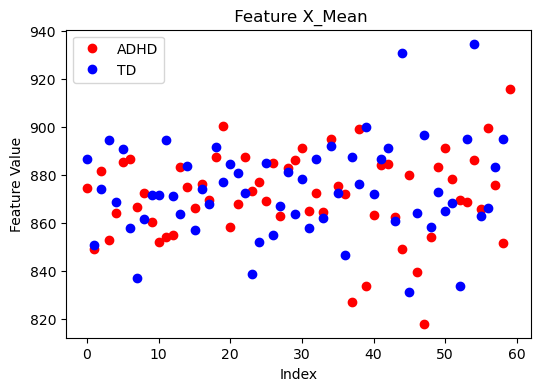

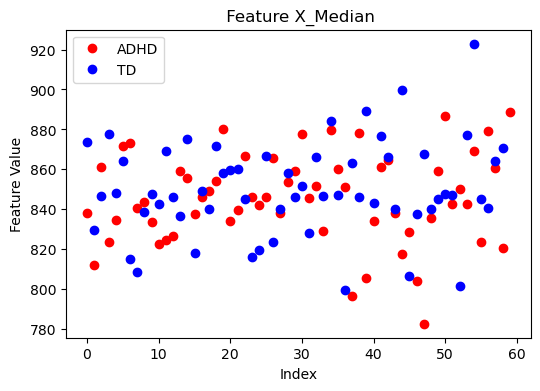

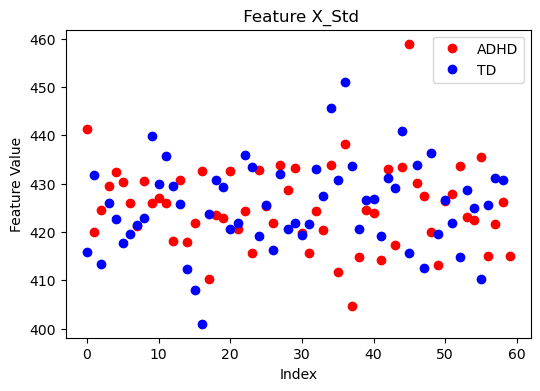

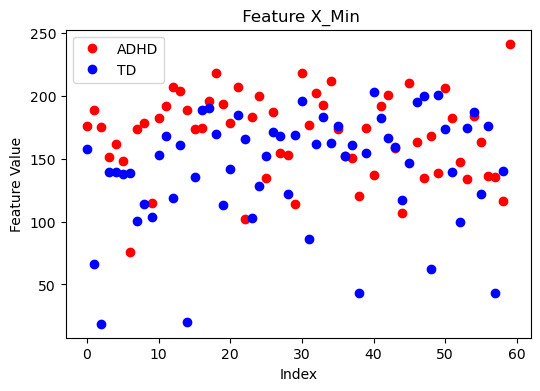

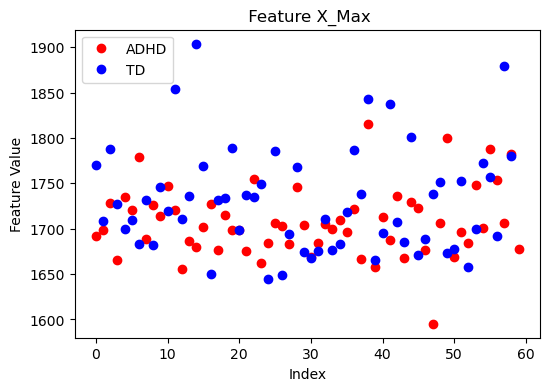

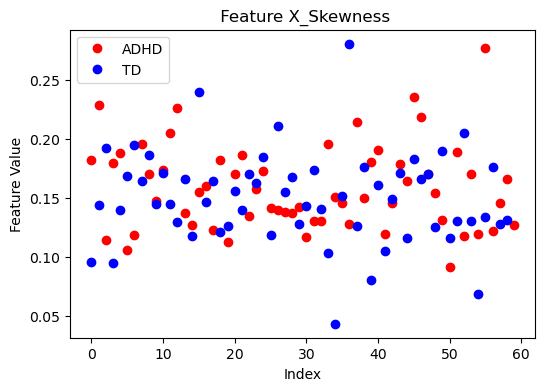

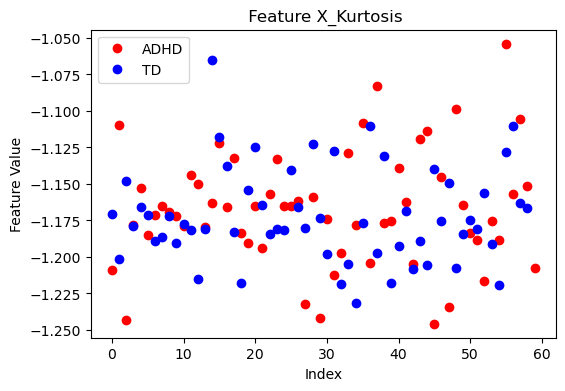

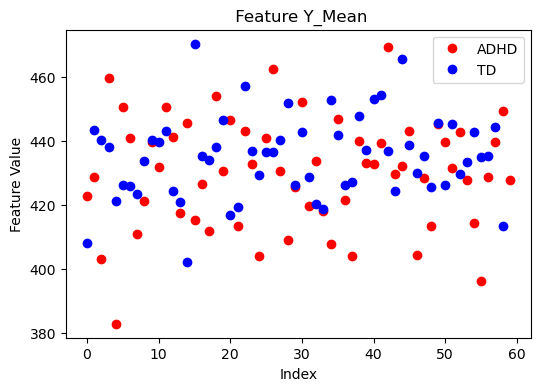

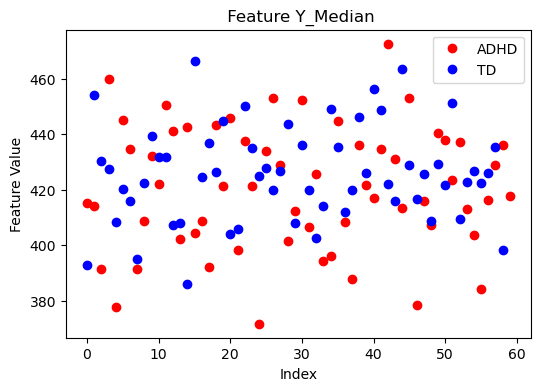

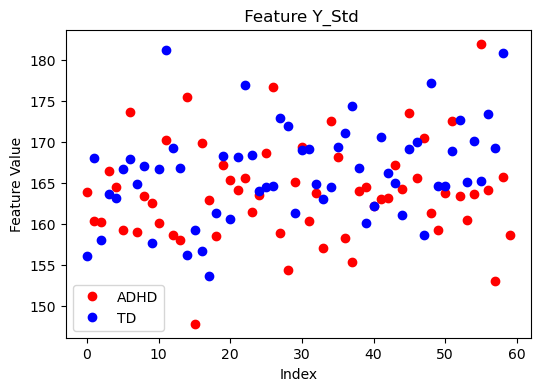

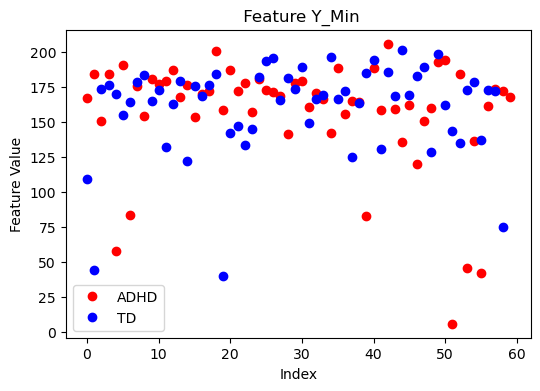

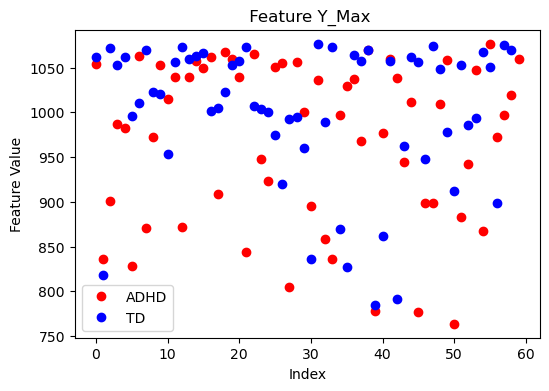

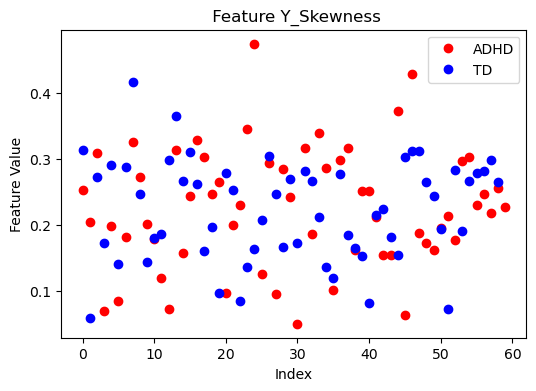

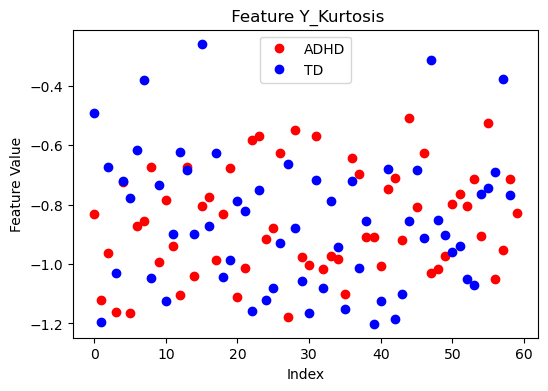

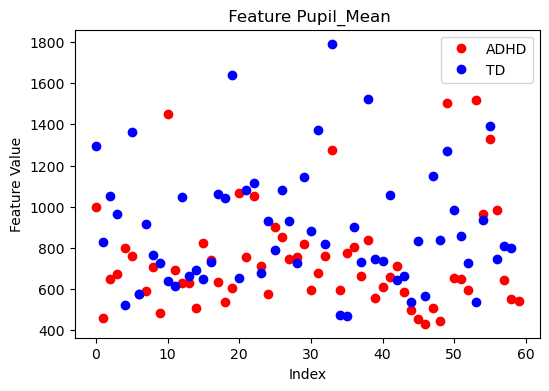

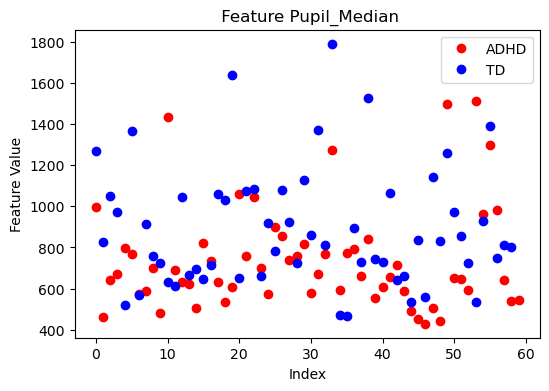

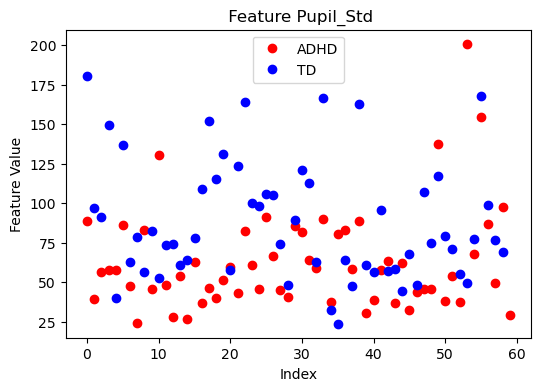

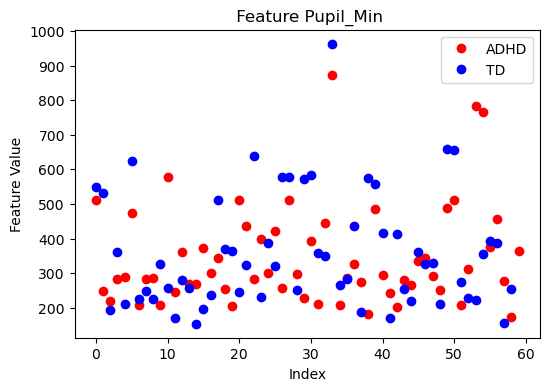

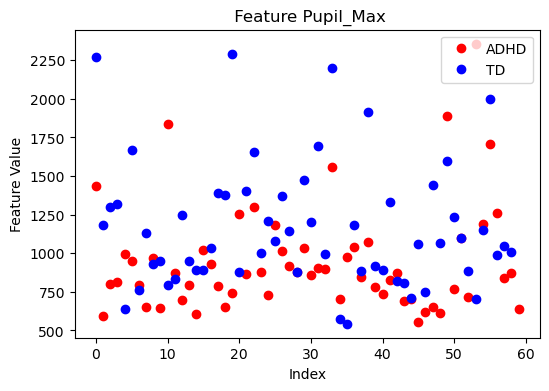

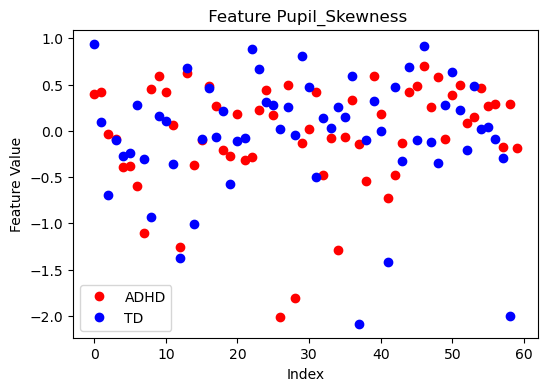

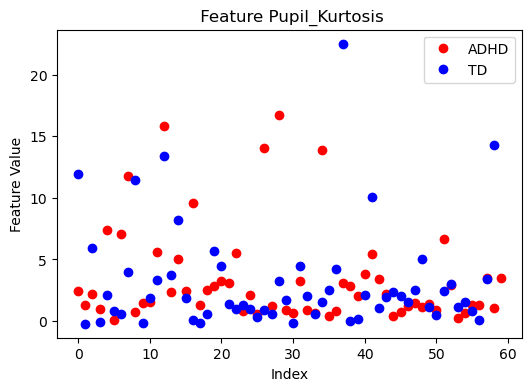

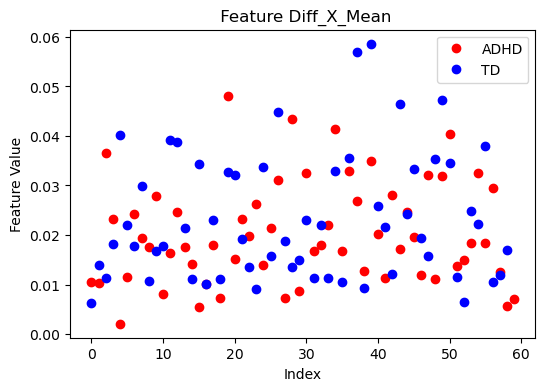

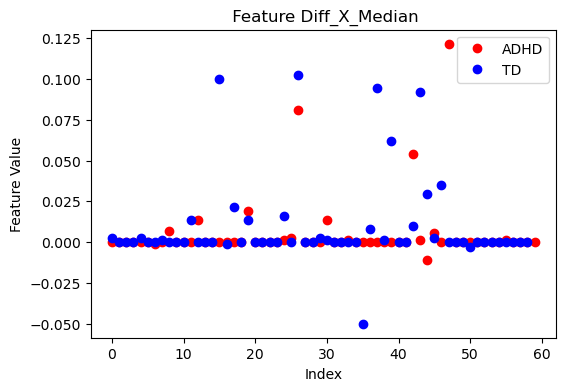

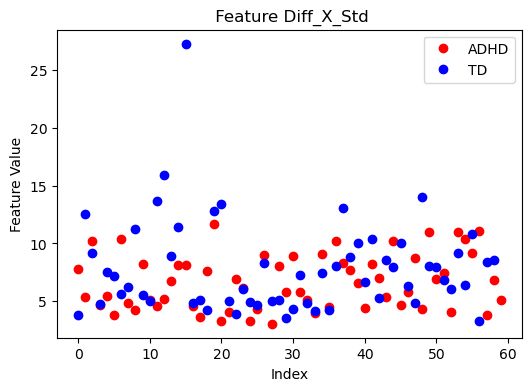

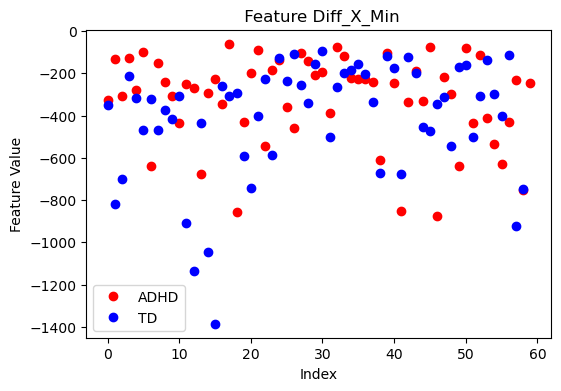

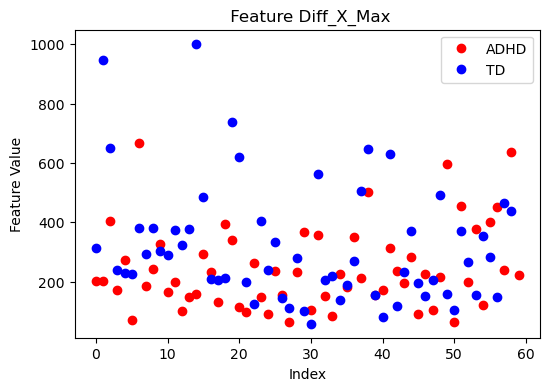

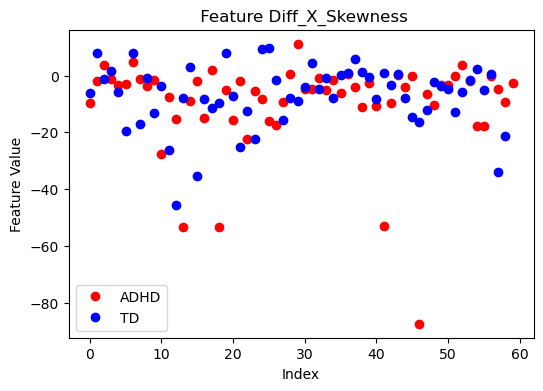

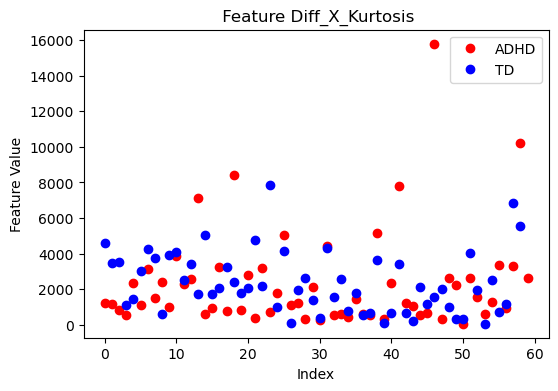

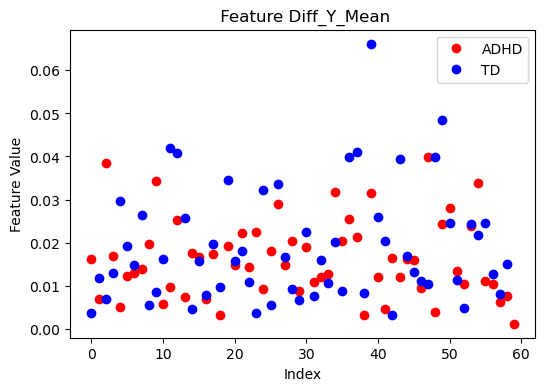

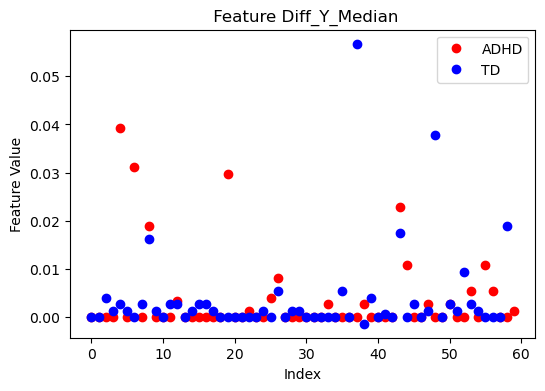

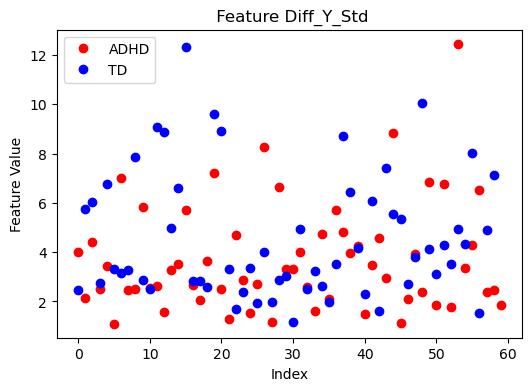

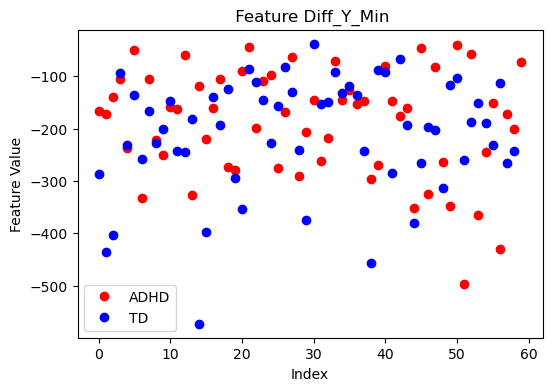

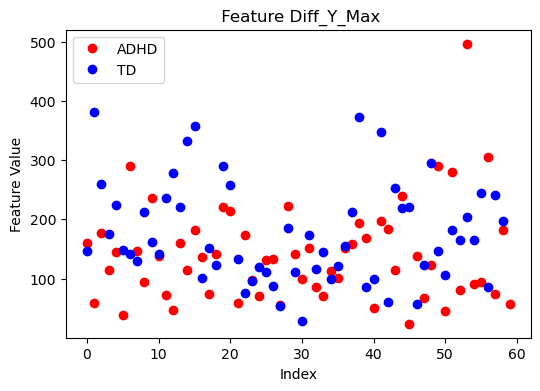

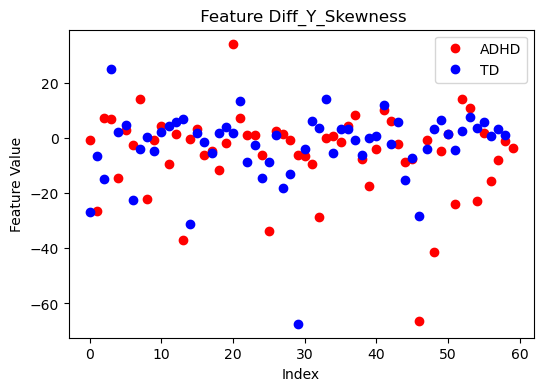

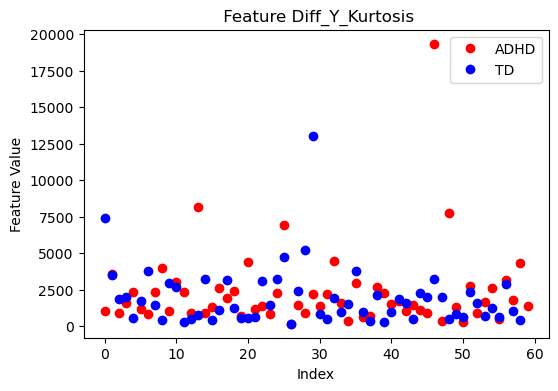

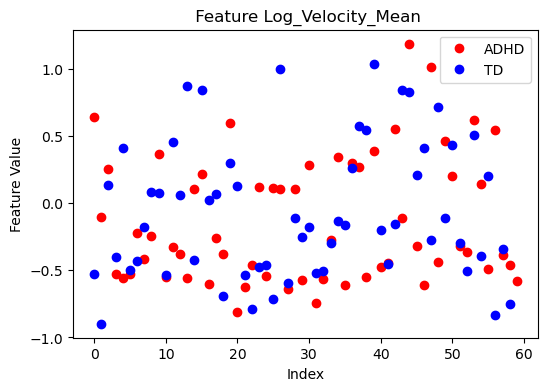

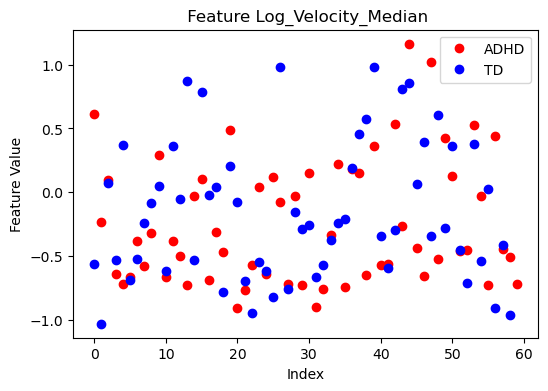

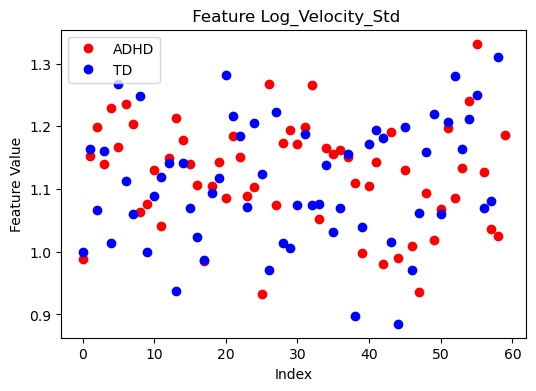

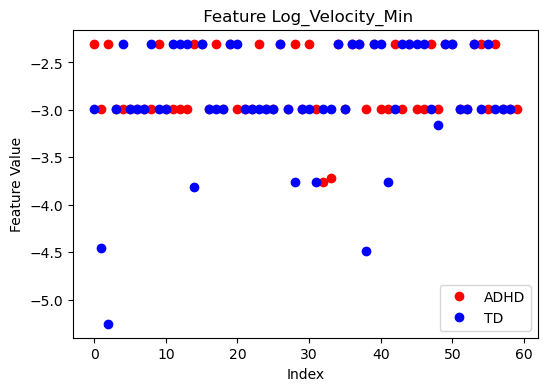

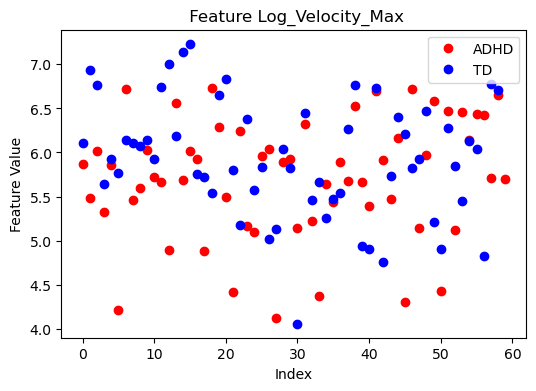

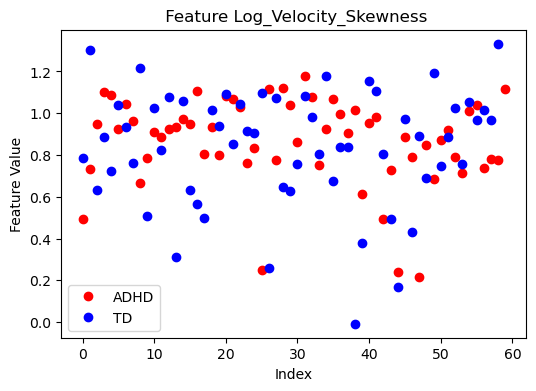

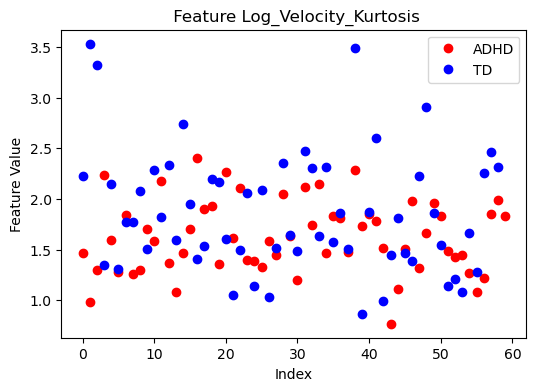

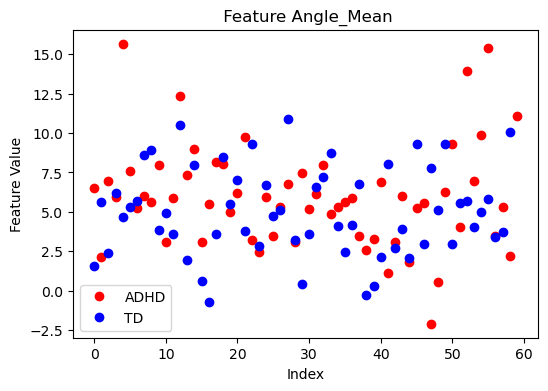

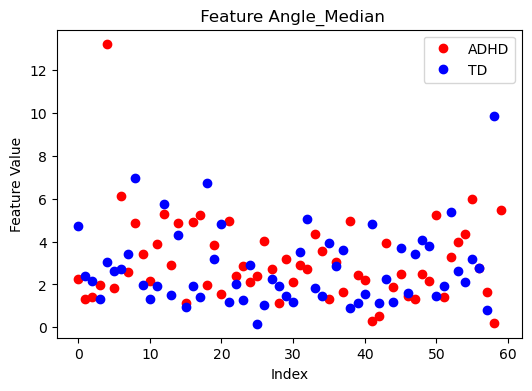

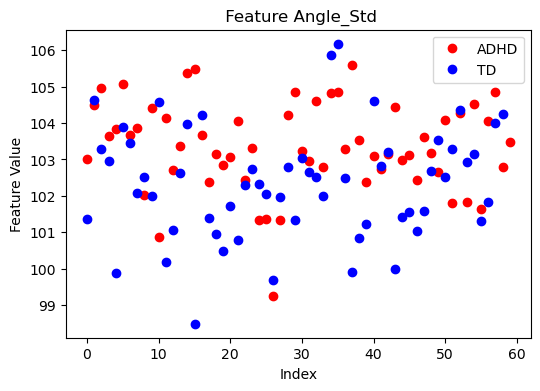

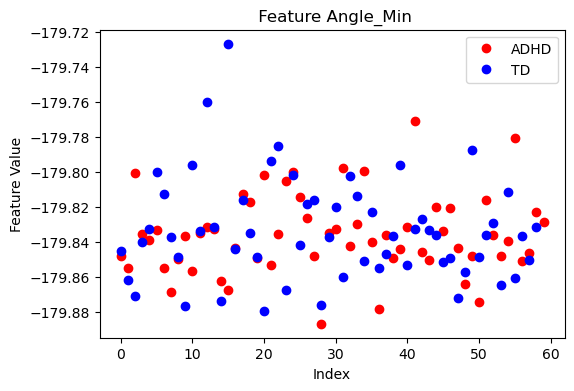

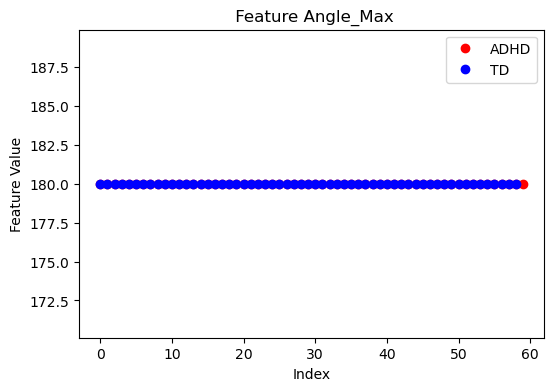

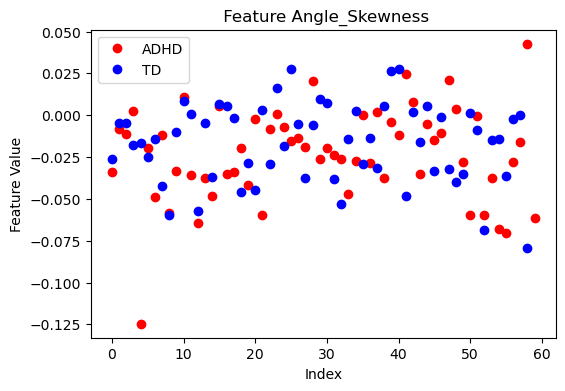

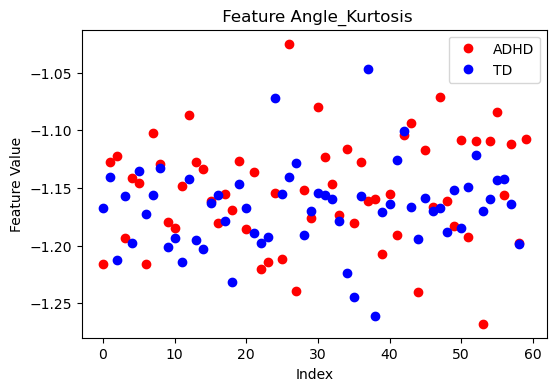

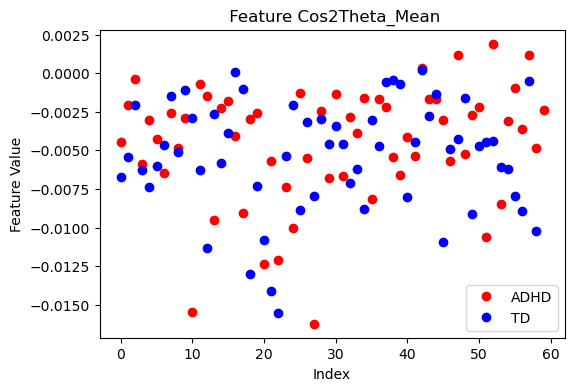

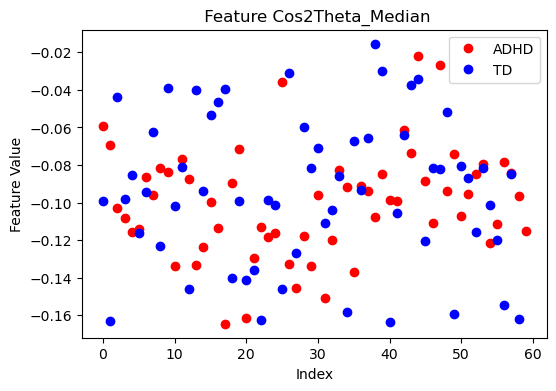

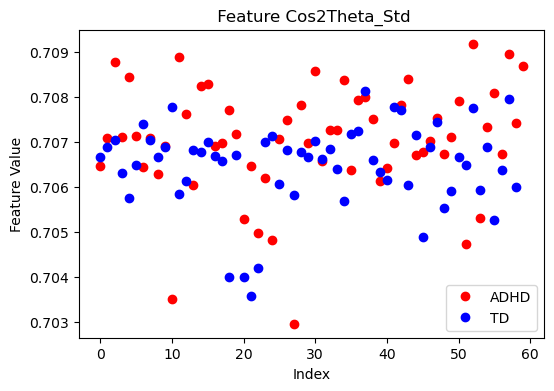

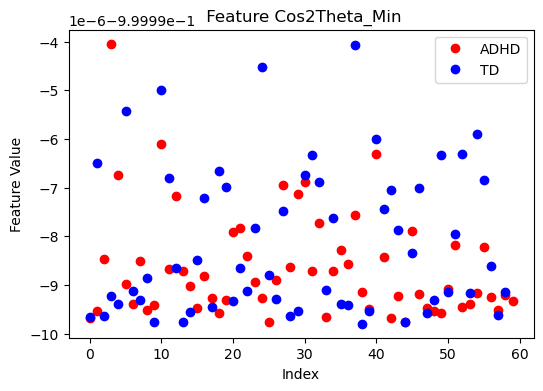

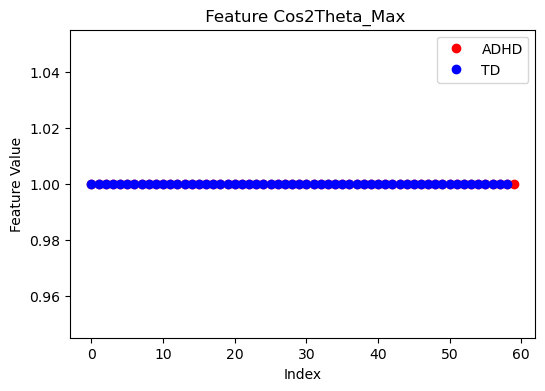

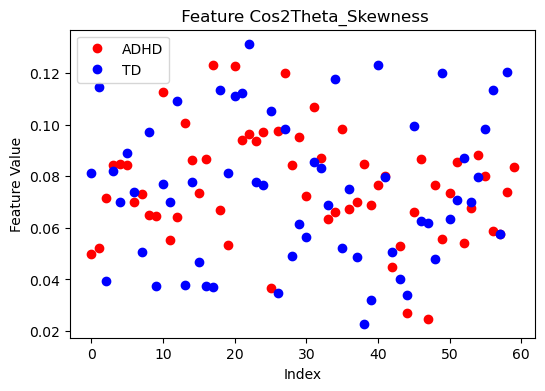

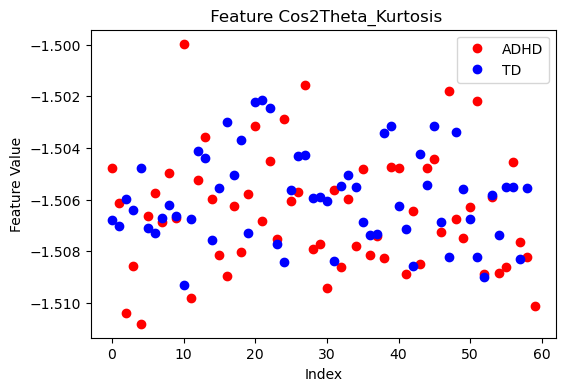

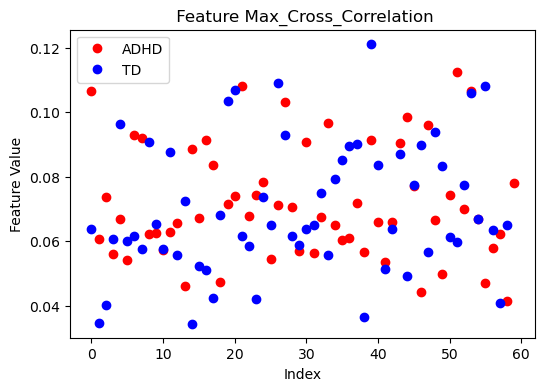

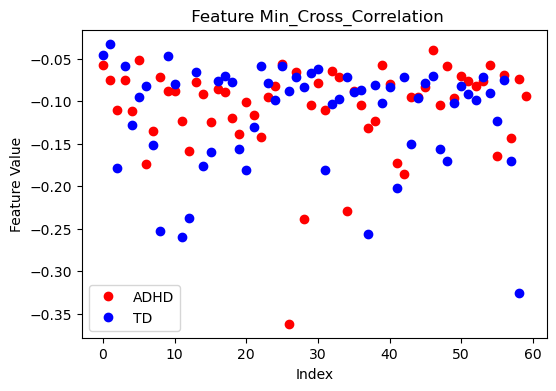

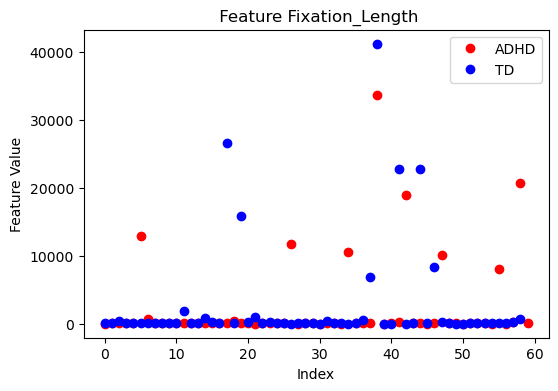

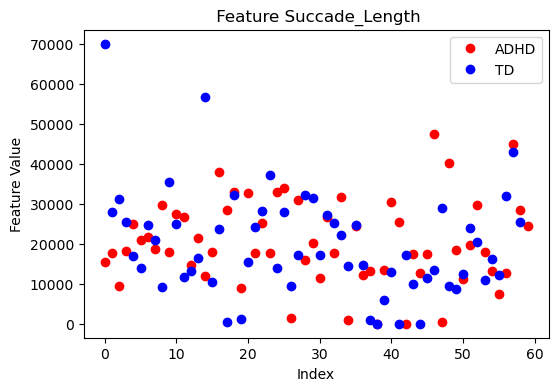

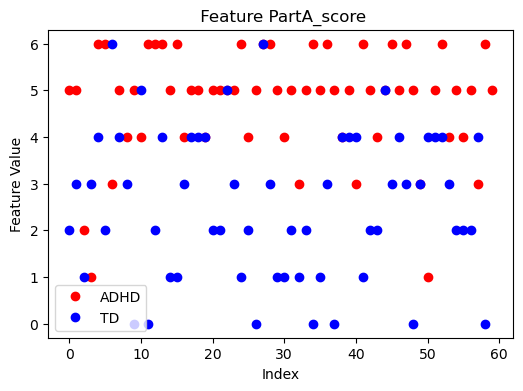

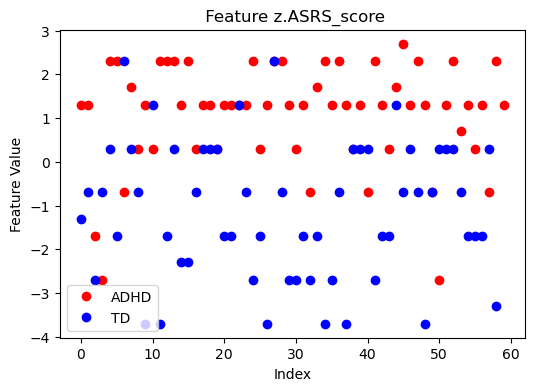

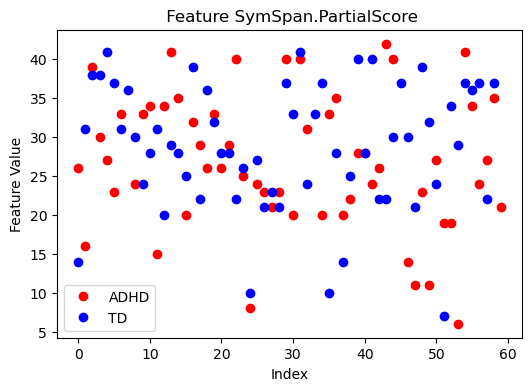

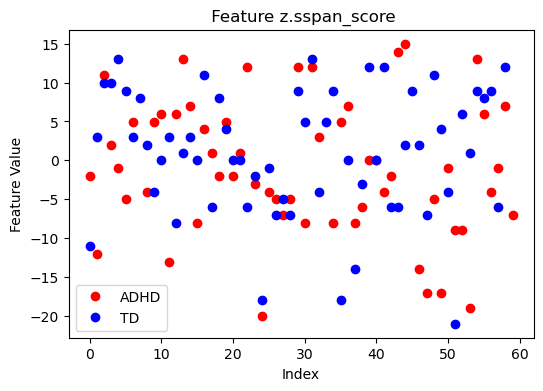

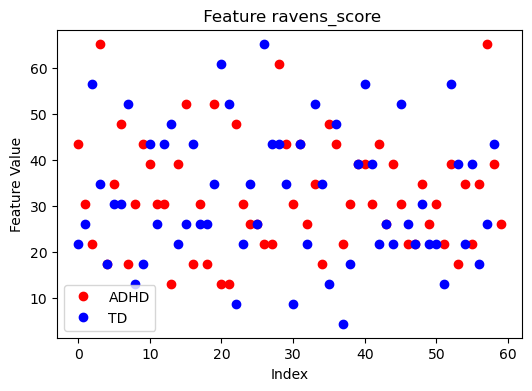

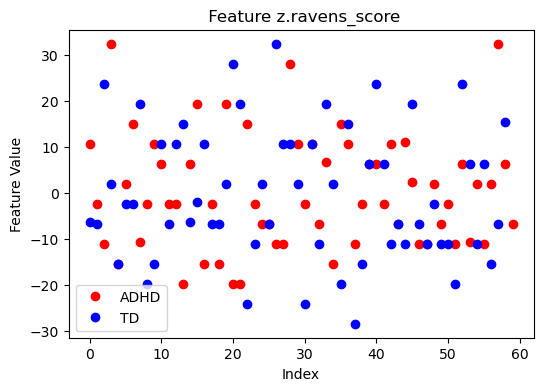

In [76]:
import matplotlib.pyplot as plt

# Plot all features one by one
for i in range(66):
    plt.figure(figsize=(6, 4))
    
    plt.plot(adhd_features[:, i], 'ro', label="ADHD")  # Red for ADHD
    plt.plot(td_features[:, i], 'bo', label="TD")  # Blue for TD    
    plt.title(f" Feature {Feature_names[i]}")
    plt.xlabel("Index") #position of the participants
    plt.ylabel("Feature Value") #the value of the feature
    plt.legend()
    plt.show()

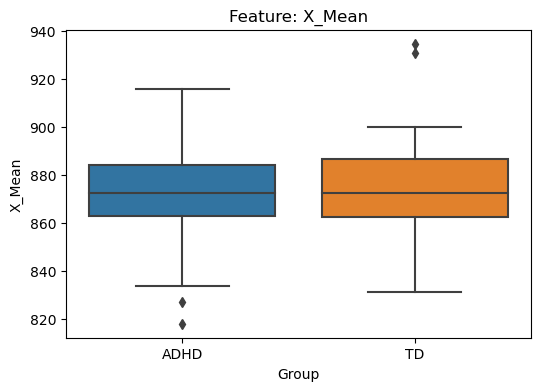

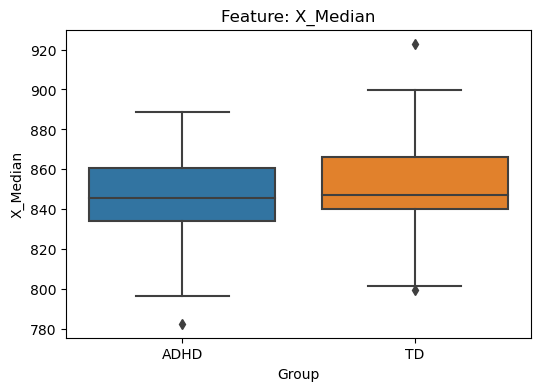

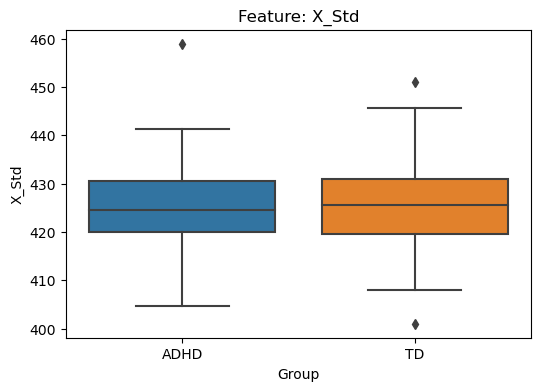

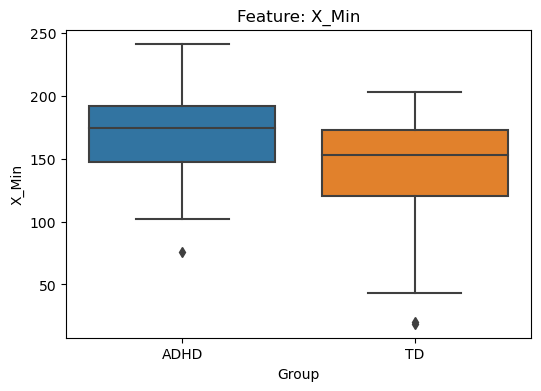

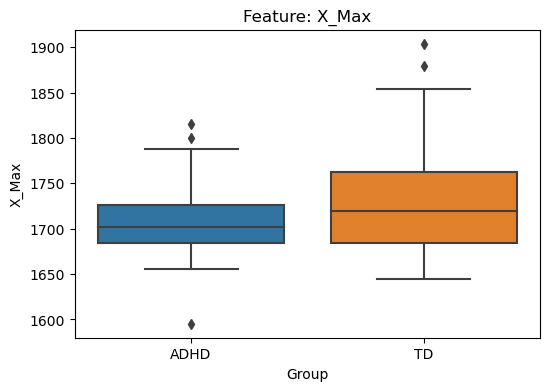

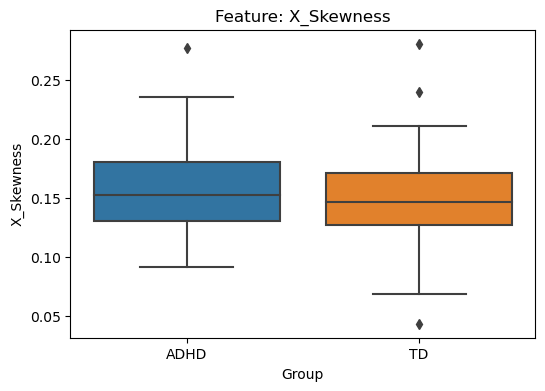

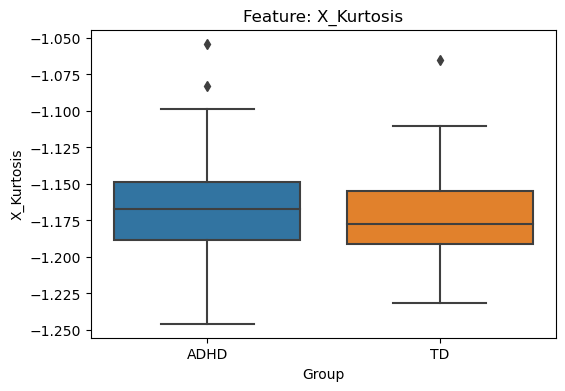

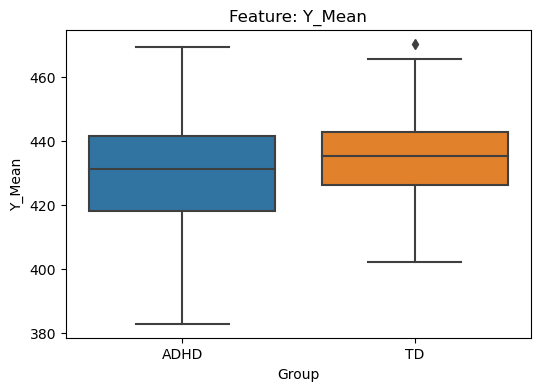

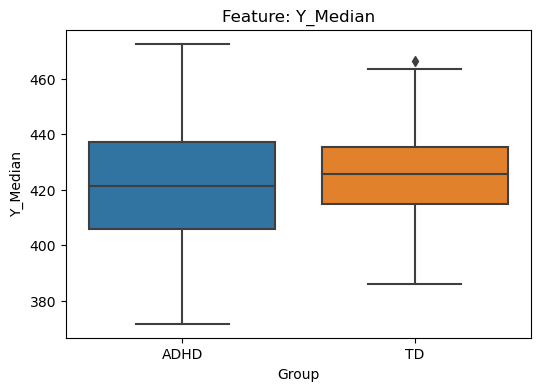

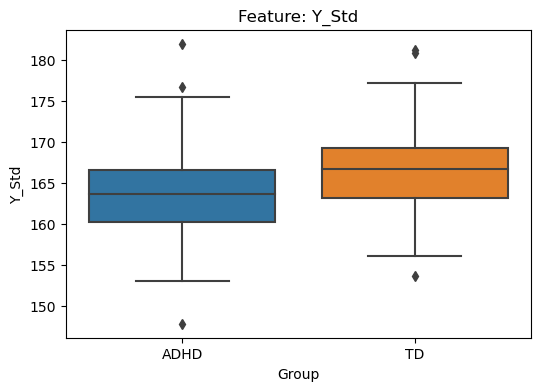

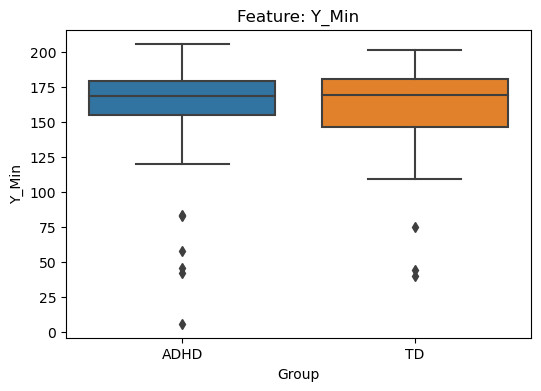

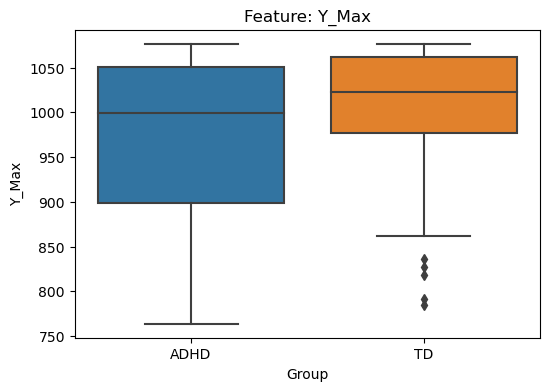

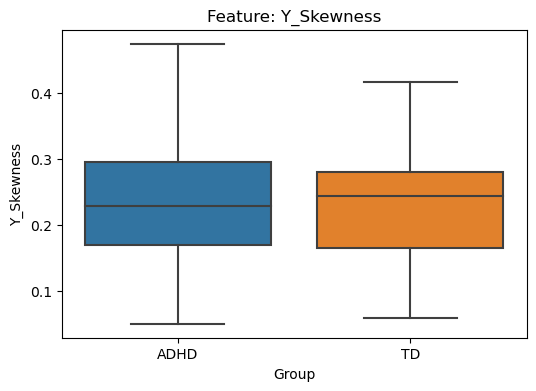

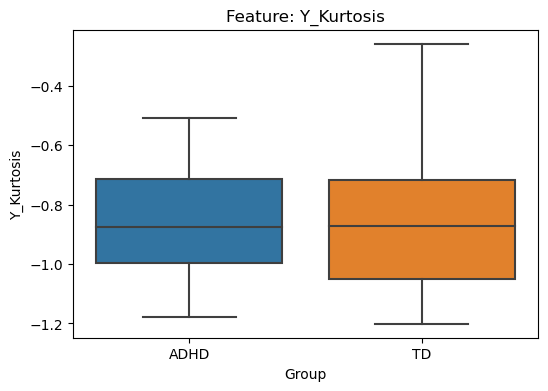

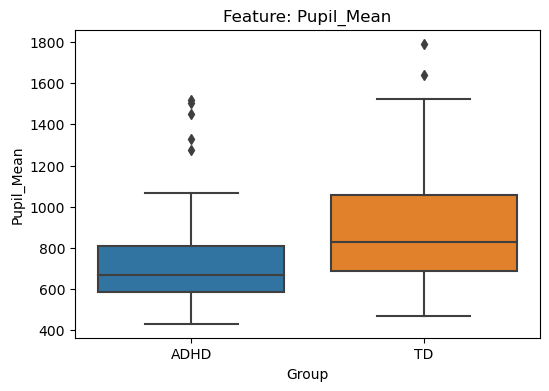

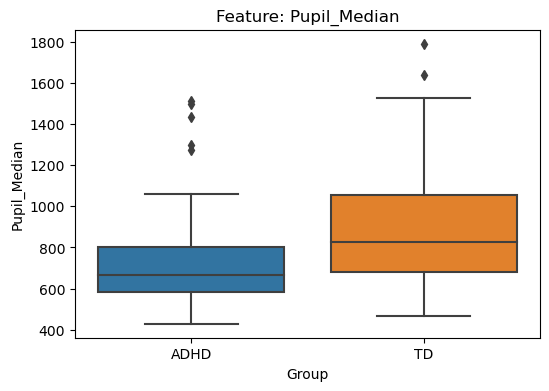

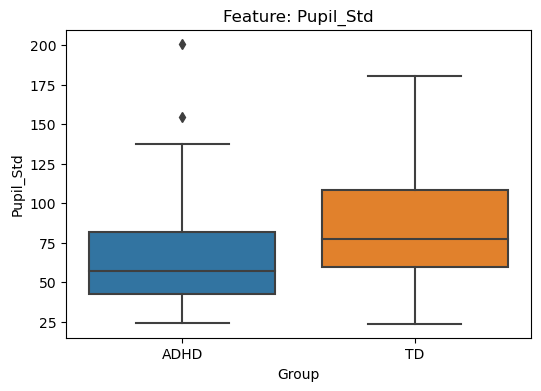

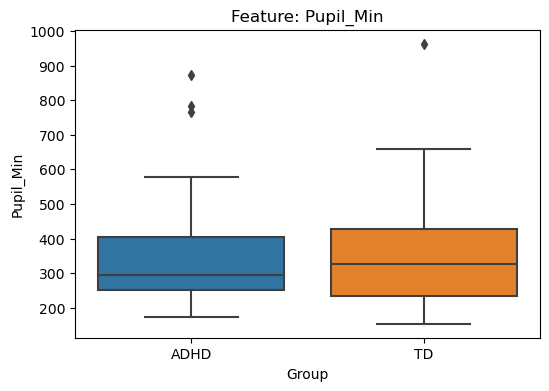

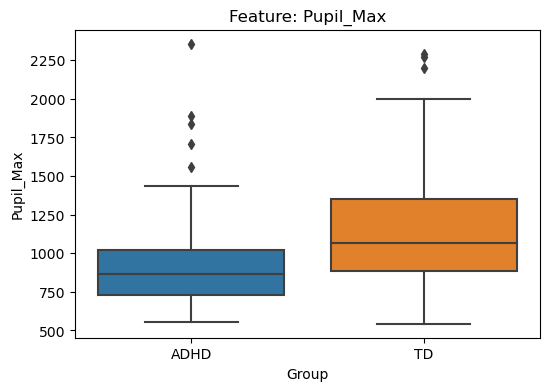

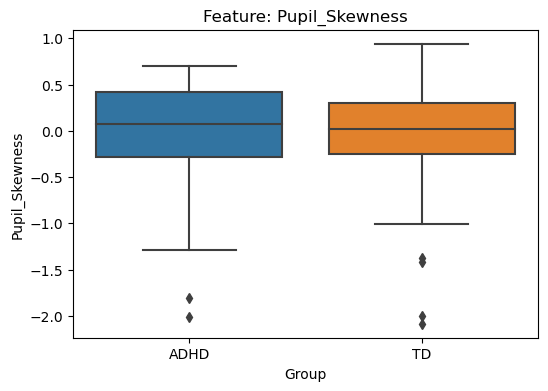

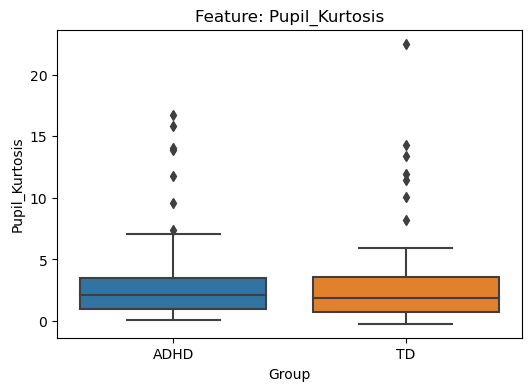

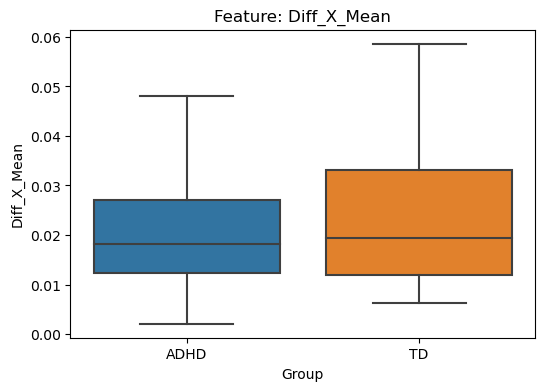

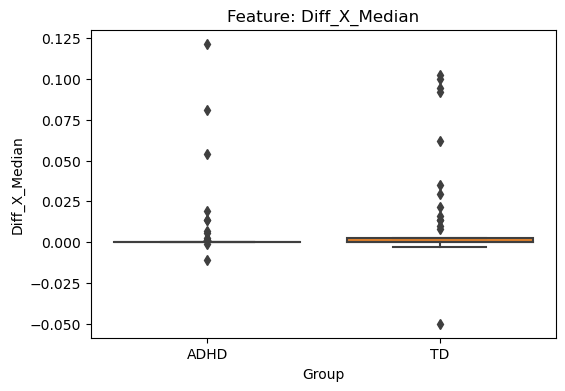

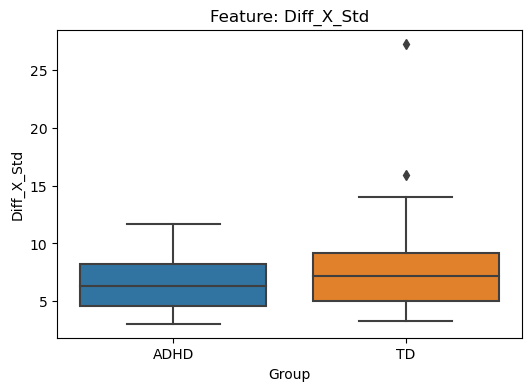

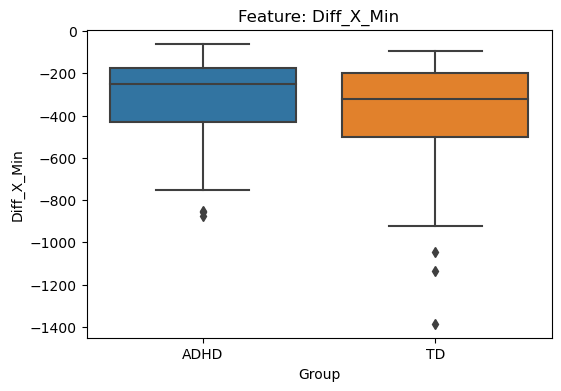

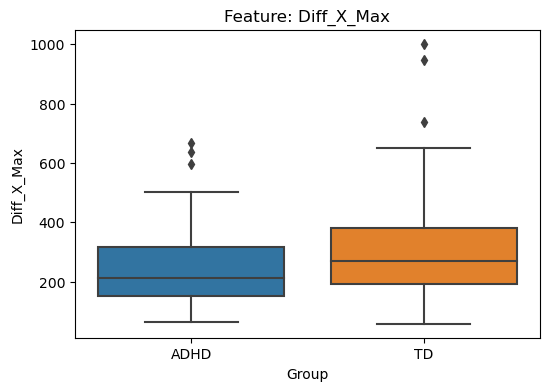

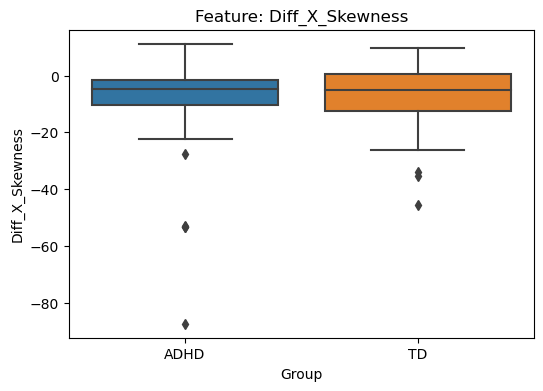

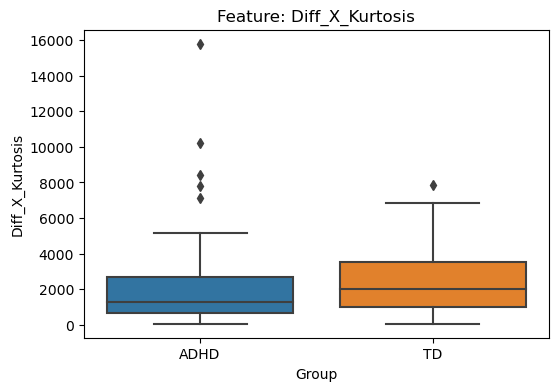

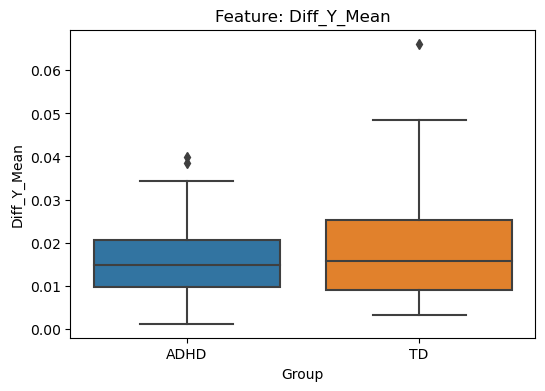

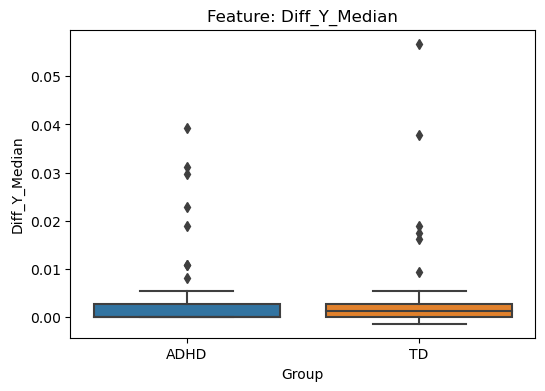

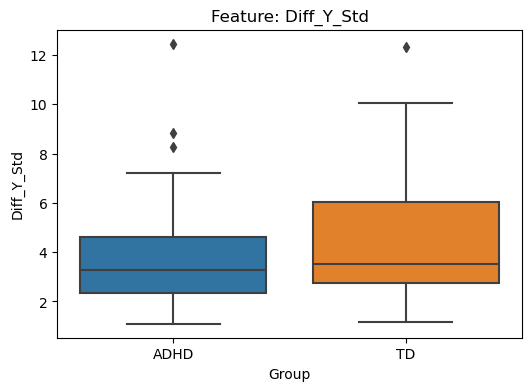

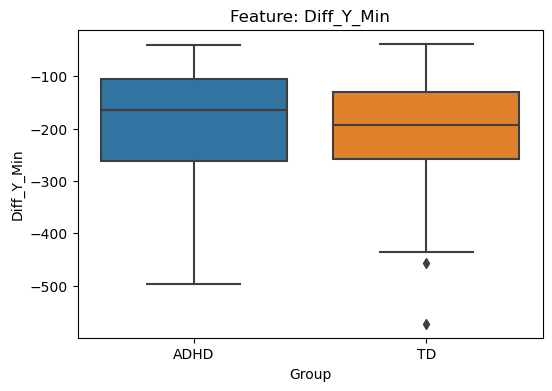

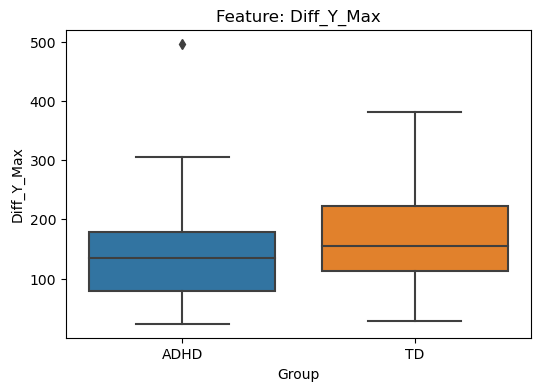

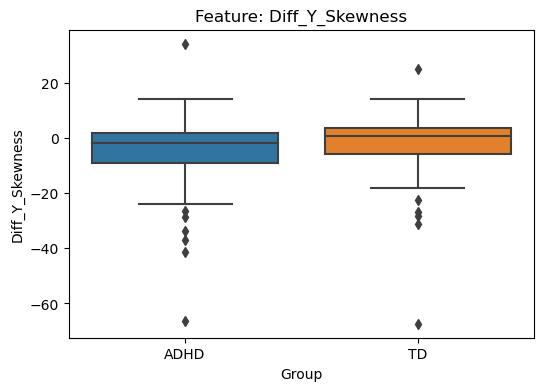

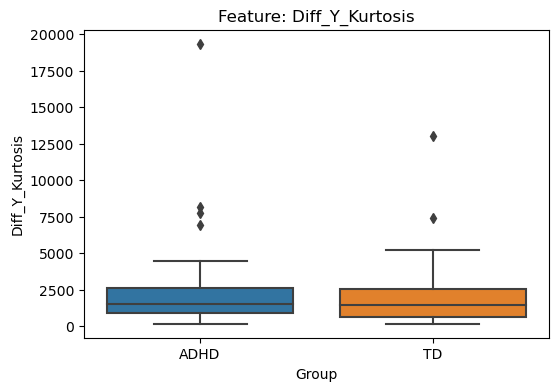

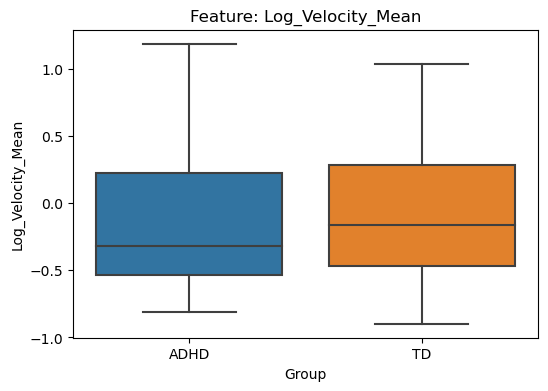

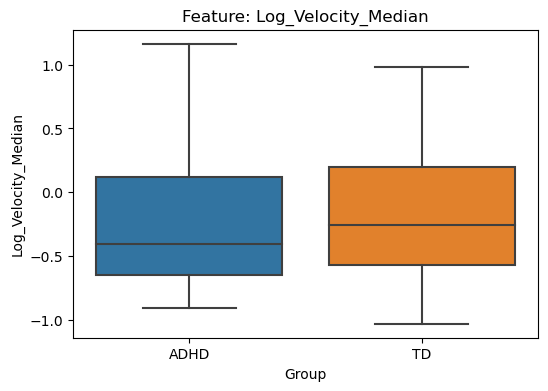

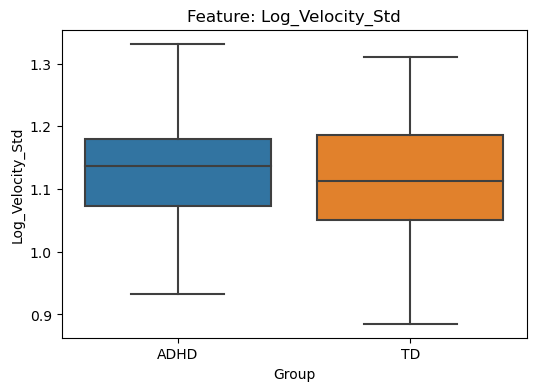

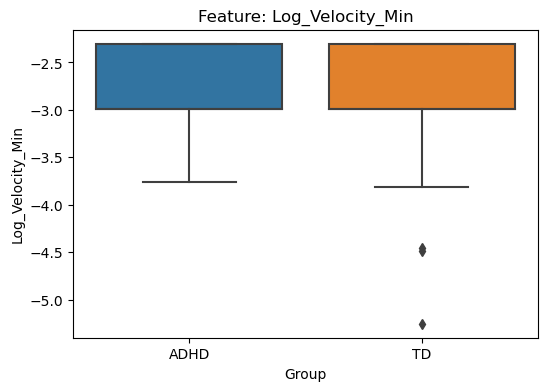

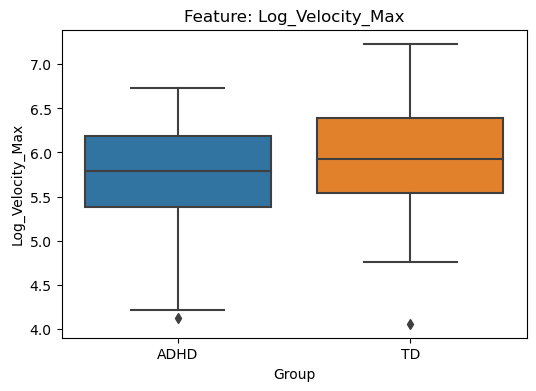

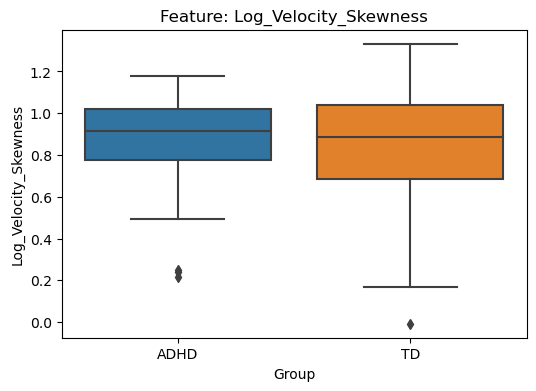

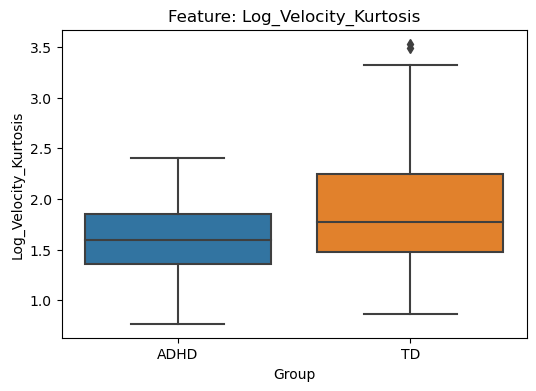

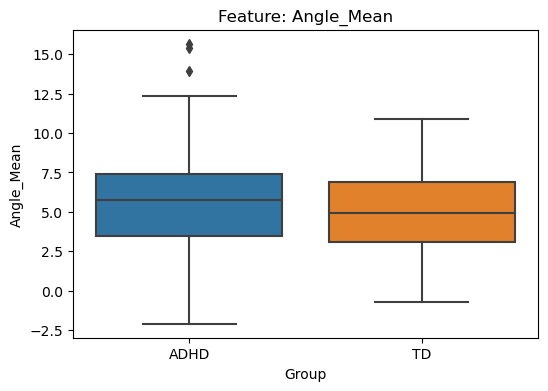

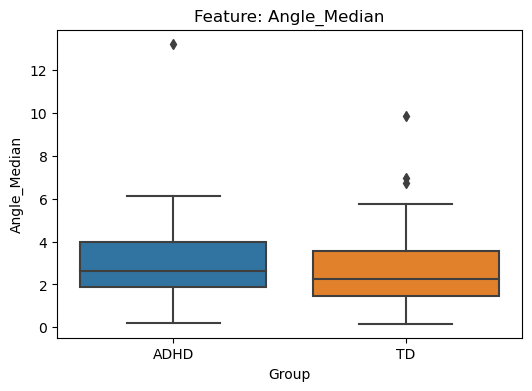

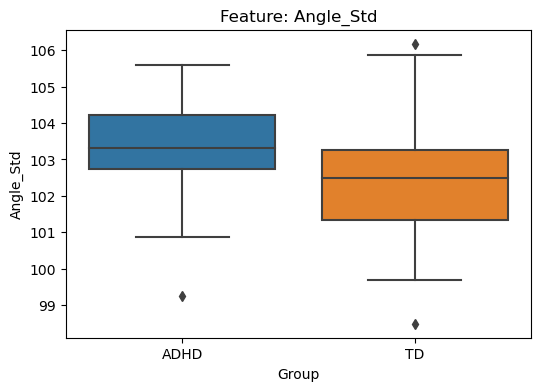

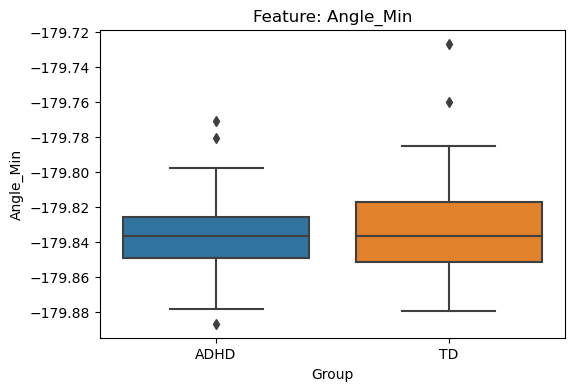

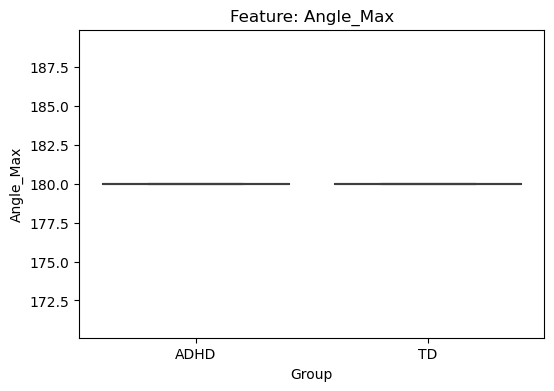

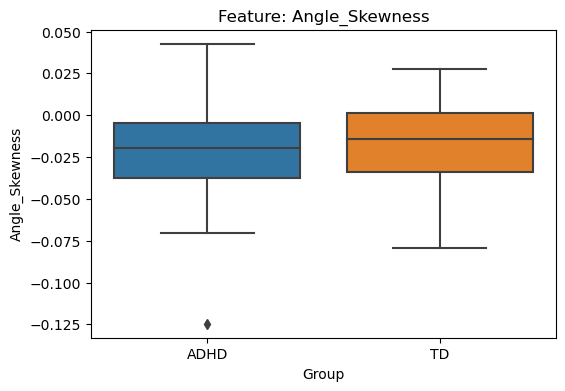

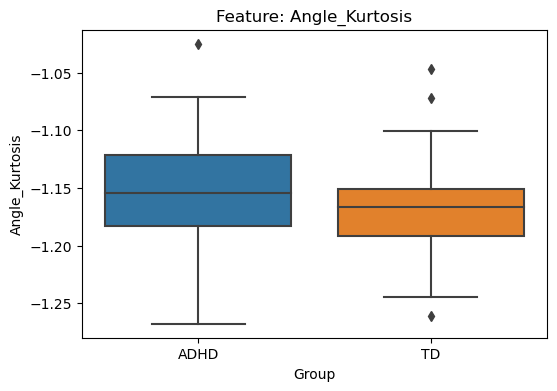

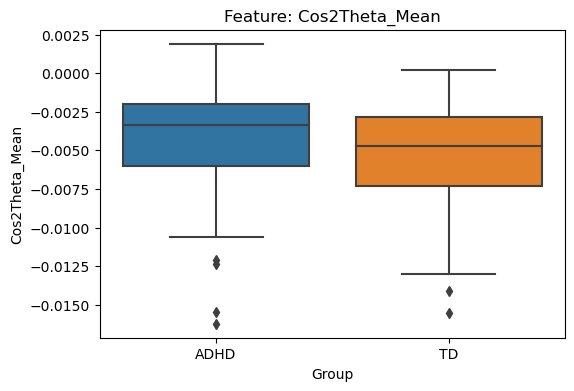

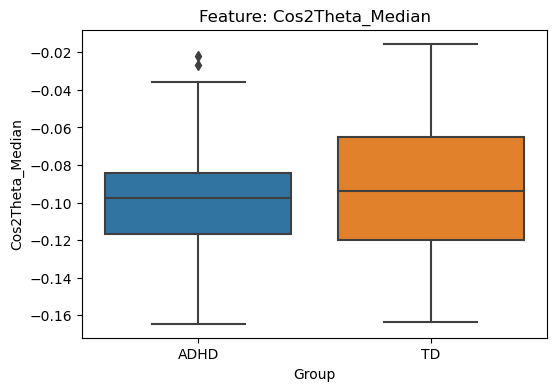

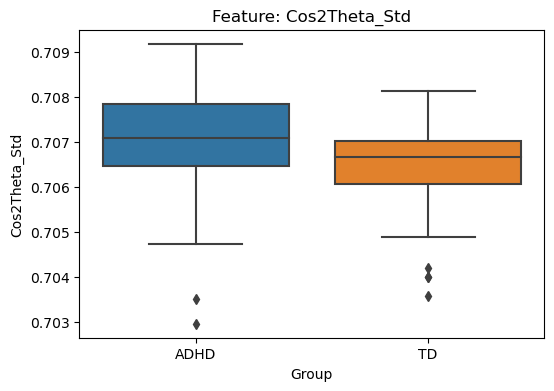

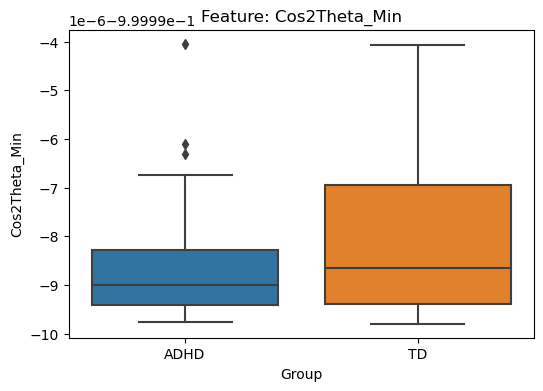

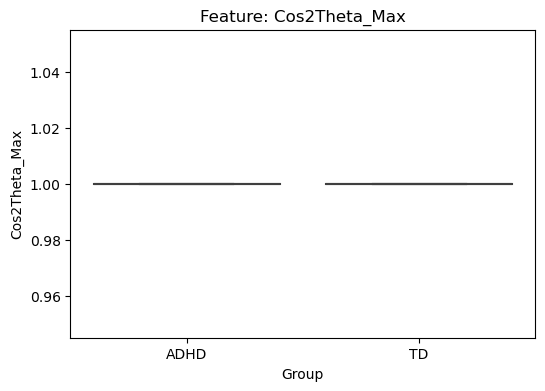

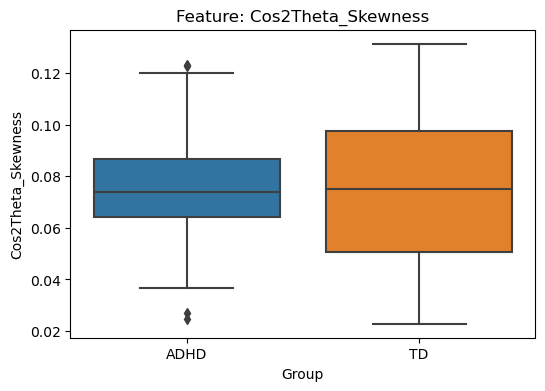

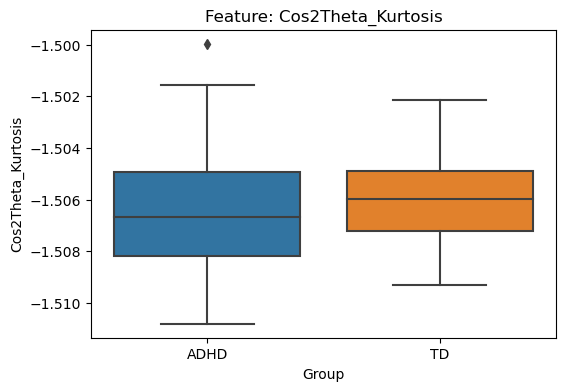

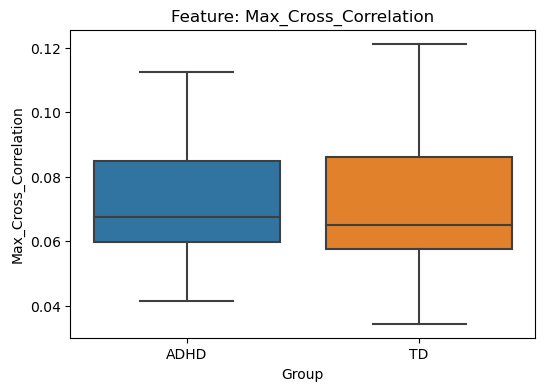

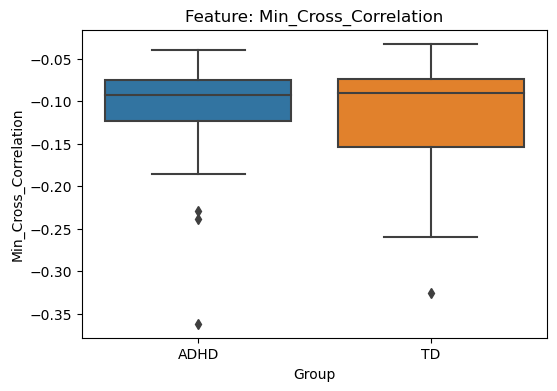

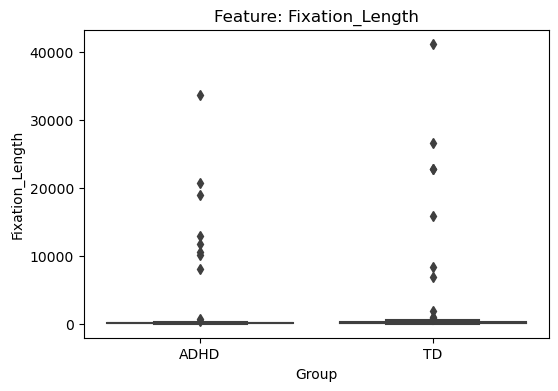

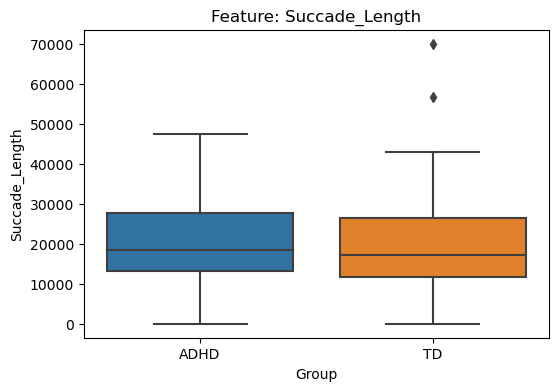

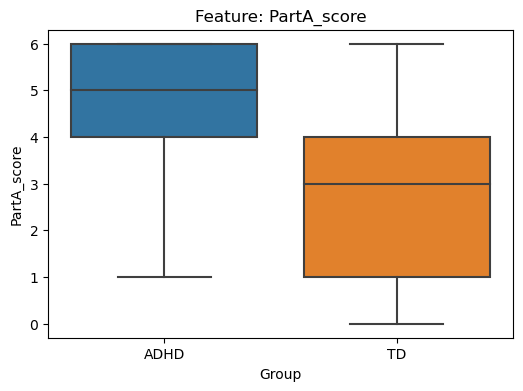

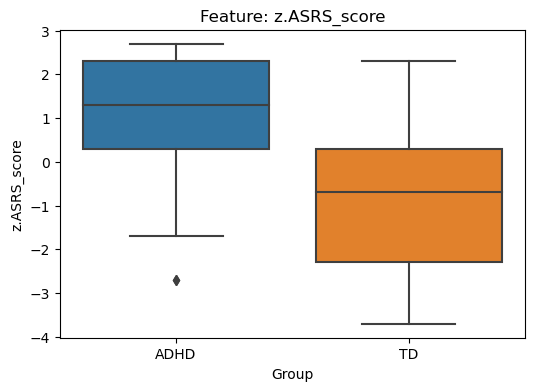

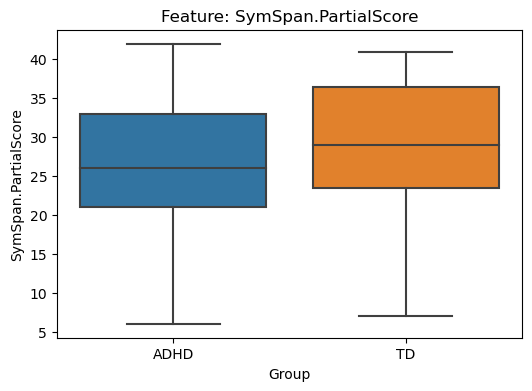

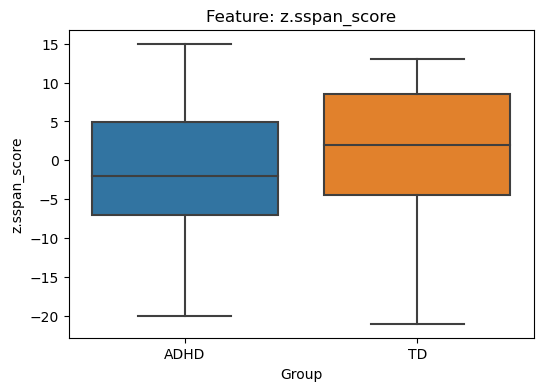

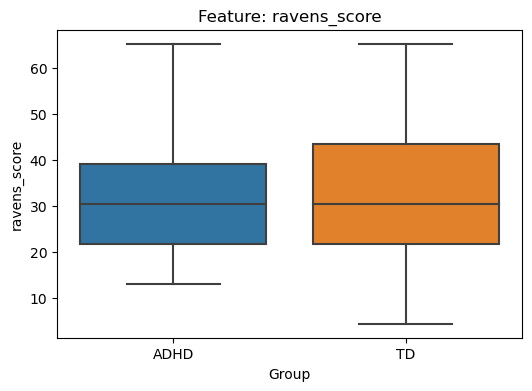

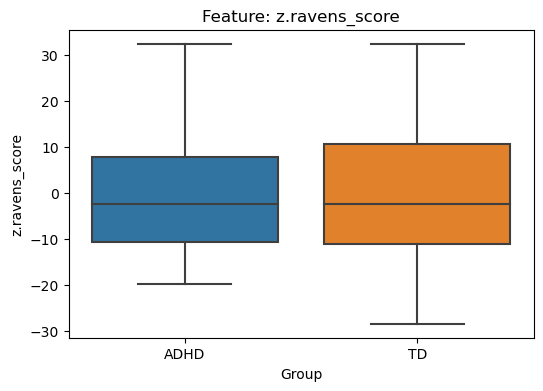

In [77]:
import seaborn as sns
import pandas as pd

# Convert to DataFrame for easier plotting
adhd_df = pd.DataFrame(adhd_features, columns=Feature_names)
td_df = pd.DataFrame(td_features, columns=Feature_names)

# Add a group column
adhd_df["Group"] = "ADHD"
td_df["Group"] = "TD"

# Combine both datasets
df = pd.concat([adhd_df, td_df])

# Plot boxplots for each feature
for feature in Feature_names:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Group", y=feature, data=df)    
    plt.title(f"Feature: {feature}")
    plt.show()


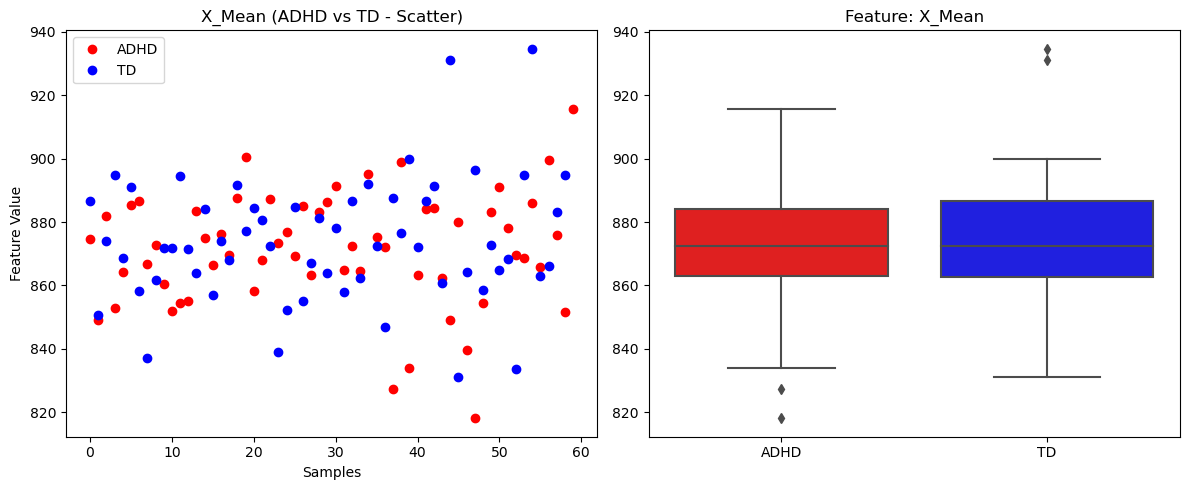

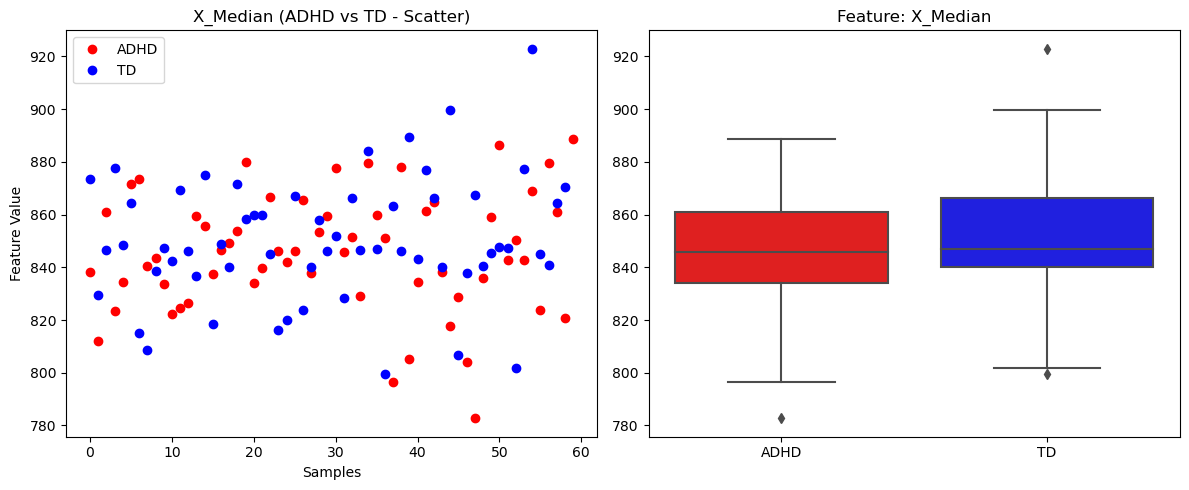

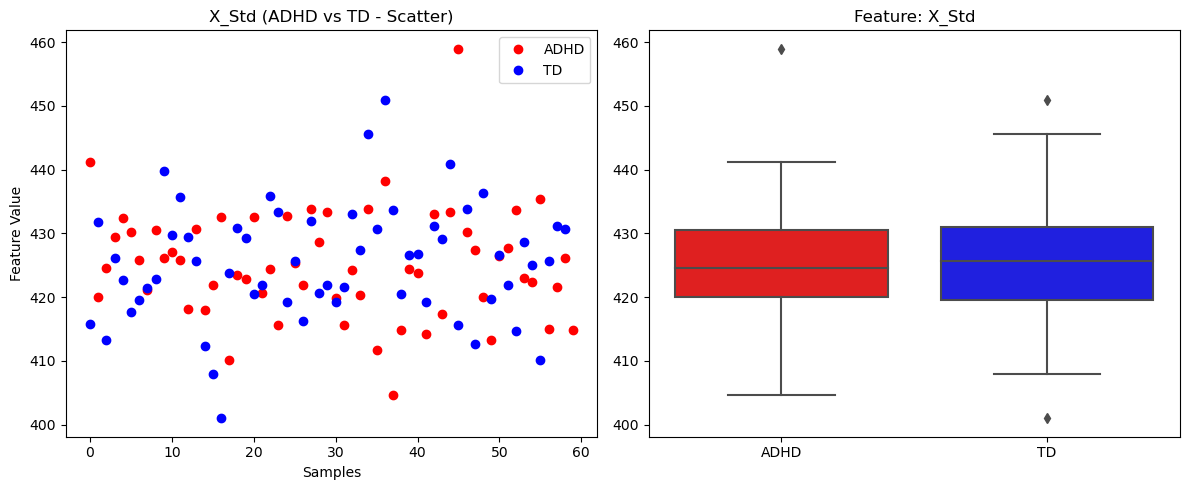

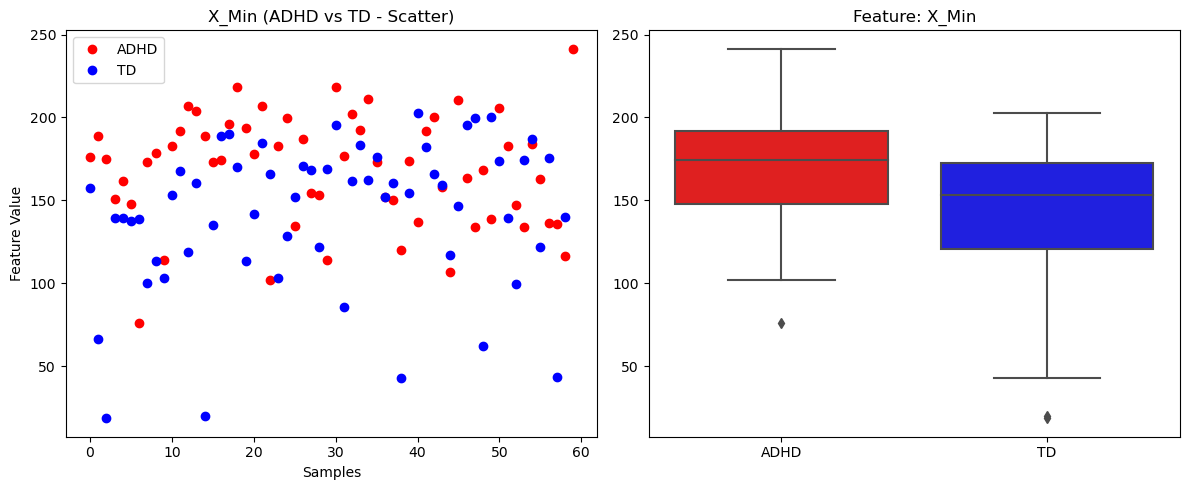

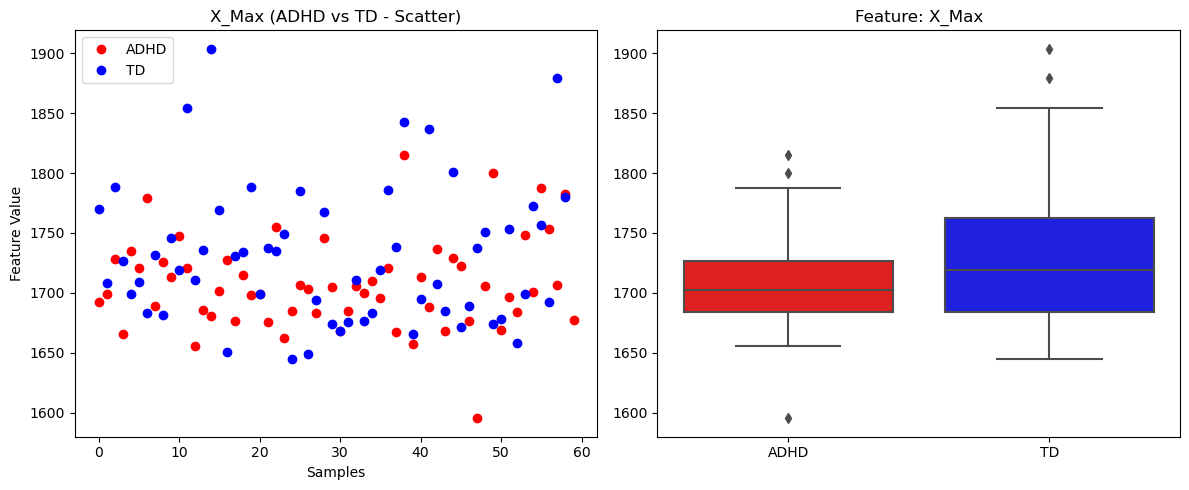

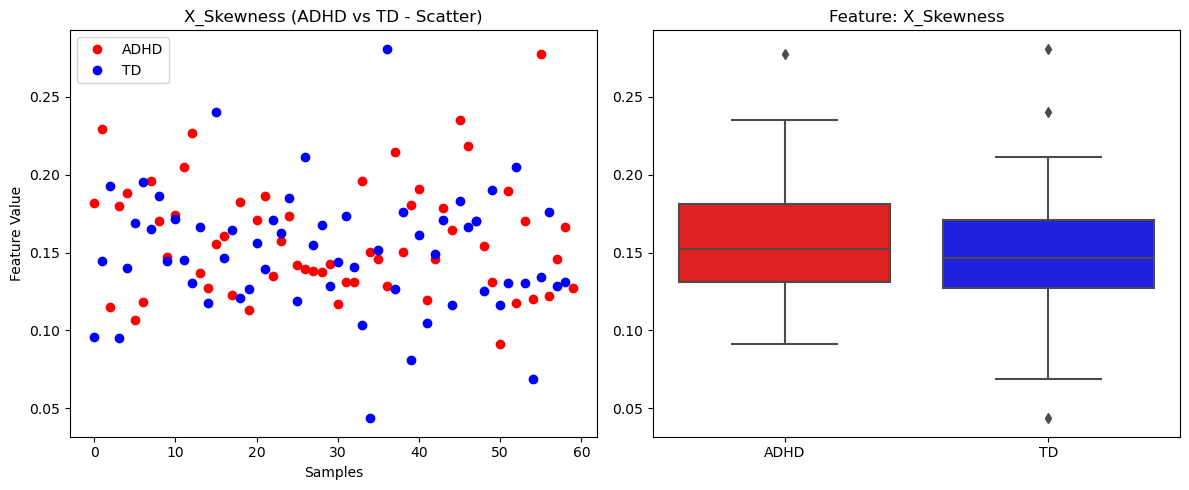

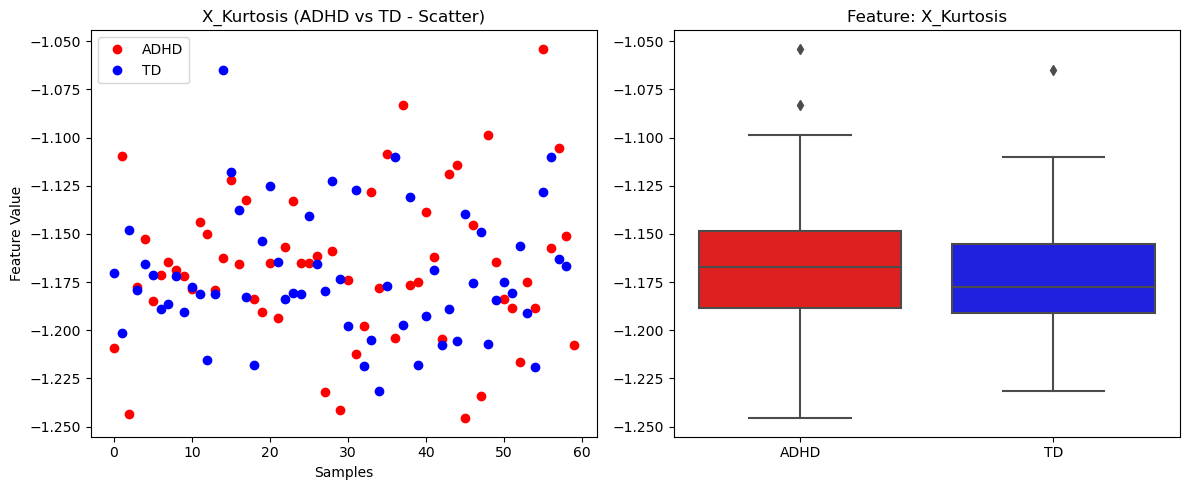

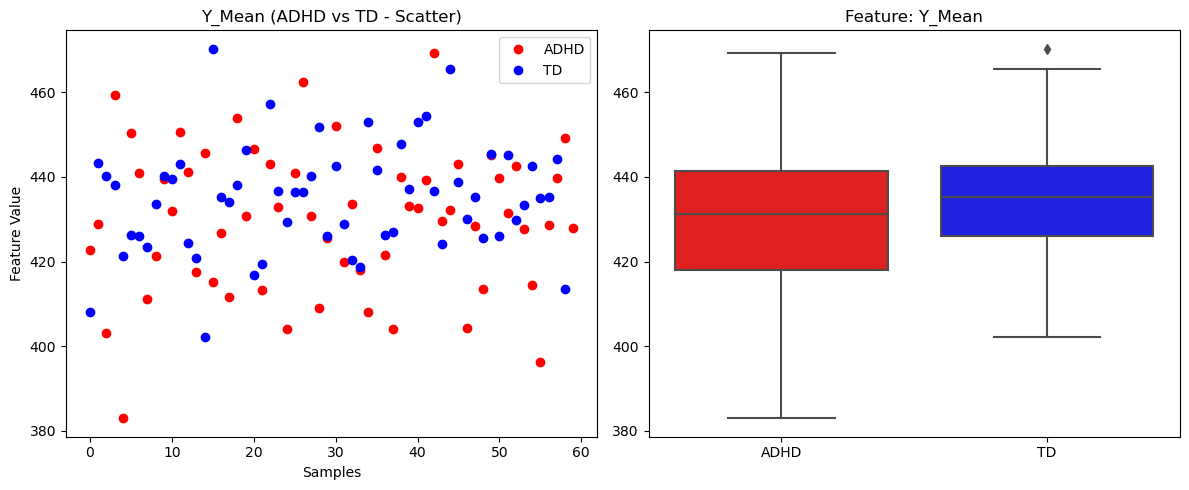

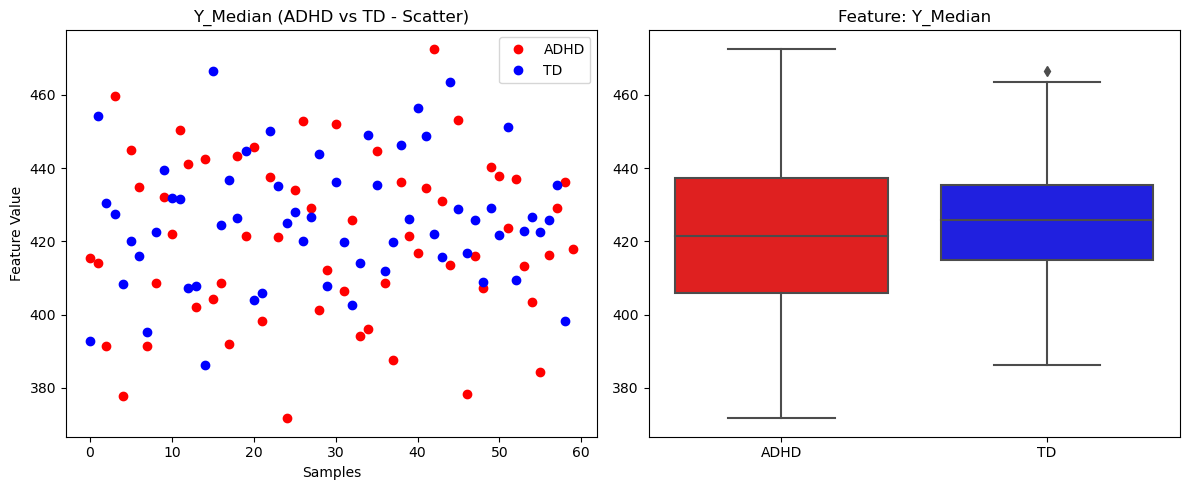

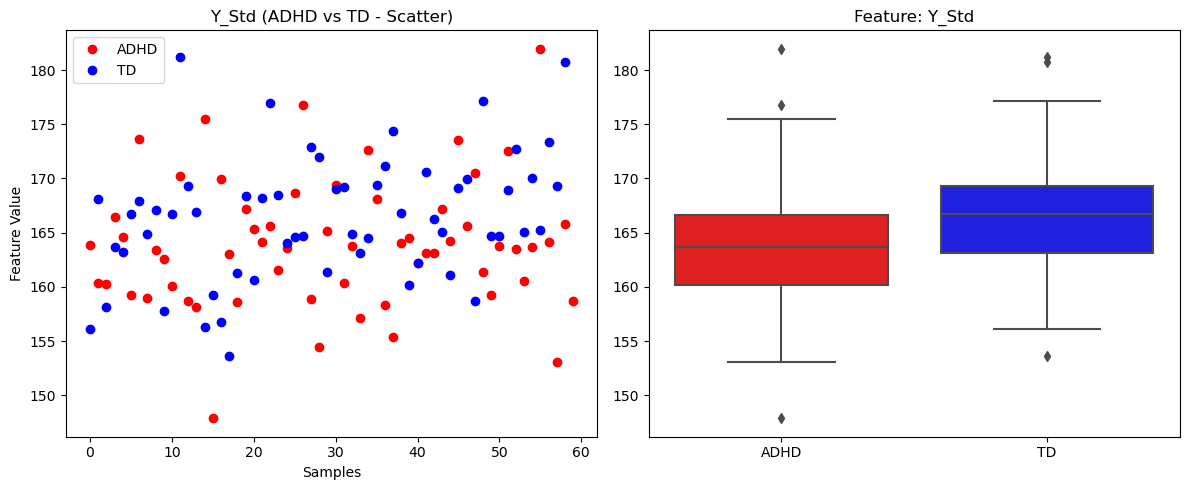

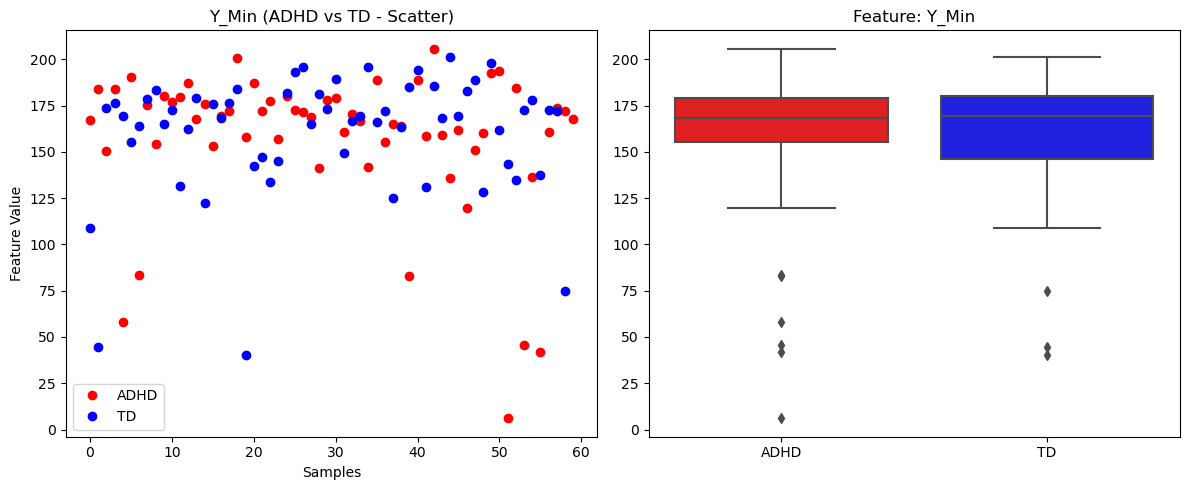

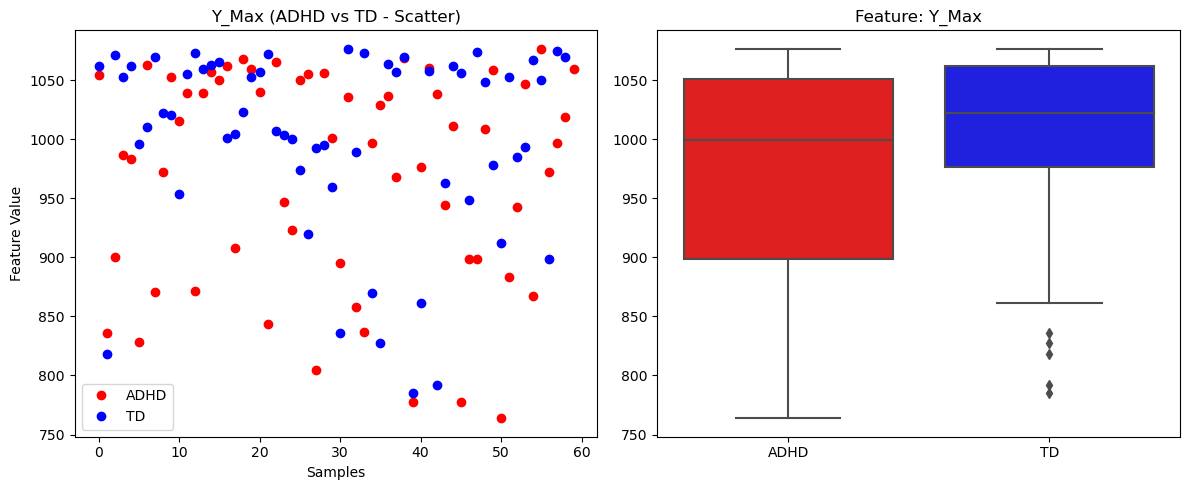

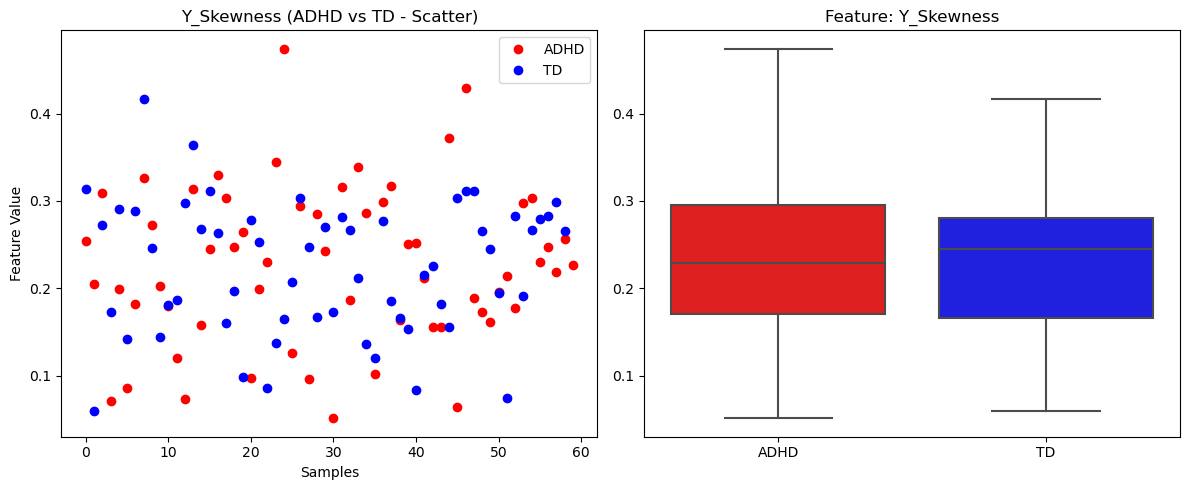

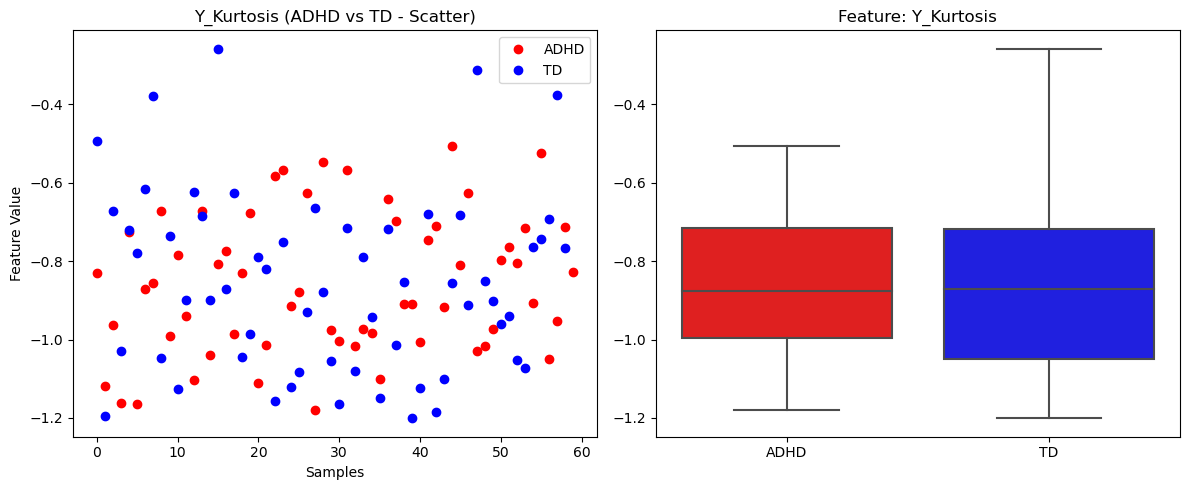

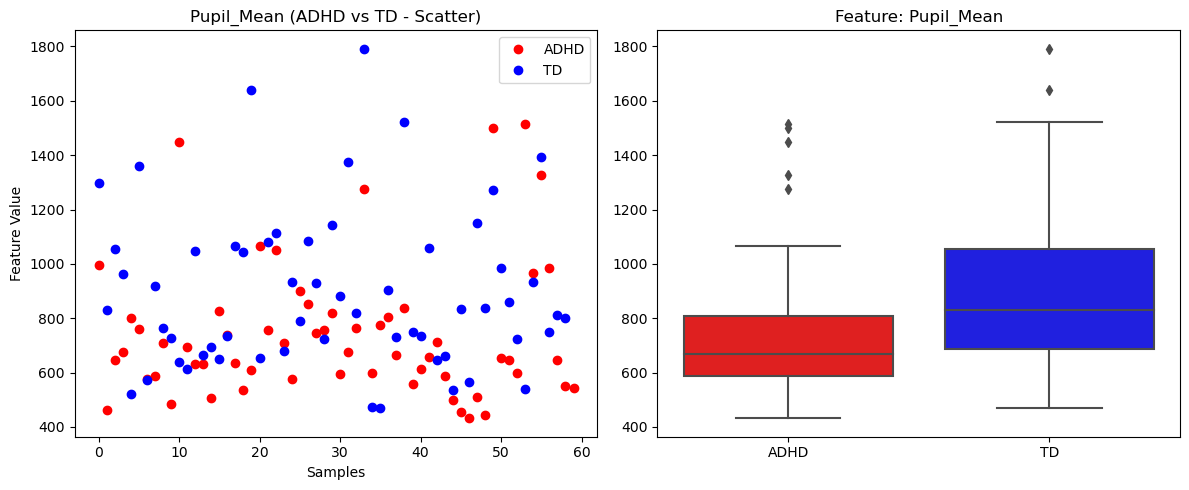

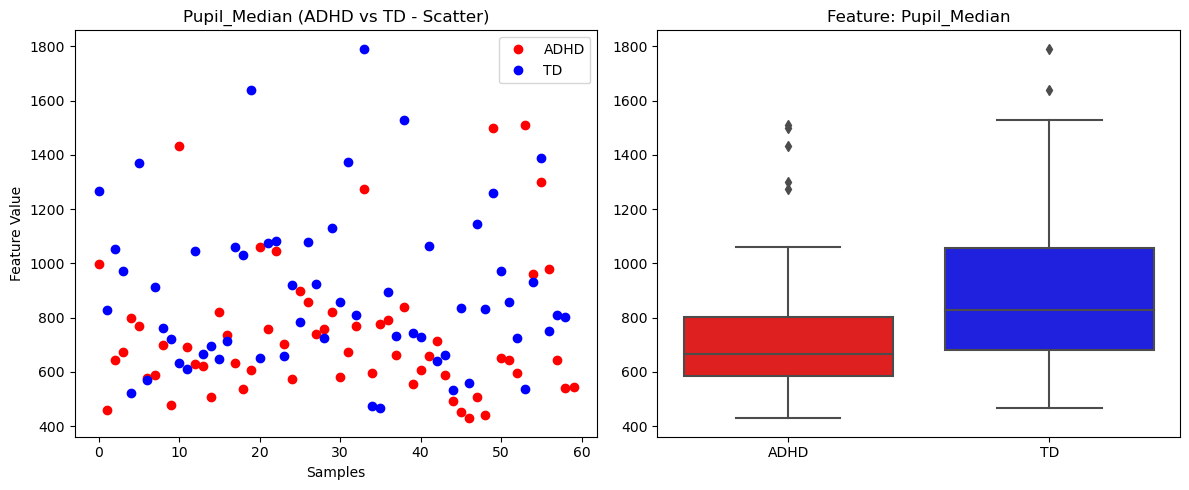

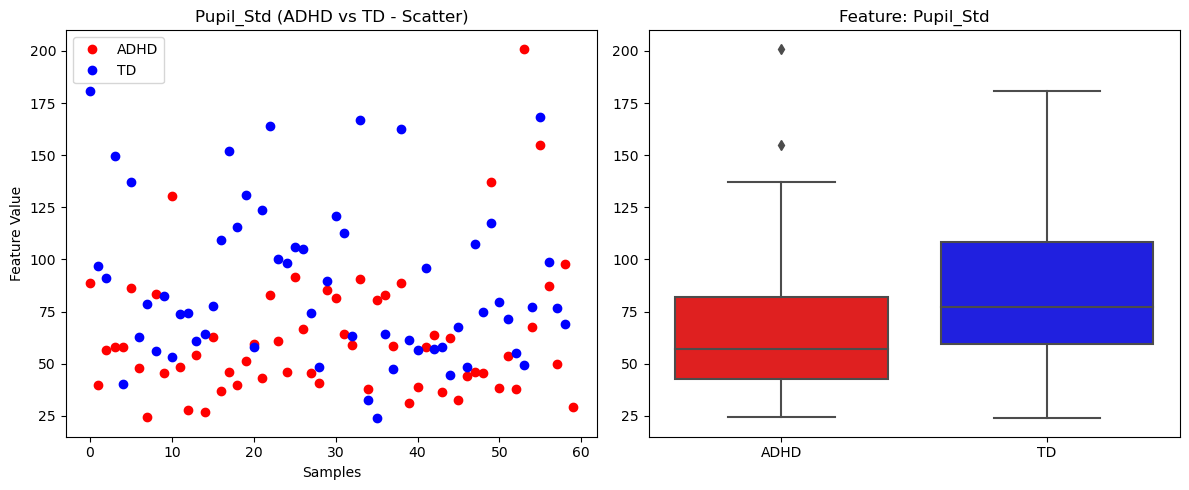

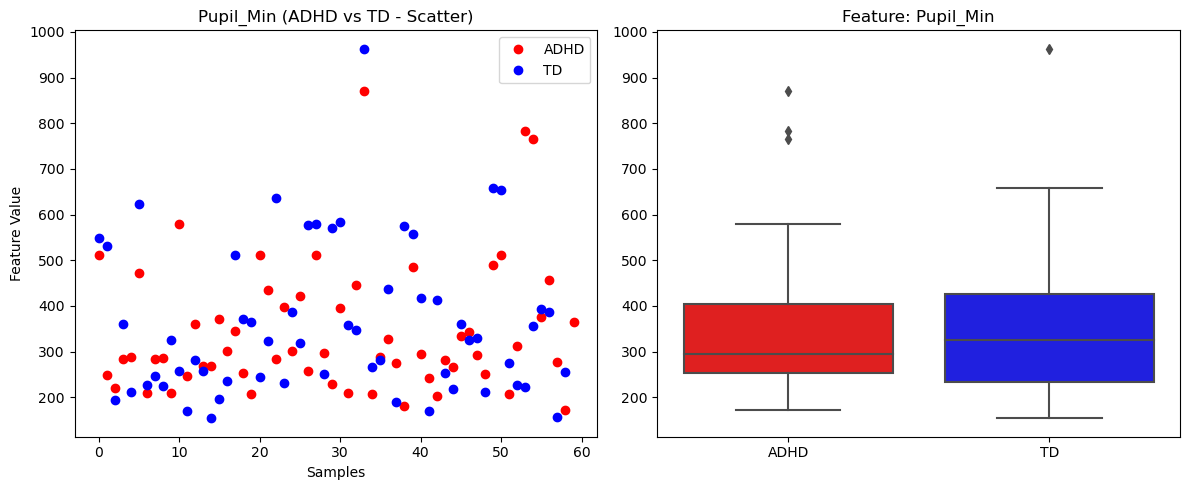

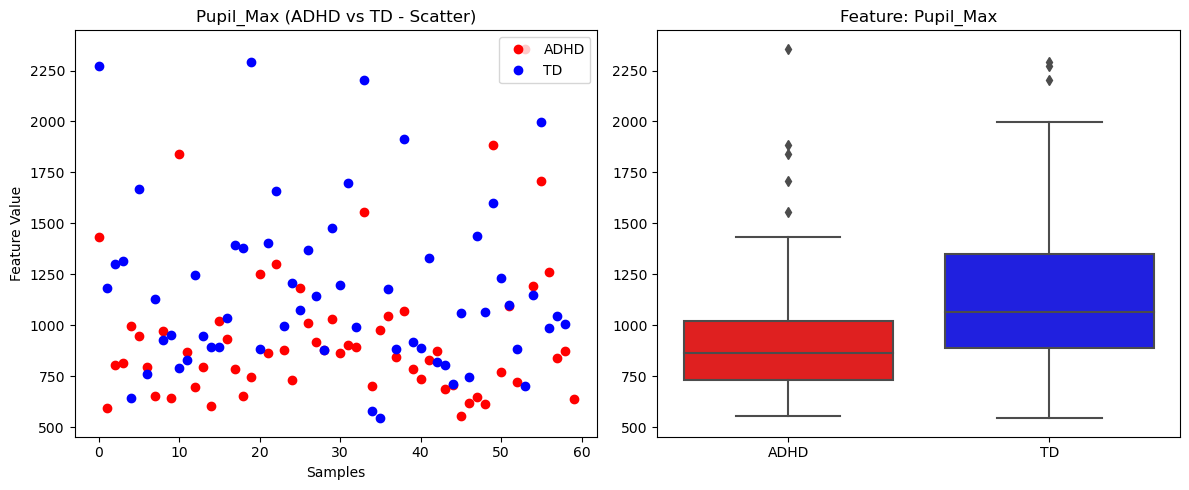

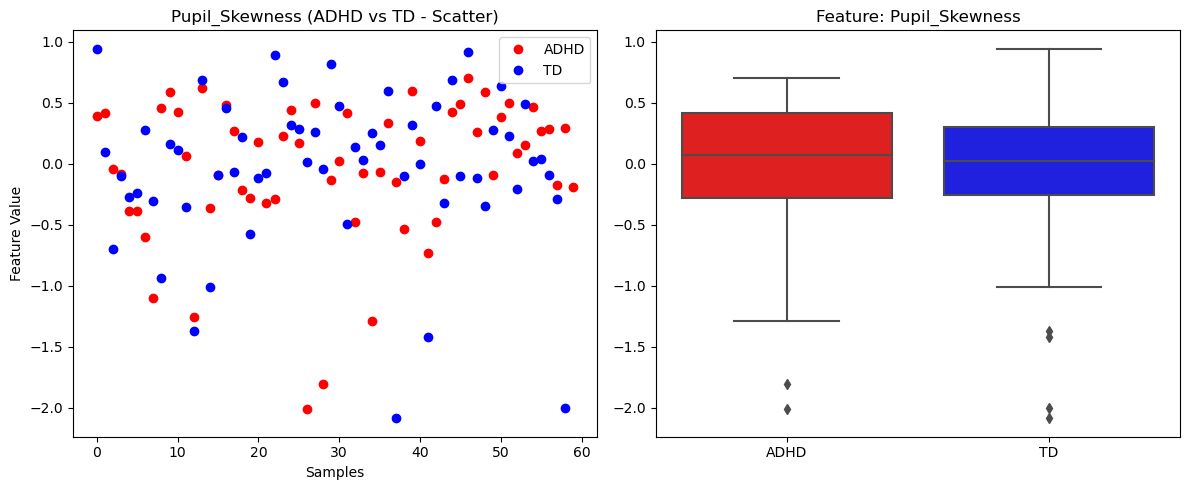

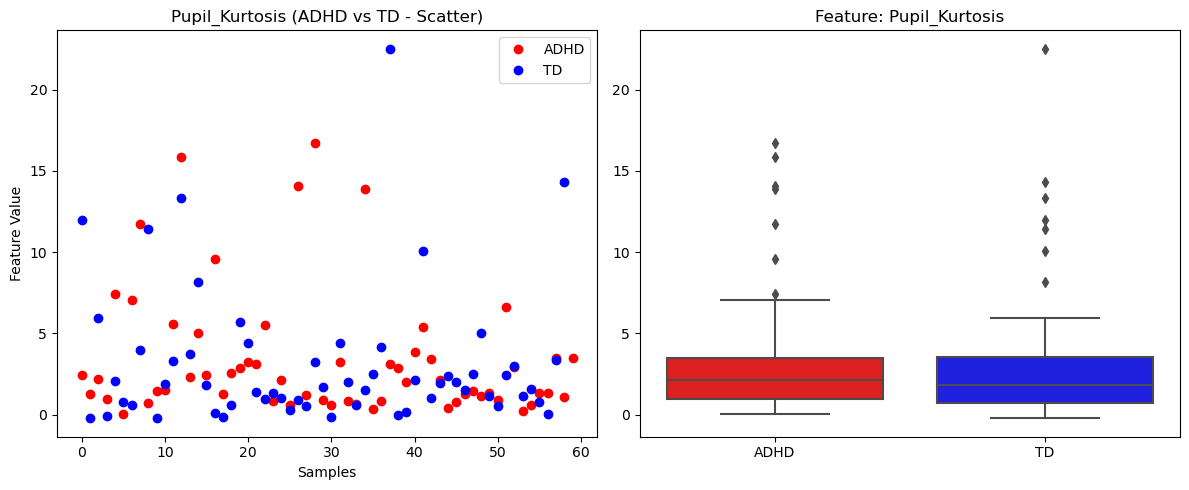

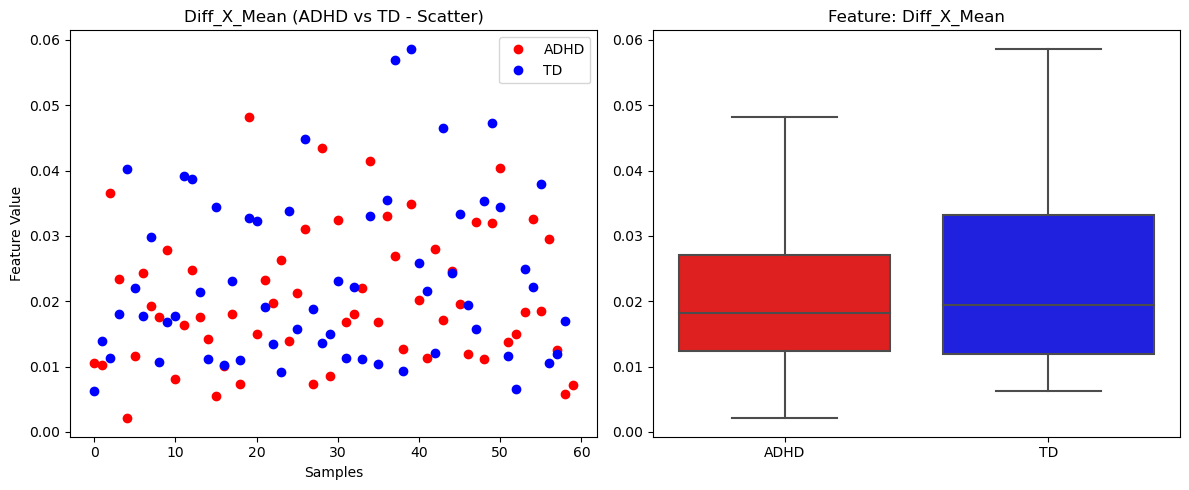

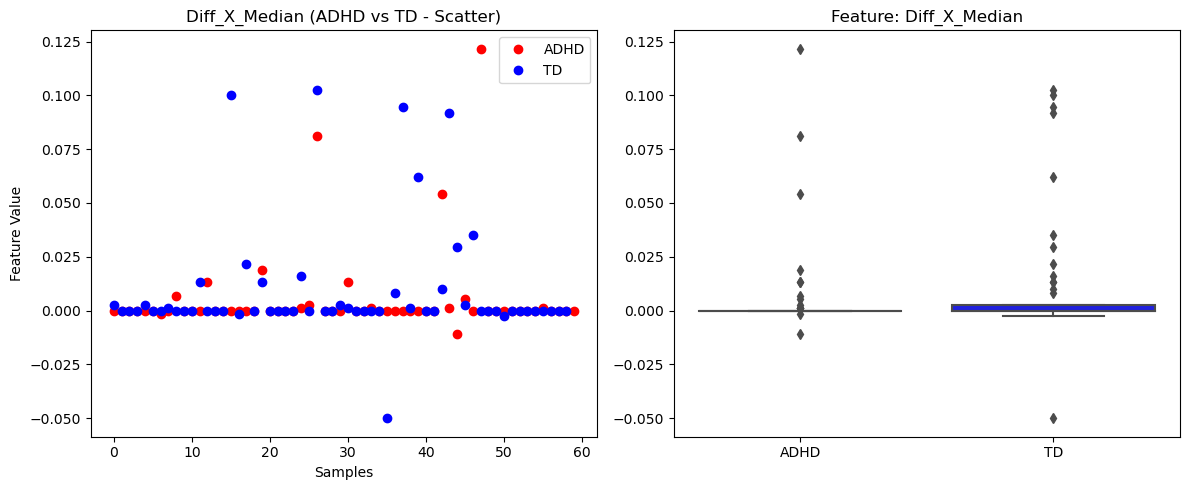

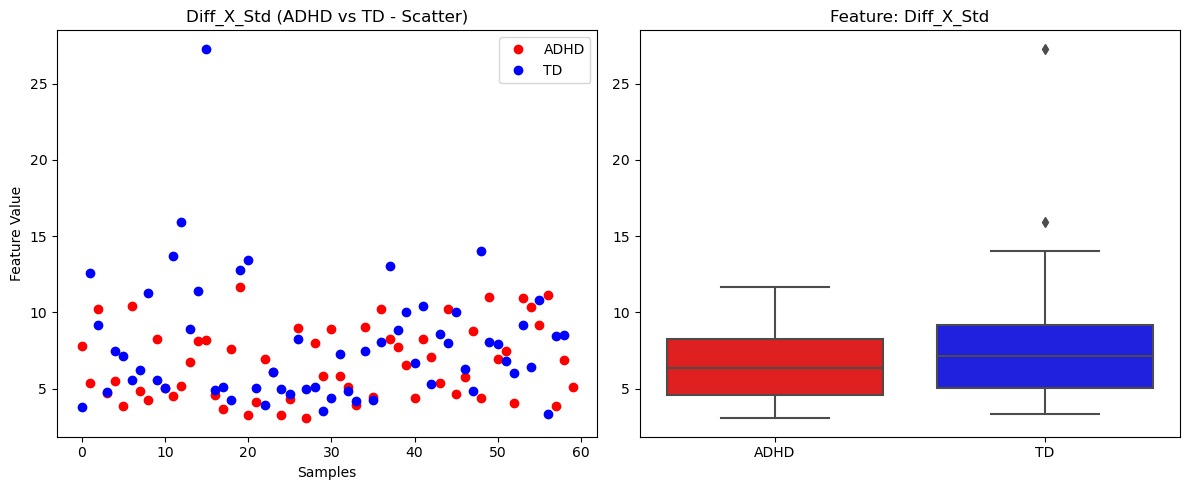

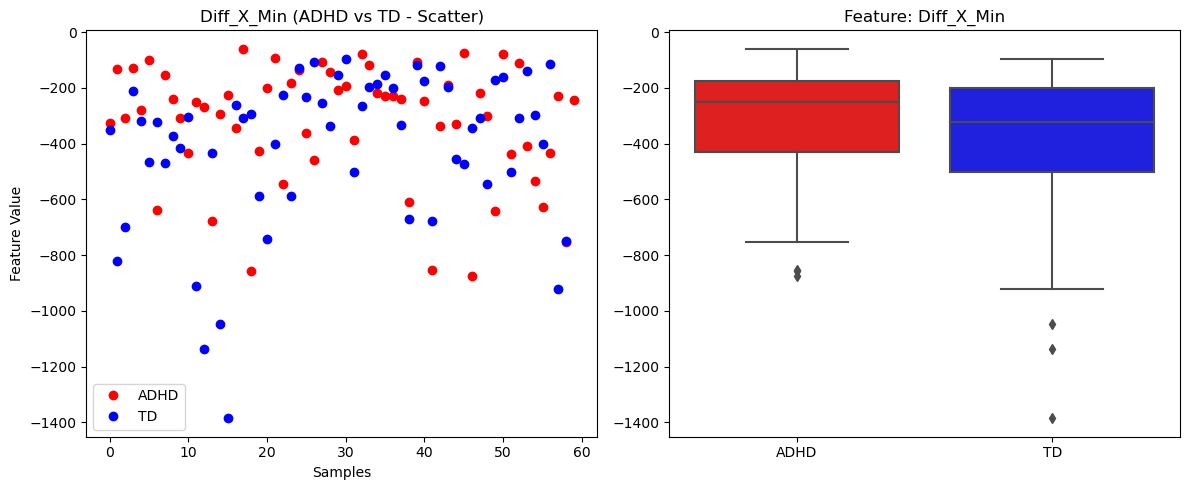

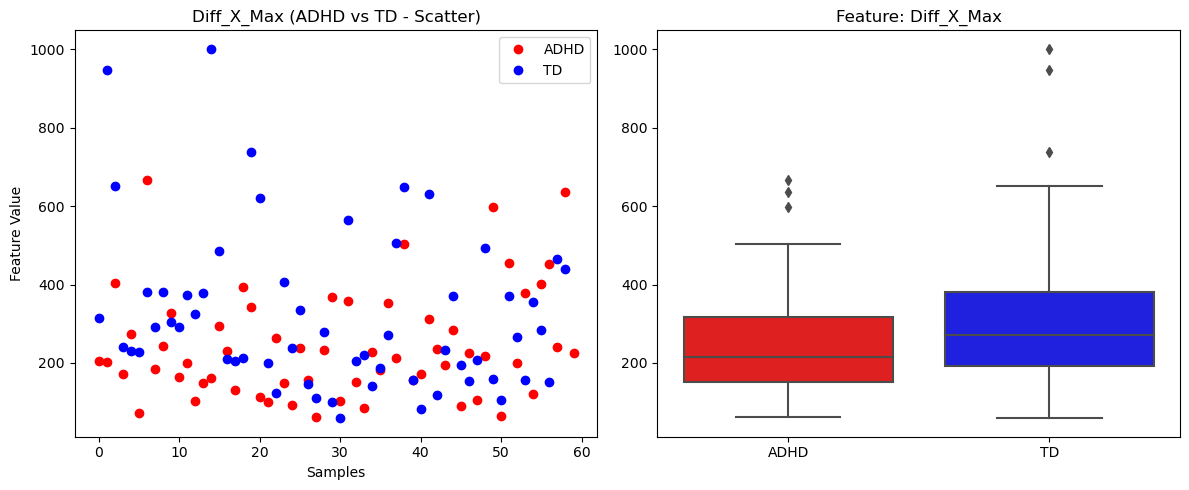

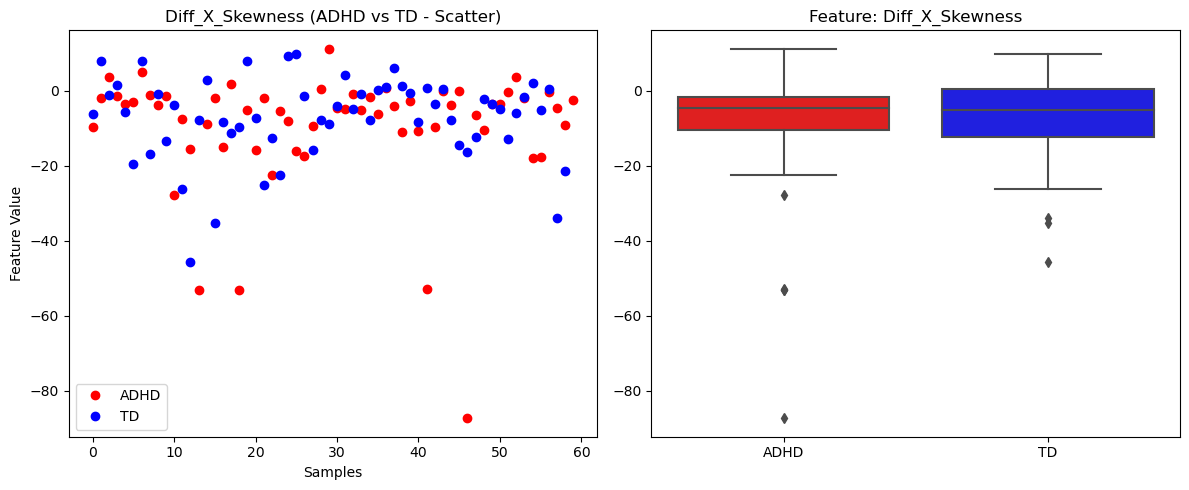

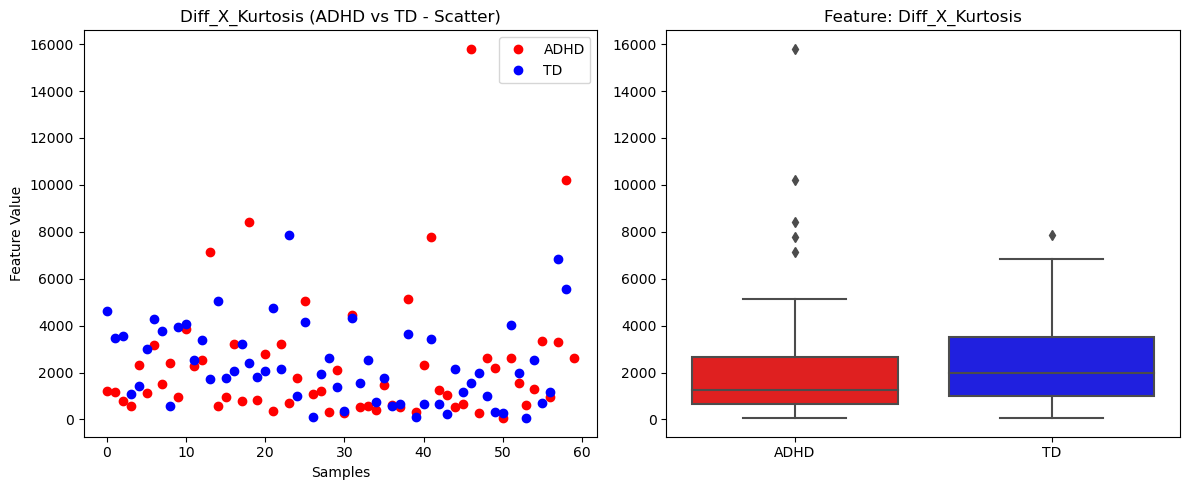

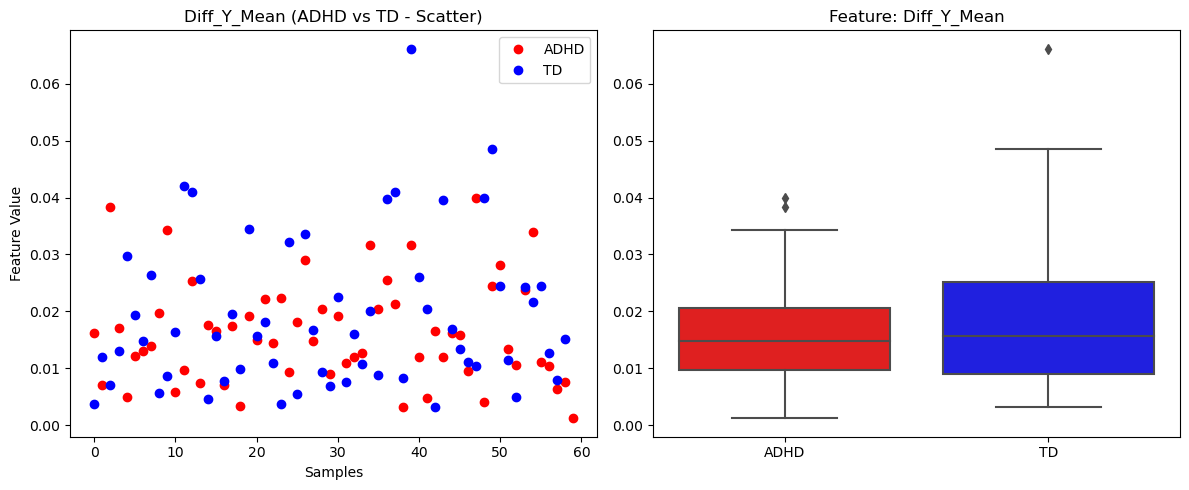

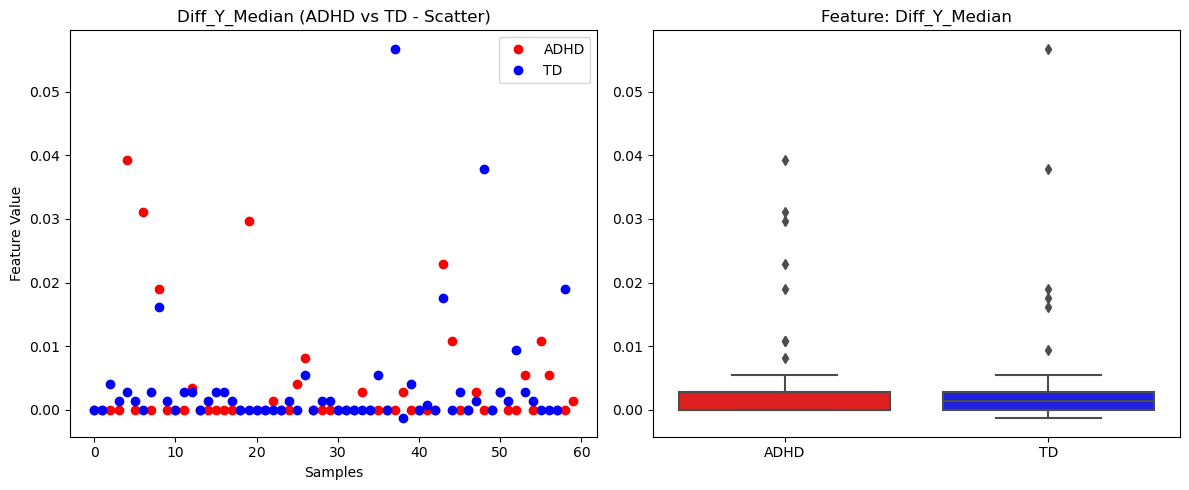

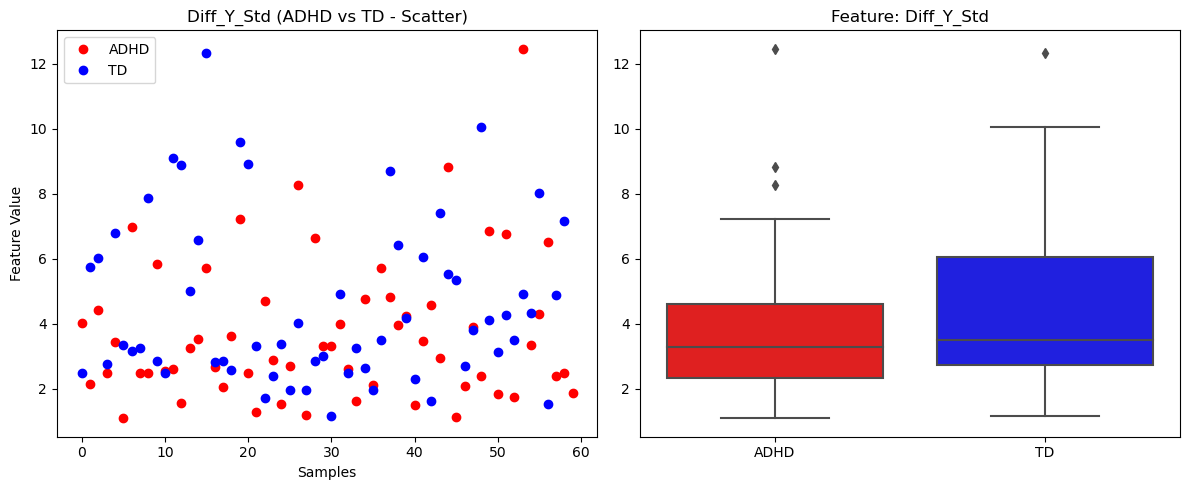

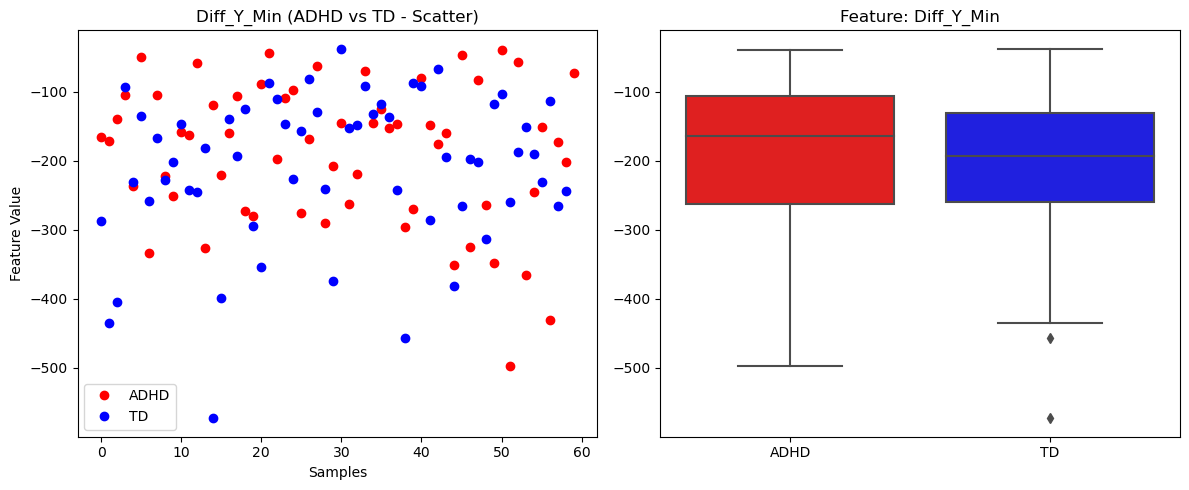

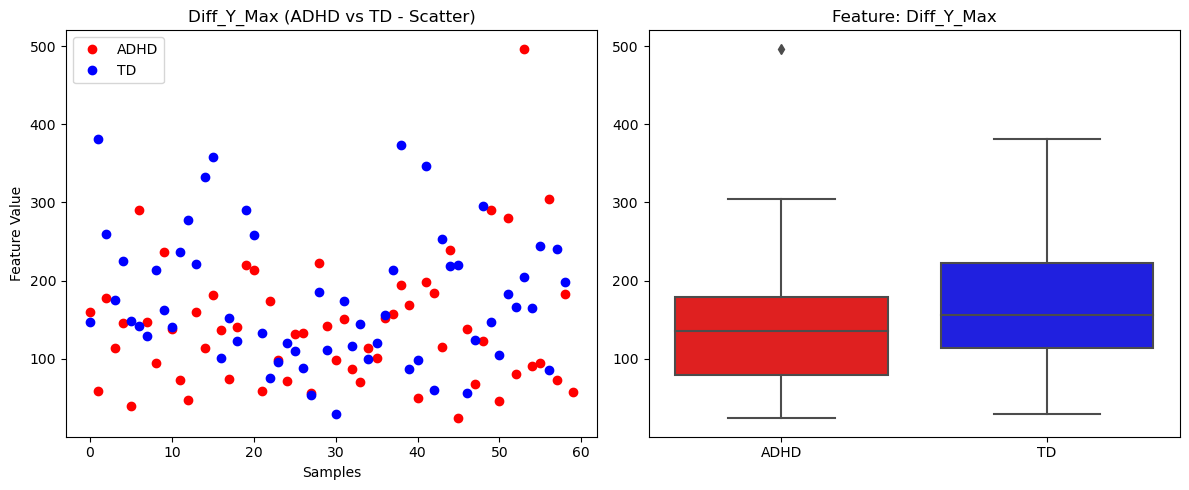

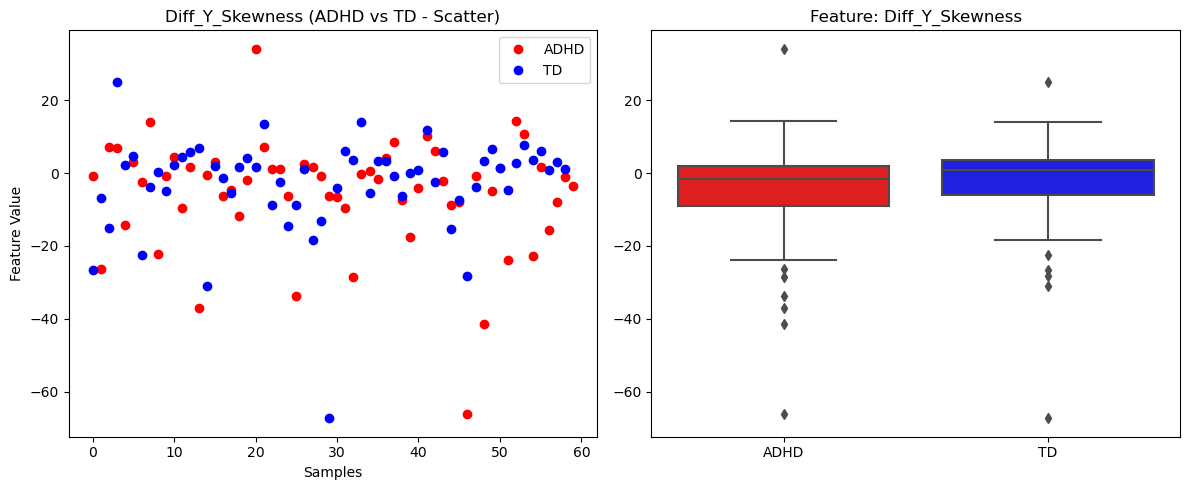

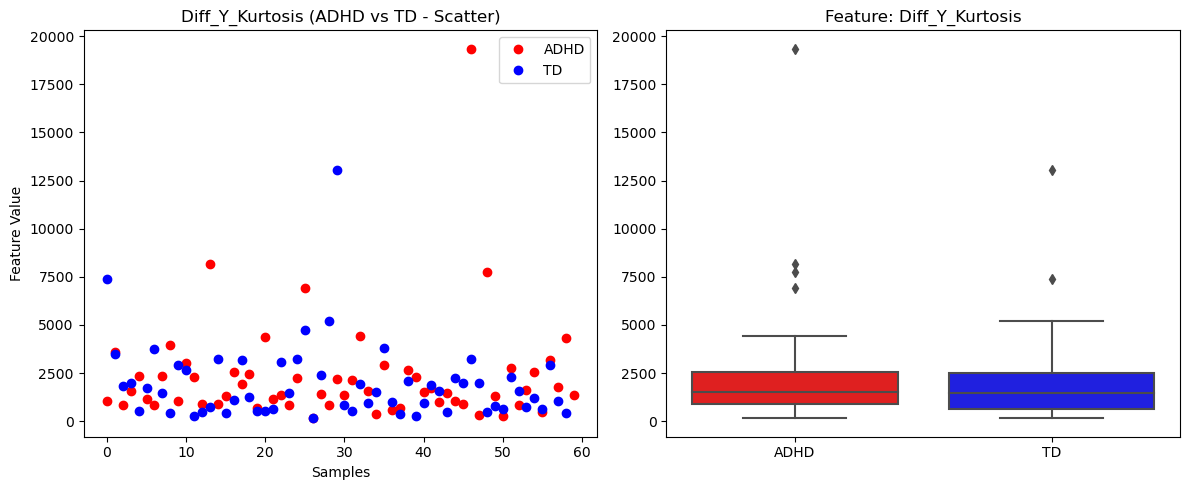

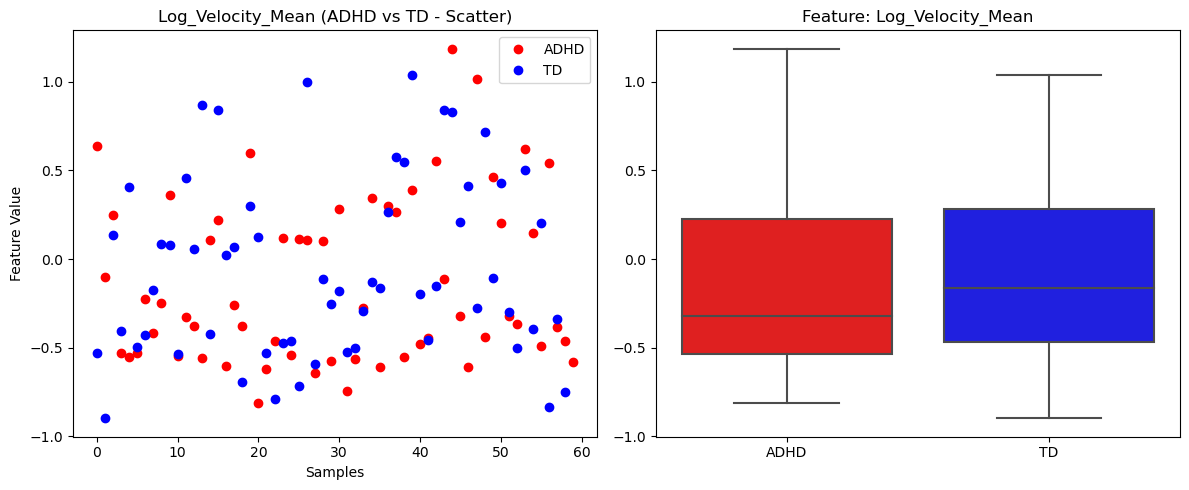

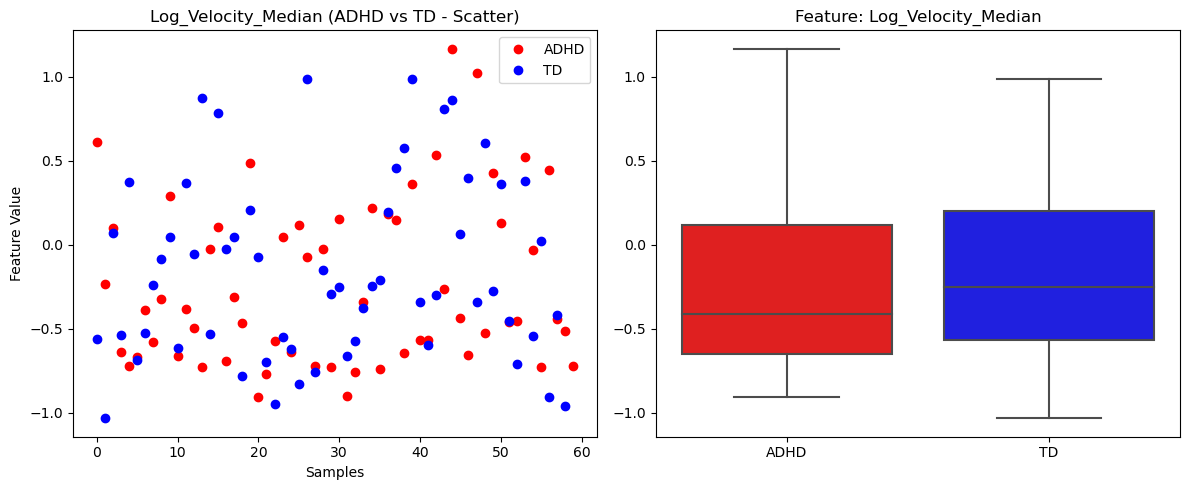

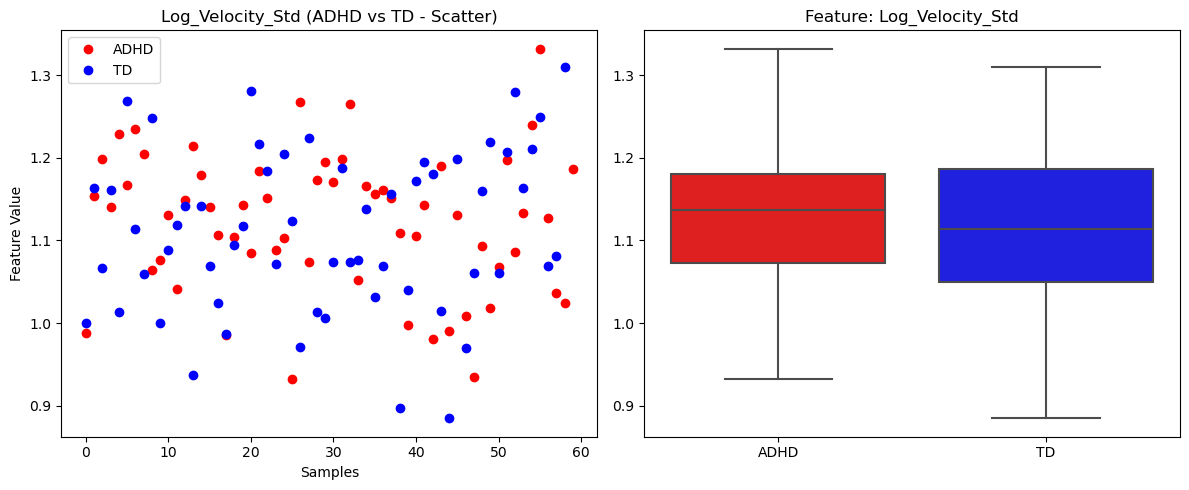

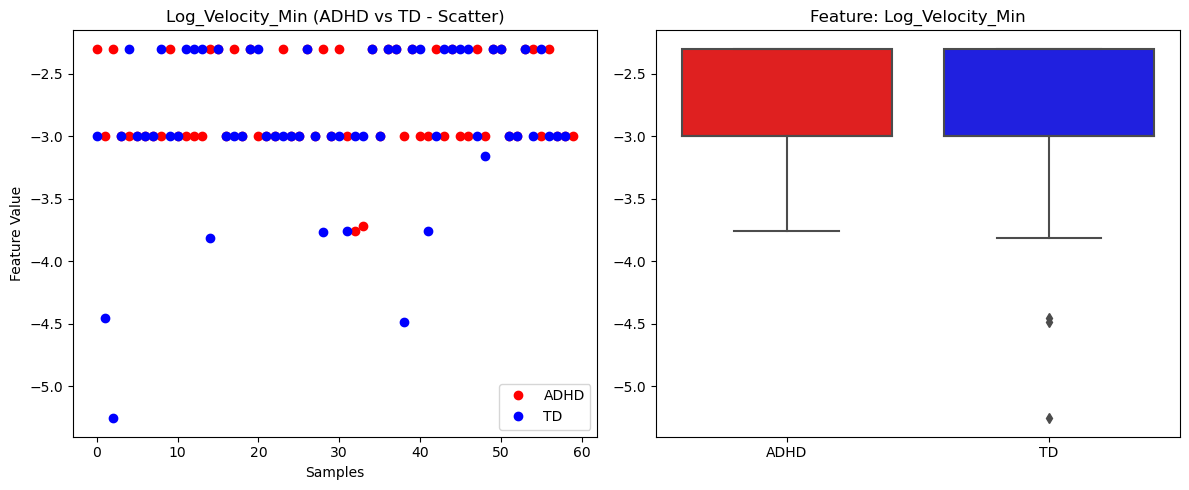

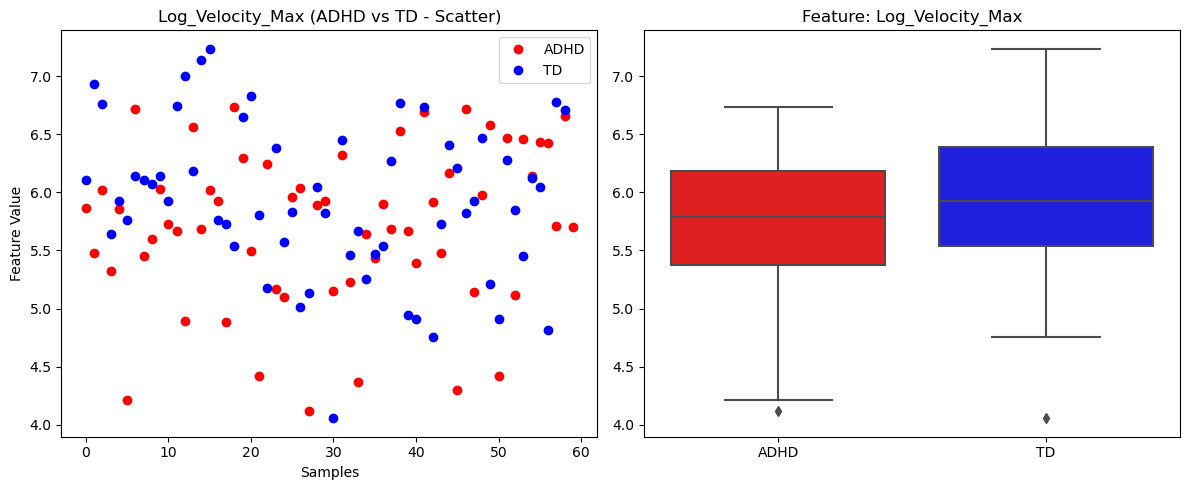

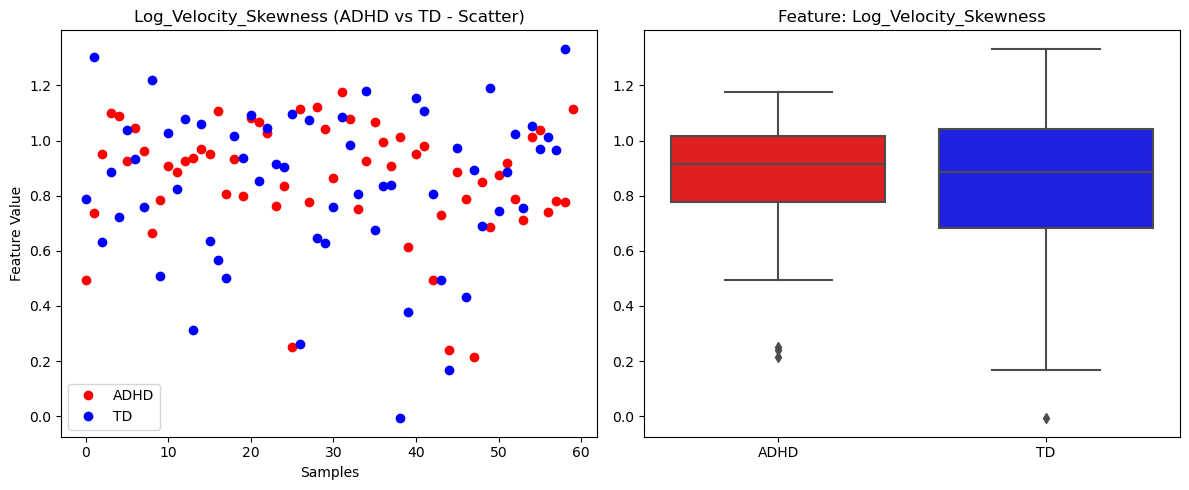

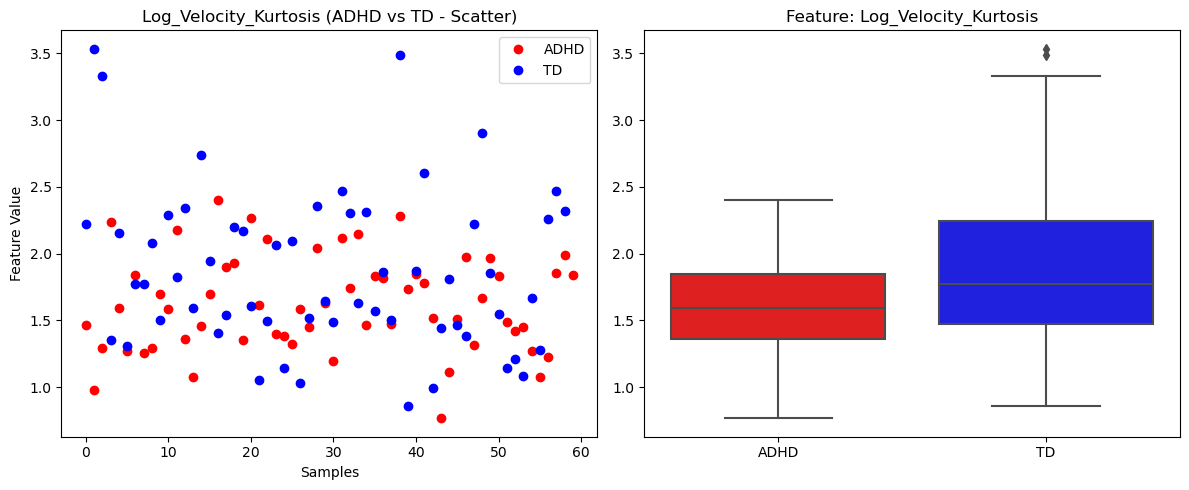

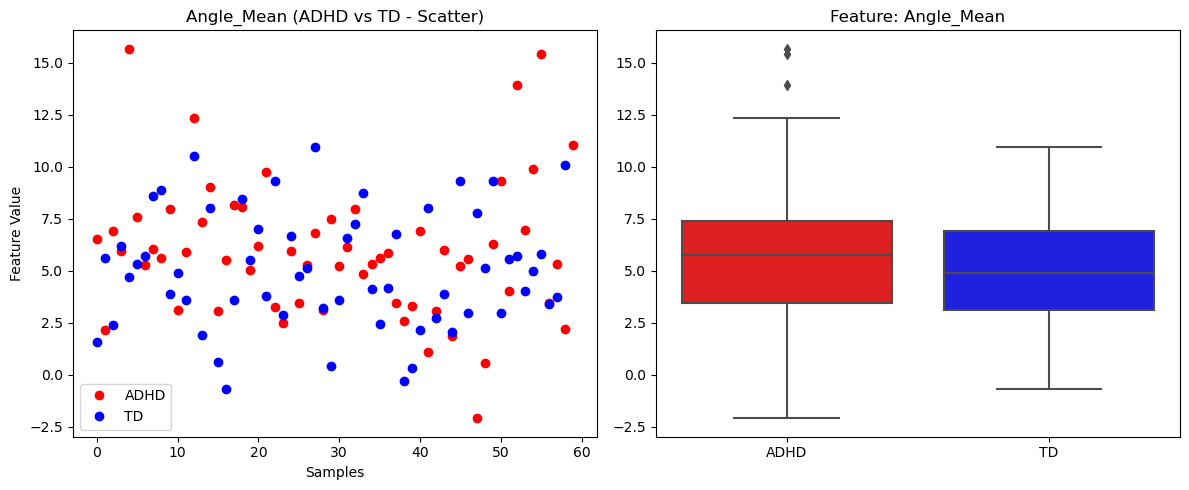

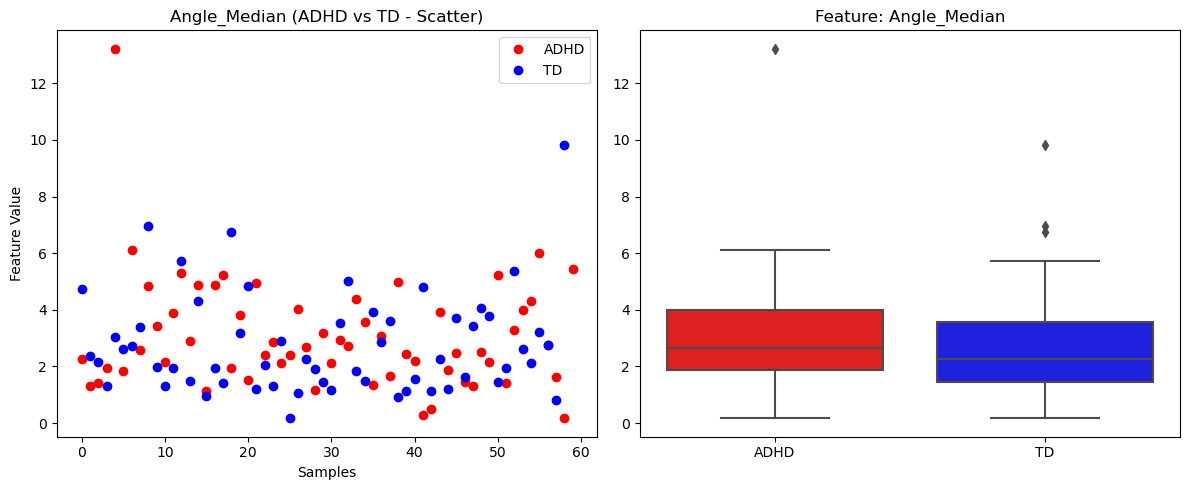

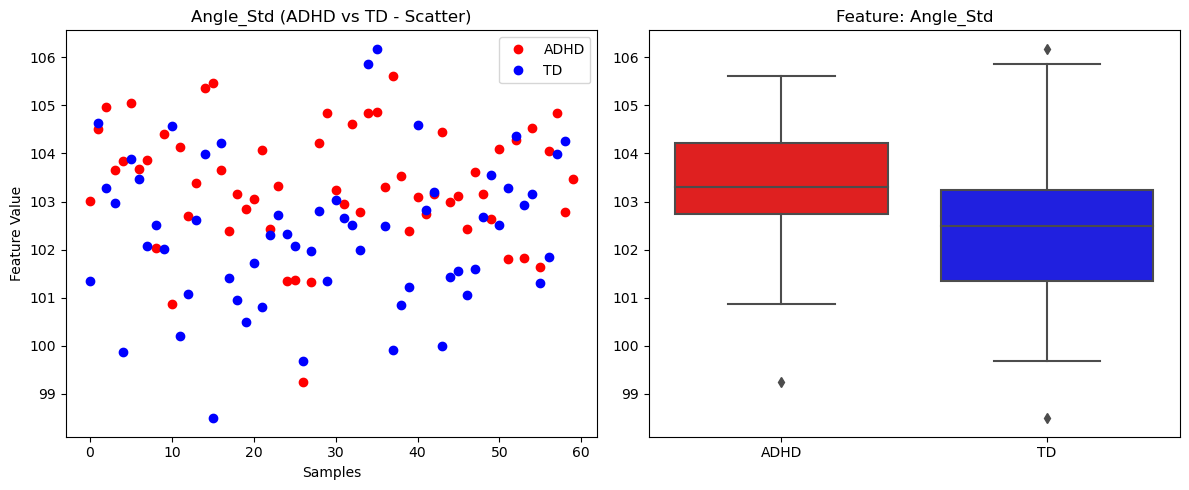

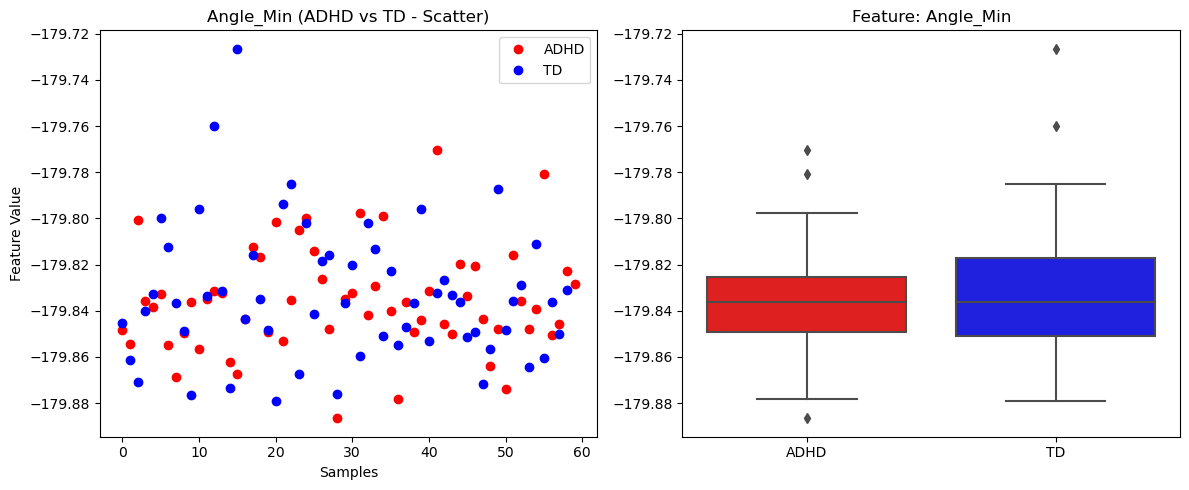

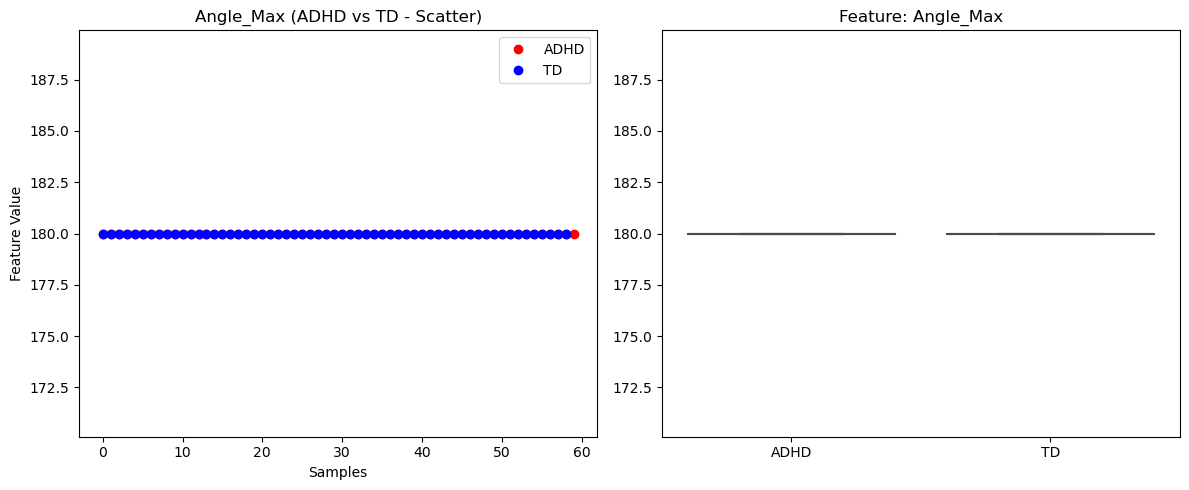

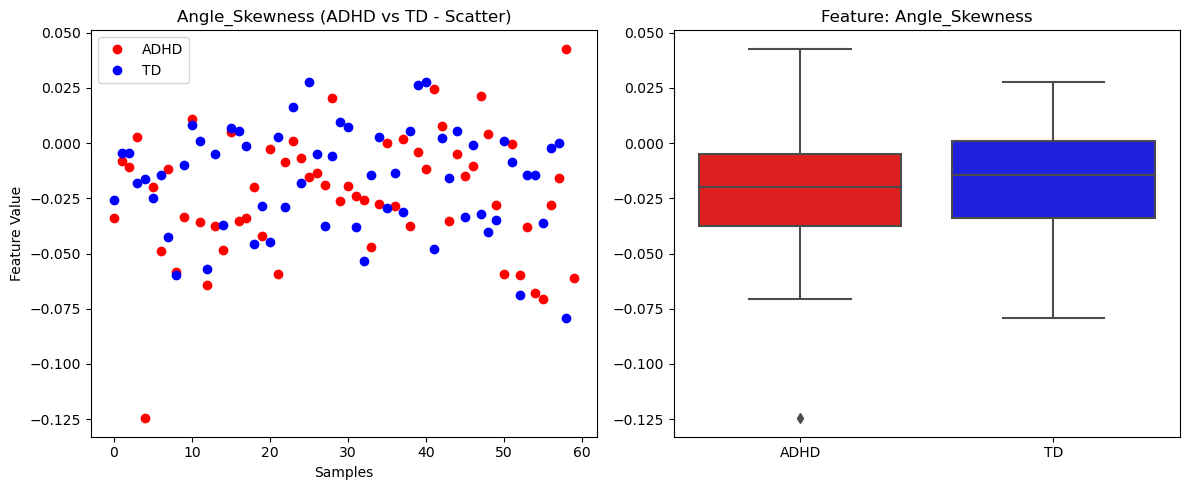

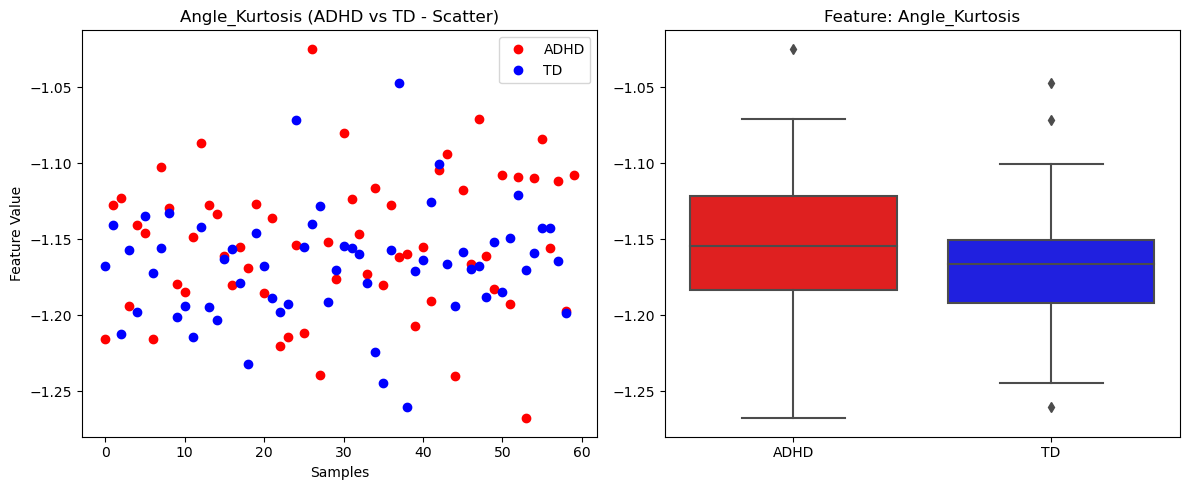

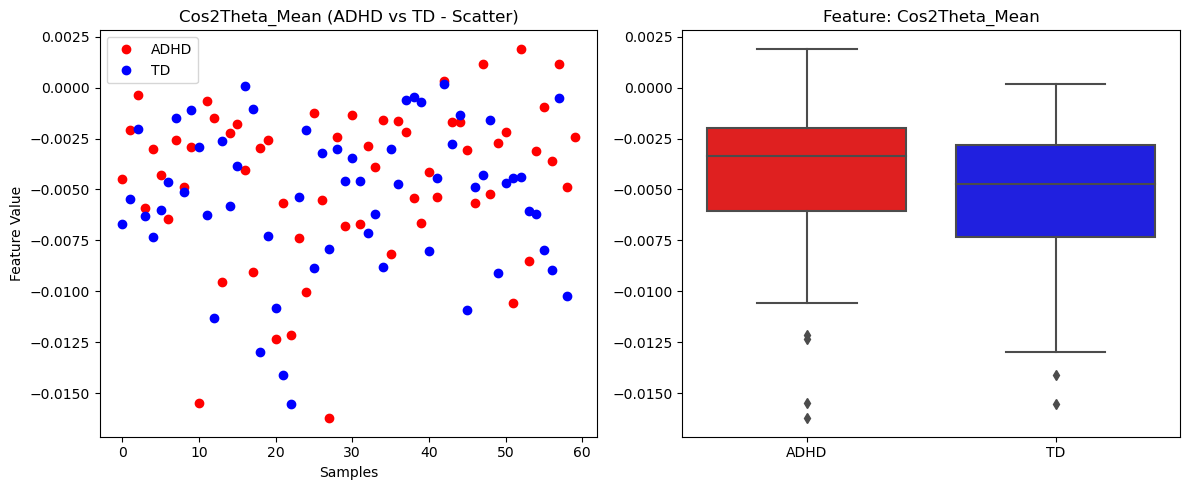

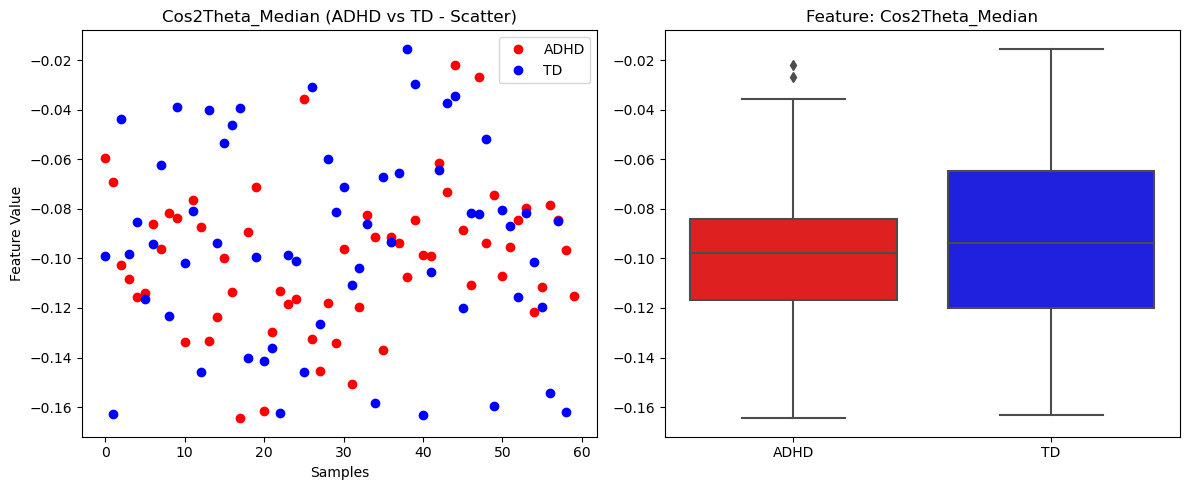

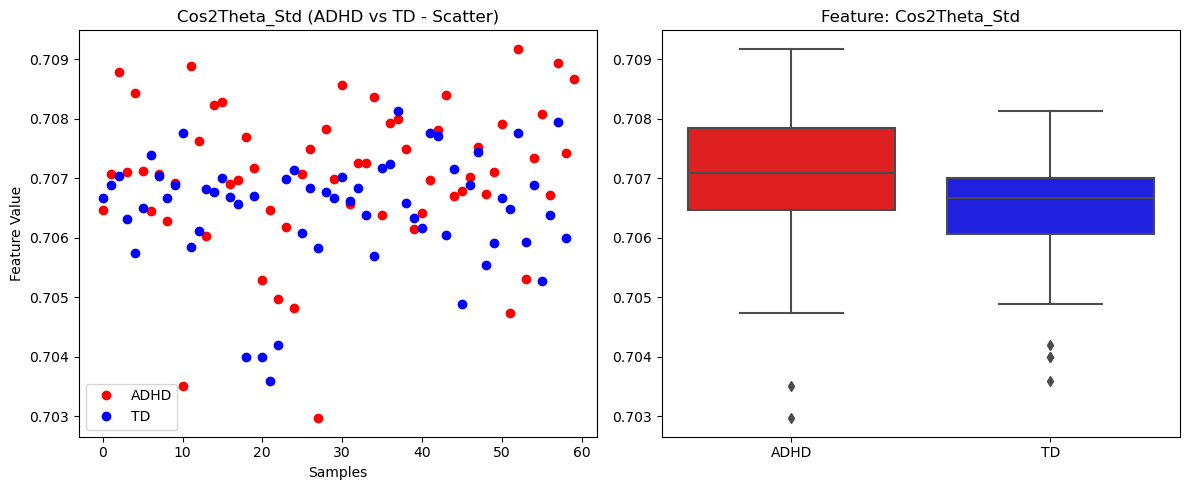

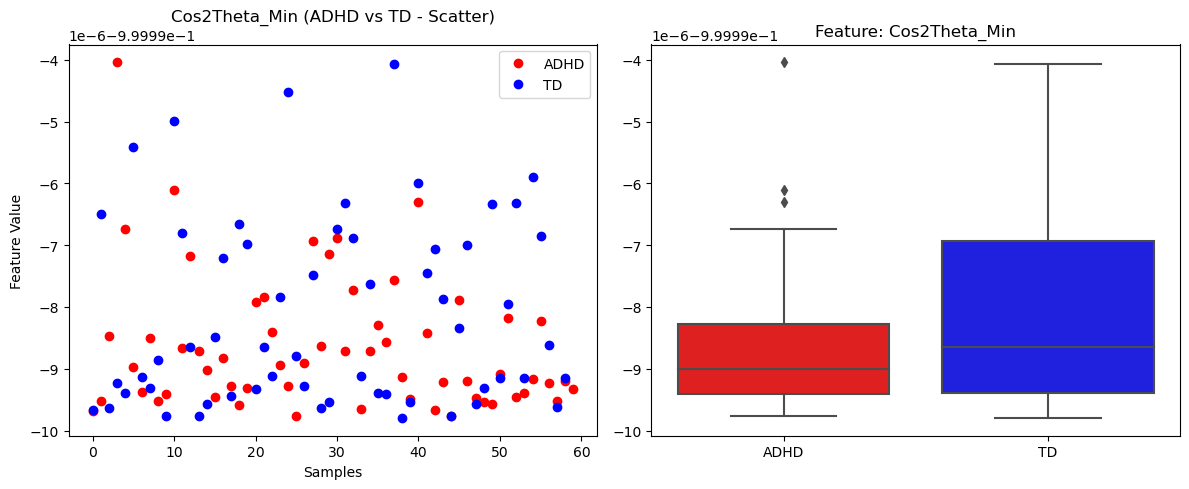

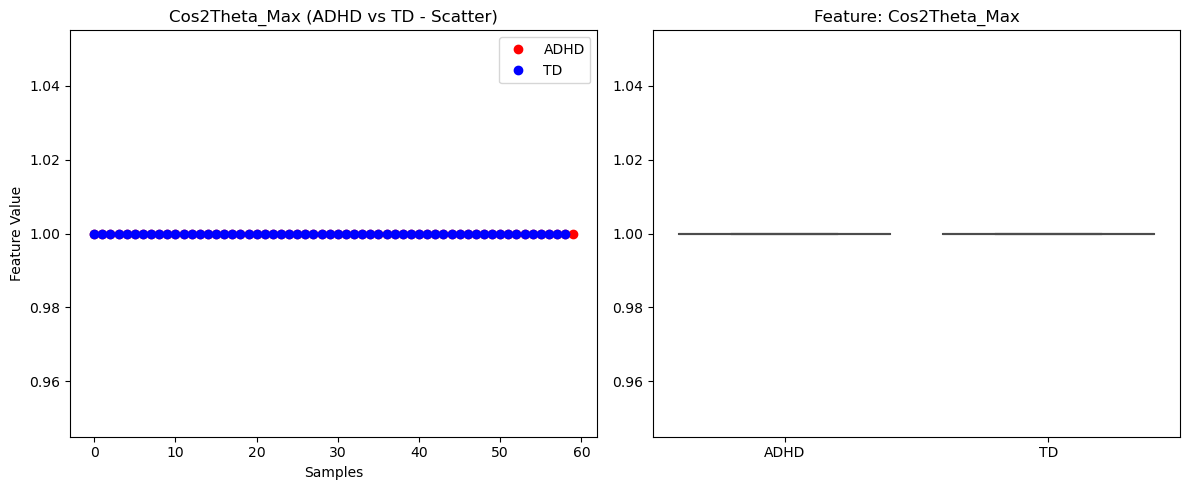

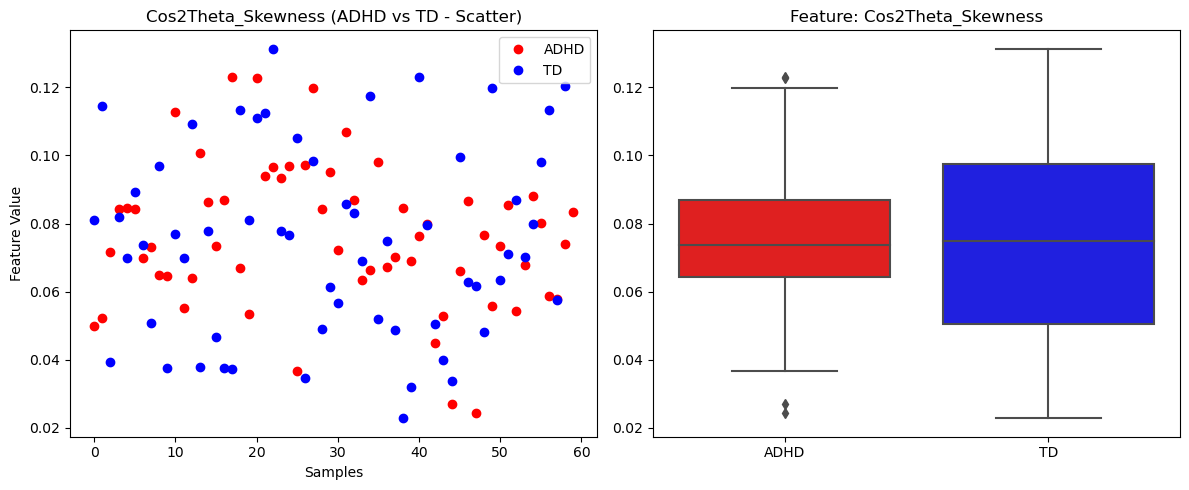

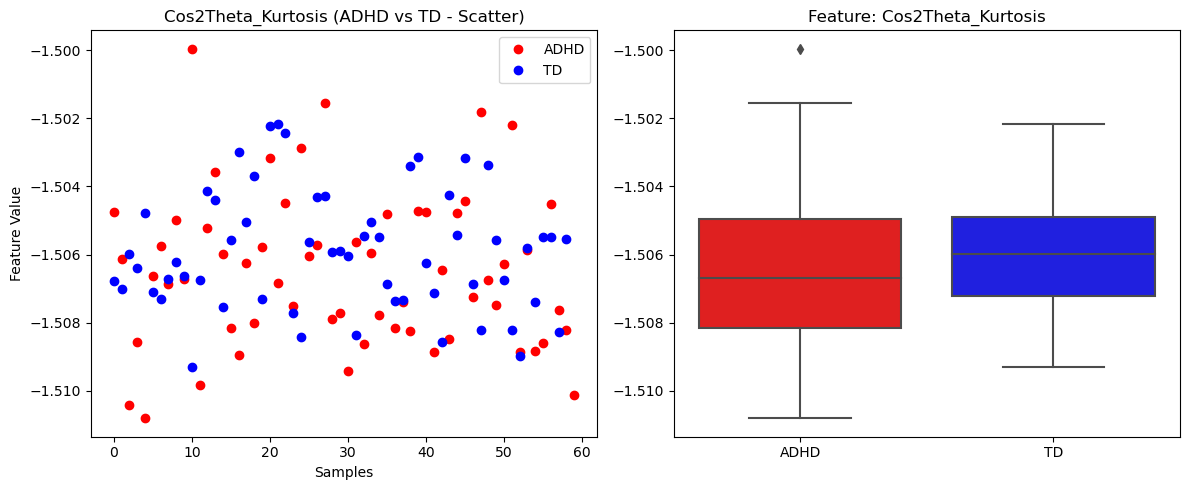

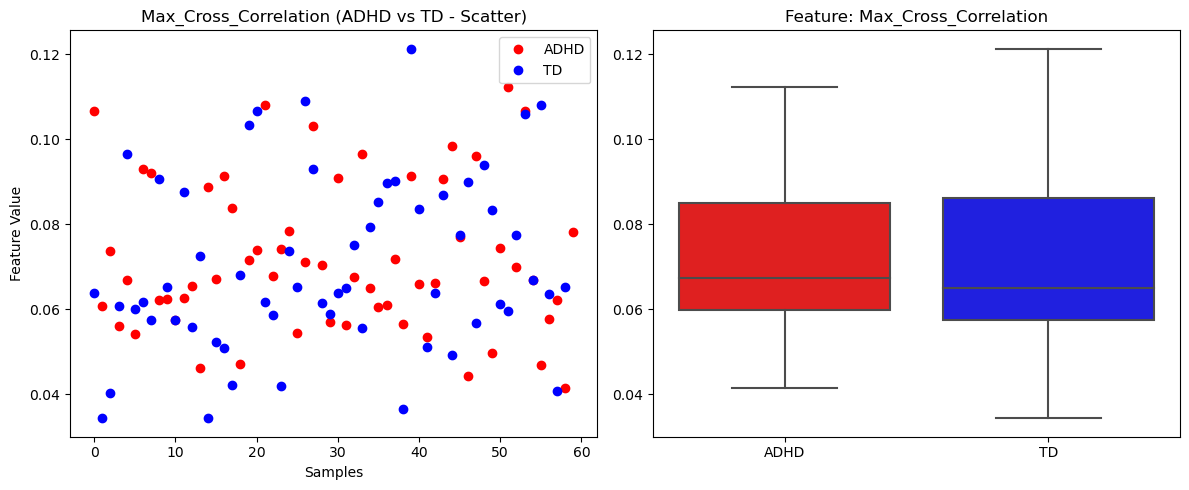

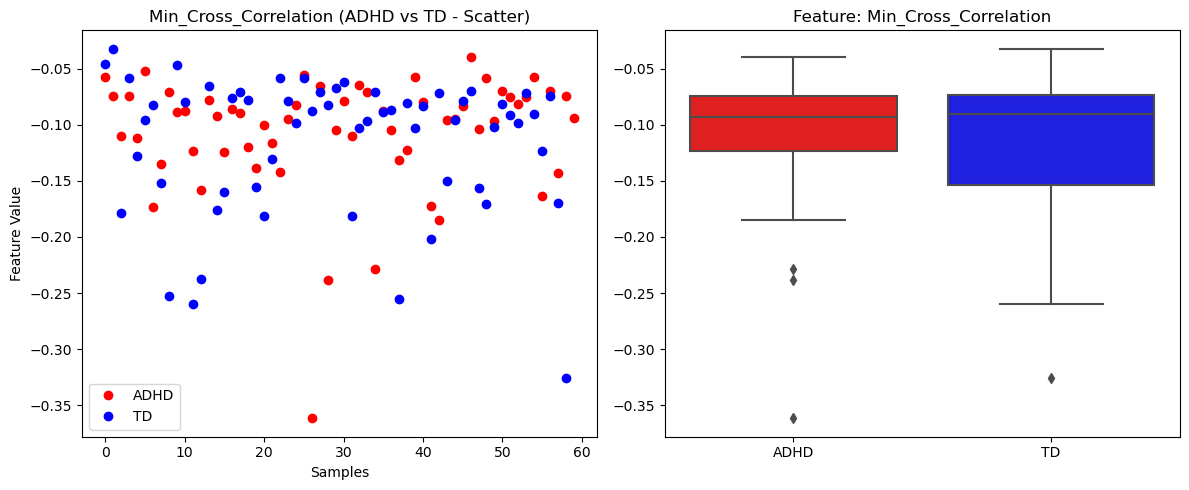

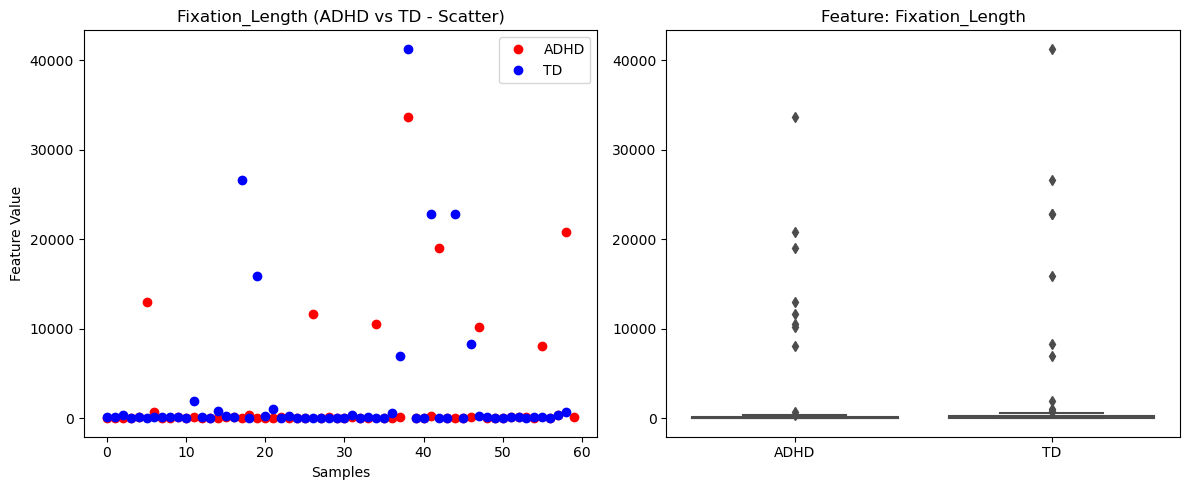

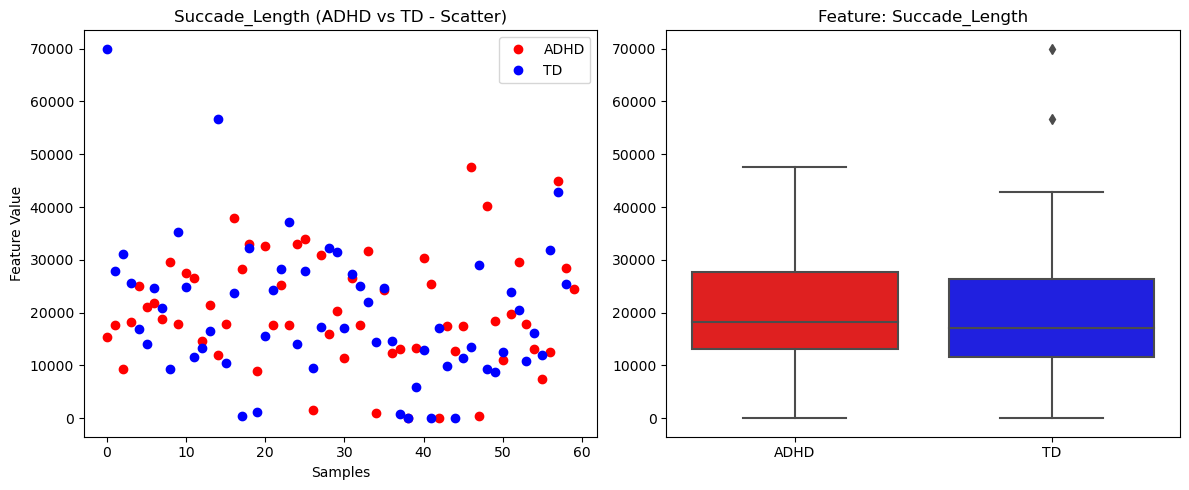

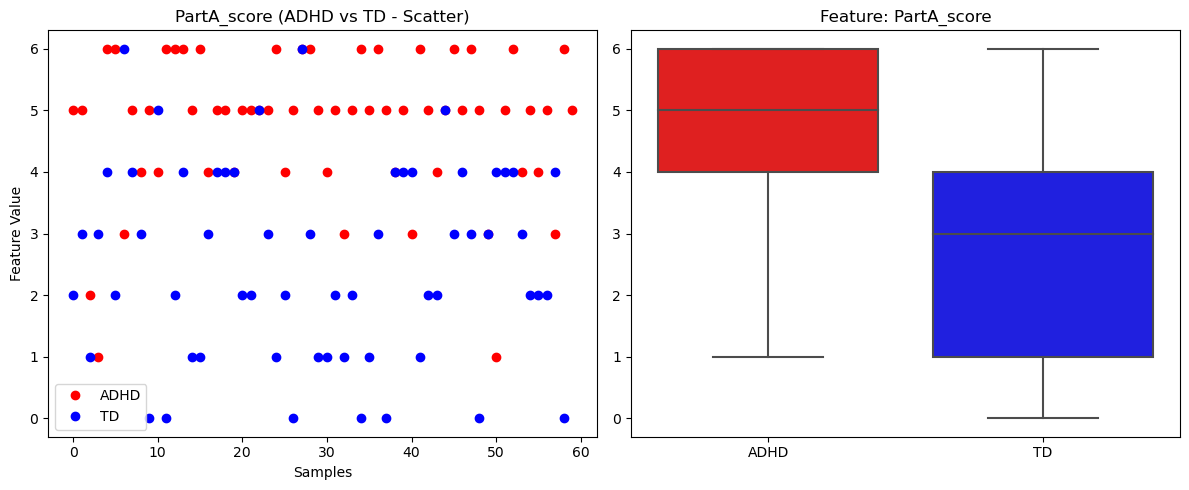

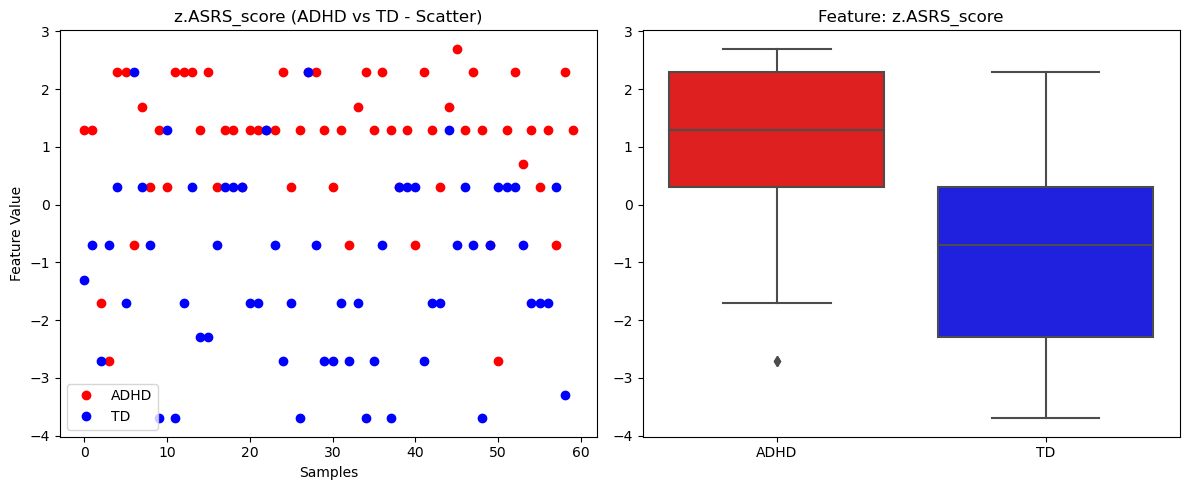

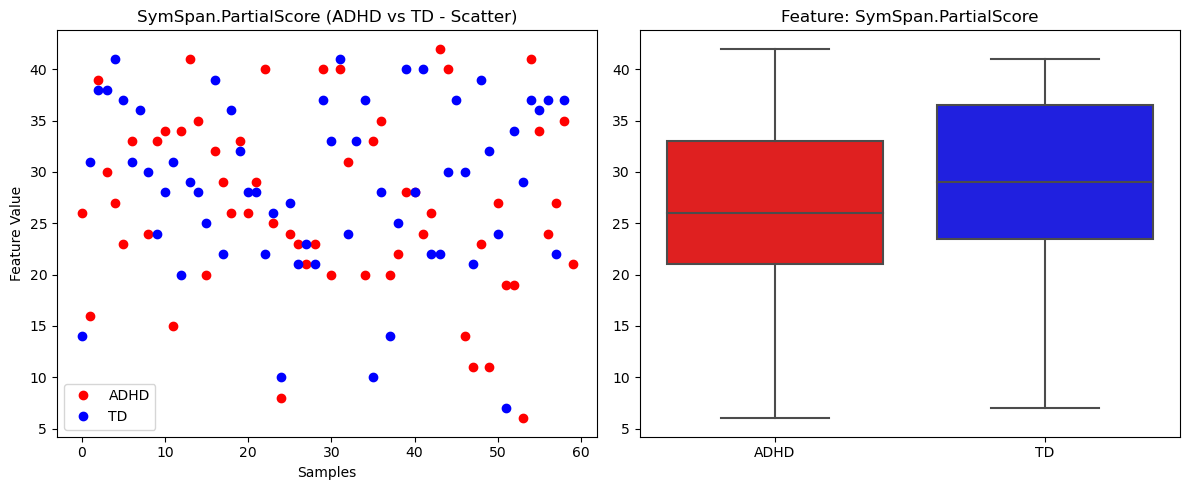

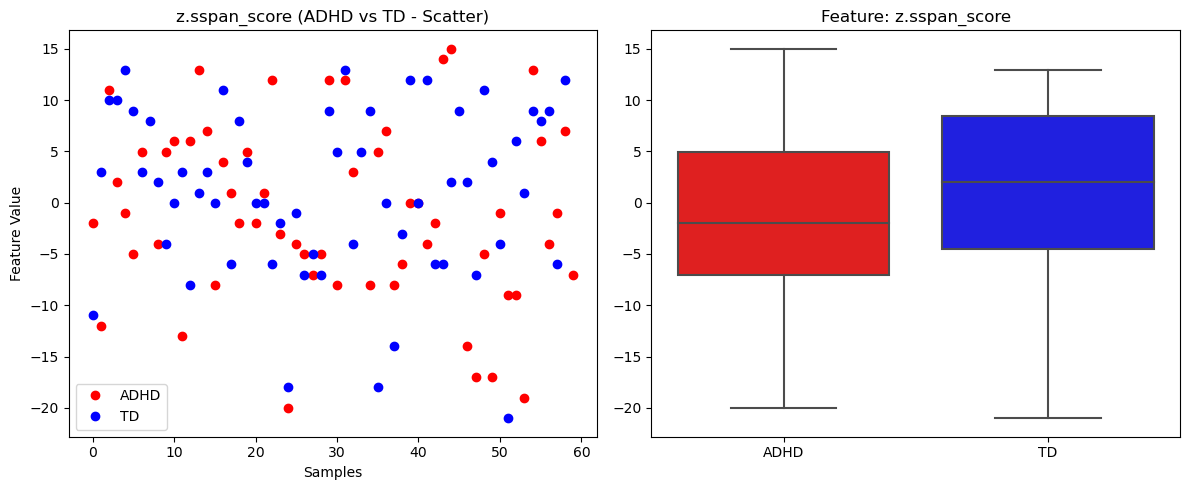

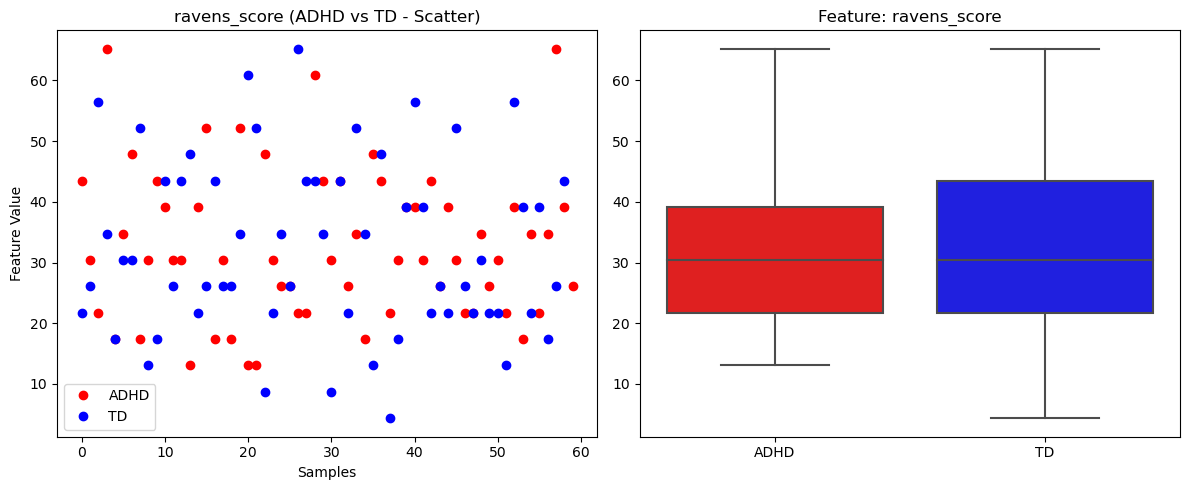

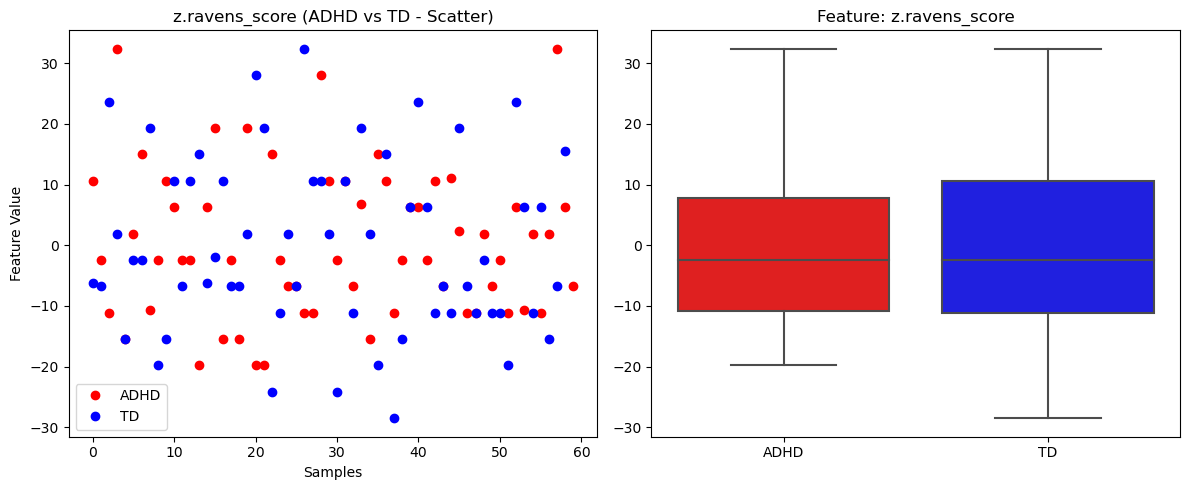

In [78]:
for i, feature in enumerate(Feature_names):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns
    
    # --- Subplot 1: Scatter plot using plt.plot() ---
    axes[0].plot(adhd_features[:, i], 'ro', label="ADHD")  # Red dots for ADHD
    axes[0].plot(td_features[:, i], 'bo', label="TD")  # Blue dots for TD    
    axes[0].set_title(f"{feature} (ADHD vs TD - Scatter)", fontsize=12)
    axes[0].set_xlabel("Samples")
    axes[0].set_ylabel("Feature Value")
    axes[0].legend()
    
    ax = axes[1]
    sns.boxplot(x="Group", y=feature, data=df, ax=ax, palette={"ADHD": "red", "TD": "blue"})  
    ax.set_title(f"Feature: {feature}", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

In [80]:
X = np.nan_to_num(X, nan=0)
X[np.isinf(X)] = 0


In [116]:
from sklearn.preprocessing import StandardScaler
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform X
X = scaler.fit_transform(X)

In [118]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def preprocess_data(X):
    """Replace NaNs and infinite values."""
    df = pd.DataFrame(X)
    
    # Replace infinities with 0
    df.replace([np.inf, -np.inf], 0, inplace=True)
    
    # Drop rows with NaN values or replace NaN with column means (choose whichever is preferred)
    df.fillna(0, inplace=True)  # Replaces NaN with 0 for simplicity
    
    return df

def calculate_vif(X, feature_names, vif_threshold=20.0):
    """Calculate VIF for each feature and remove highly collinear ones."""
    # Columns to keep without applying VIF
#    columns_to_keep = []
    columns_to_keep = []
    
    # Convert X to DataFrame for easier manipulation
    df = pd.DataFrame(X, columns=feature_names)
    
    # Keep the columns that shouldn't be included in VIF calculation
    X_vif = df.drop(columns=columns_to_keep)
    
    # Preprocess dataset (handle NaN and inf)
    df_preprocessed = preprocess_data(X_vif)  # Preprocess the selected features
    
    # Apply VIF calculation on the remaining features
    while True:
        vif_data = pd.DataFrame()
        vif_data["Feature"] = df_preprocessed.columns
        vif_data["VIF"] = [variance_inflation_factor(df_preprocessed.values, i) for i in range(df_preprocessed.shape[1])]
        
        max_vif = vif_data["VIF"].max()
        if max_vif < vif_threshold:
            break  # Stop if all VIF values are below the threshold
        
        drop_feature = vif_data.loc[vif_data["VIF"].idxmax(), "Feature"]
        df_preprocessed.drop(columns=[drop_feature], inplace=True)
        print(f"Removing '{drop_feature}' due to high VIF: {max_vif:.2f}")
    
    # Concatenate the VIF-reduced features back with the kept columns
    final_df = pd.concat([df[columns_to_keep], df_preprocessed], axis=1)
    
    return final_df

# Example usage with  data (replace X and Feature_names with your actual dataset)
# X: Your input features as a NumPy array
# Feature_names: List of column names

# Run VIF calculation and feature reduction
reduced_X = calculate_vif(X, Feature_names)

# Show remaining features after VIF filtering
print("Remaining features after VIF filtering:")
print(reduced_X.columns.tolist())



C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Removing 'PartA_score' due to high VIF: inf


C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


Removing 'Log_Velocity_Median' due to high VIF: 40791.24


C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


...

C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


Removing 'Log_Velocity_Mean' due to high VIF: 28.98
Removing 'Cos2Theta_Std' due to high VIF: 24.54


C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


Removing 'Diff_X_Max' due to high VIF: 23.60
Removing 'Cos2Theta_Median' due to high VIF: 21.11
Remaining features after VIF filtering:
['X_Mean', 'X_Std', 'X_Min', 'X_Max', 'X_Skewness', 'X_Kurtosis', 'Y_Mean', 'Y_Std', 'Y_Min', 'Y_Max', 'Y_Skewness', 'Y_Kurtosis', 'Pupil_Median', 'Pupil_Std', 'Pupil_Min', 'Pupil_Skewness', 'Pupil_Kurtosis', 'Diff_X_Mean', 'Diff_X_Median', 'Diff_X_Std', 'Diff_X_Skewness', 'Diff_X_Kurtosis', 'Diff_Y_Mean', 'Diff_Y_Median', 'Diff_Y_Max', 'Diff_Y_Skewness', 'Diff_Y_Kurtosis', 'Log_Velocity_Std', 'Log_Velocity_Min', 'Log_Velocity_Max', 'Log_Velocity_Kurtosis', 'Angle_Mean', 'Angle_Median', 'Angle_Std', 'Angle_Min', 'Angle_Max', 'Angle_Skewness', 'Angle_Kurtosis', 'Cos2Theta_Mean', 'Cos2Theta_Min', 'Cos2Theta_Max', 'Cos2Theta_Kurtosis', 'Max_Cross_Correlation', 'Min_Cross_Correlation', 'Fixation_Length', 'Succade_Length', 'z.ASRS_score', 'z.sspan_score', 'z.ravens_score']


C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


In [85]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def preprocess_data(X):
    """Replace NaNs and infinite values."""
    df = pd.DataFrame(X)
    df.replace([np.inf, -np.inf], 0, inplace=True)
    df.fillna(0, inplace=True)
    return df

def get_features_by_vif_thresholds(X, feature_names, thresholds=range(5, 31)):
    columns_to_keep = []
    df = pd.DataFrame(X, columns=feature_names)
    results = {}

    for threshold in thresholds:
        df_vif = df.drop(columns=columns_to_keep).copy()
        df_vif = preprocess_data(df_vif)

        while True:
            vif_data = pd.DataFrame()
            vif_data["Feature"] = df_vif.columns
            vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

            max_vif = vif_data["VIF"].max()
            if max_vif < threshold:
                break

            drop_feature = vif_data.loc[vif_data["VIF"].idxmax(), "Feature"]
            df_vif.drop(columns=[drop_feature], inplace=True)

        retained_features = columns_to_keep + df_vif.columns.tolist()
        results[threshold] = retained_features

    # Convert to DataFrame where each column is a threshold and rows are feature names
    result_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in results.items()]))

    return result_df

# Example usage:
result_df = get_features_by_vif_thresholds(X, Feature_names)
# print(result_df)


C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self

C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self

C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self

C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self

C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1.

...

C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self

C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self

C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self

C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self

C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\Users\Farzana\.conda\envs\DataScience\Lib\site-packages\statsmodels\regression\linear_model.py:1754: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self

In [87]:
with pd.ExcelWriter("VIF.xlsx") as writer:
    result_df.to_excel(writer, sheet_name="VIF", index=False)


In [120]:
reduced_X.shape

(119, 49)

In [97]:
X = np.asarray(reduced_X)

Accuracy: 0.7777777777777778
Confusion Matrix:
 [[13  4]
 [ 4 15]]
Normalized Confusion Matrix:
 [[0.76470588 0.23529412]
 [0.21052632 0.78947368]]


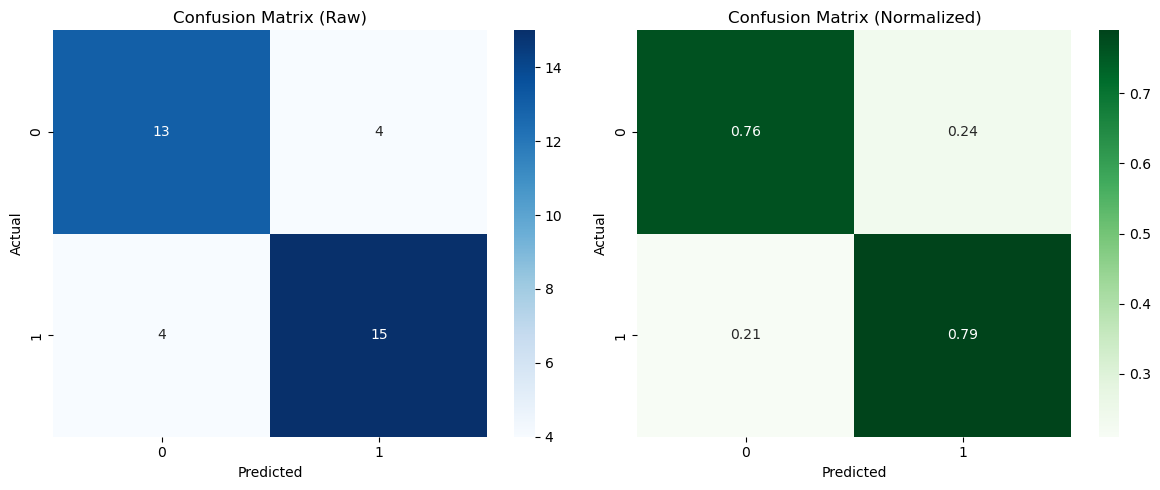

In [103]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, shuffle=True)

# Train Model
LR_model = LogisticRegression(max_iter=1000)
LR_model.fit(X_train, Y_train)

# Predict
Y_pred = LR_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(Y_test, Y_pred))

# Raw Confusion Matrix
cm_raw = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:\n", cm_raw)

# Normalized Confusion Matrix
cm_norm = confusion_matrix(Y_test, Y_pred, normalize='true')
print("Normalized Confusion Matrix:\n", cm_norm)


# Visualize Raw Confusion Matrix
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Raw)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Visualize Normalized Confusion Matrix
plt.subplot(1, 2, 2)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens')
plt.title('Confusion Matrix (Normalized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()


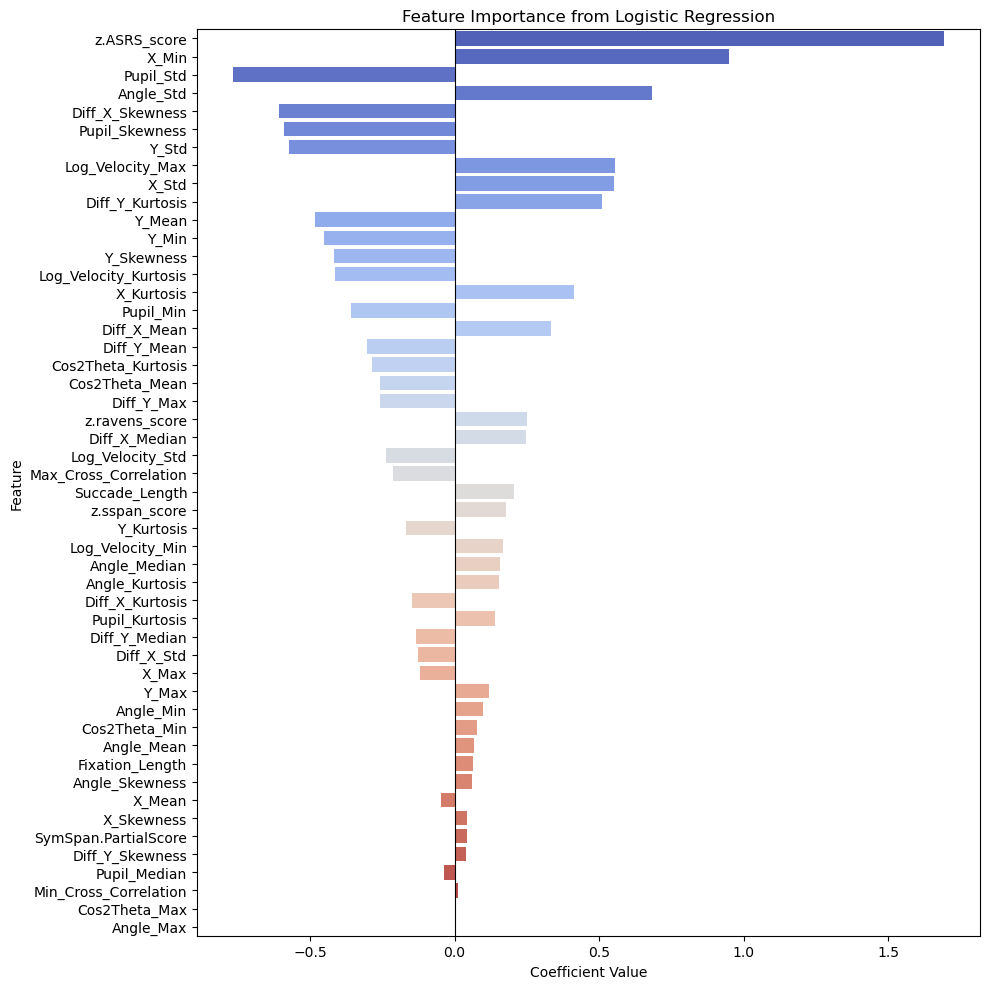

In [104]:
coefficients = LR_model.coef_[0]

# Get feature names (only if X_train is a DataFrame)
feature_names = reduced_X.columns.tolist()

# Create a table of features and their coefficients
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute coefficient values for better visibility
feature_importance['abs_coef'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='abs_coef', ascending=False)

# Plot
plt.figure(figsize=(10, 10))
sns.barplot(data=feature_importance, y='Feature', x='Coefficient', palette='coolwarm')
plt.title('Feature Importance from Logistic Regression')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [111]:
coefficients = LR_model.coef_[0]

# Get feature names (only if X_train is a DataFrame)
feature_names = reduced_X.columns.tolist()

# Create a table of features and their coefficients
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
# Sort by absolute value of coefficients (optional, for better readability)
feature_importance = feature_importance.reindex(
    feature_importance['Coefficient'].abs().sort_values(ascending=False).index
)
# Create the feature importance DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Add absolute value as importance
feature_importance['Importance'] = feature_importance['Coefficient'].abs()

# Sort by importance (absolute value of coefficient)
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Round for readability (optional)
feature_importance = feature_importance.round(4)

# Drop the Coefficient column
feature_importance = feature_importance.drop(columns=['Coefficient'])

# Print the table with only Feature and Importance
print(feature_importance.to_string(index=False))

              Feature  Importance
         z.ASRS_score      1.6949
                X_Min      0.9496
            Pupil_Std      0.7677
            Angle_Std      0.6828
      Diff_X_Skewness      0.6057
       Pupil_Skewness      0.5901
                Y_Std      0.5740
     Log_Velocity_Max      0.5546
                X_Std      0.5515
      Diff_Y_Kurtosis      0.5105
               Y_Mean      0.4816
                Y_Min      0.4508
           Y_Skewness      0.4153
Log_Velocity_Kurtosis      0.4127
           X_Kurtosis      0.4120
            Pupil_Min      0.3588
          Diff_X_Mean      0.3333
          Diff_Y_Mean      0.3032
   Cos2Theta_Kurtosis      0.2844
       Cos2Theta_Mean      0.2579
           Diff_Y_Max      0.2574
       z.ravens_score      0.2519
        Diff_X_Median      0.2484
     Log_Velocity_Std      0.2354
Max_Cross_Correlation      0.2144
       Succade_Length      0.2065
        z.sspan_score      0.1773
           Y_Kurtosis      0.1693
     Log_Veloc

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pandas as pd

# Define model
LR_model = LogisticRegression(max_iter=1000)

# Store average results for each fold setting
folds = [5, 10, 15]

for k in folds:
    print(f"\n{k}-Fold Cross-Validation:\n{'-' * 35}")
    
    # Stratified splitting
    skf = StratifiedKFold(n_splits=k, shuffle=True)
    
    # Perform cross-validated predictions
    y_pred = cross_val_predict(LR_model, X, Y, cv=skf)
    
    # Classification report
    report = classification_report(Y, y_pred, output_dict=True, zero_division=0)
    
    # Convert report to DataFrame
    report_df = pd.DataFrame(report).transpose()
    
    # Average metrics (excluding support and overall categories)
    avg_metrics = report_df.loc[~report_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
    avg_precision = avg_metrics['precision'].mean()
    avg_recall = avg_metrics['recall'].mean()
    avg_f1 = avg_metrics['f1-score'].mean()
    acc = accuracy_score(Y, y_pred)

    # Print metrics
    print(f"Average Precision : {avg_precision:.4f}")
    print(f"Average Recall    : {avg_recall:.4f}")
    print(f"Average F1-Score  : {avg_f1:.4f}")
    print(f"Accuracy          : {acc:.4f}")

    


5-Fold Cross-Validation:
-----------------------------------
Average Precision : 0.6386
Average Recall    : 0.6386
Average F1-Score  : 0.6386
Accuracy          : 0.6387

10-Fold Cross-Validation:
-----------------------------------
Average Precision : 0.6640
Average Recall    : 0.6637
Average F1-Score  : 0.6637
Accuracy          : 0.6639

15-Fold Cross-Validation:
-----------------------------------
Average Precision : 0.6555
Average Recall    : 0.6555
Average F1-Score  : 0.6555
Accuracy          : 0.6555


In [98]:
#STD of Folds 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Define model
LR_model = LogisticRegression(max_iter=1000)

# Store average results for each fold setting
folds = [5, 10, 15]

for k in folds:
    print(f"\n{k}-Fold Cross-Validation:\n{'-' * 35}")
    
    # Stratified splitting
    skf = StratifiedKFold(n_splits=k, shuffle=True)
    
    # Get accuracy scores for each fold
    scores = cross_val_score(LR_model, X, Y, cv=skf, scoring='accuracy')
    
    # Print results
    print(f"Accuracy Scores   : {np.round(scores, 4)}")
    print(f"Mean Accuracy     : {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")



5-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [0.6667 0.75   0.7083 0.75   0.6522]
Mean Accuracy     : 0.7054
Standard Deviation: 0.0408

10-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [0.8333 0.5833 0.5    0.75   0.6667 0.4167 0.75   0.75   0.5    0.7273]
Mean Accuracy     : 0.6477
Standard Deviation: 0.1318

15-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [0.75   0.625  0.75   0.5    1.     0.625  0.5    0.75   0.875  0.375
 0.375  0.5    0.875  0.625  0.7143]
Mean Accuracy     : 0.6560
Standard Deviation: 0.1785


Accuracy: 0.7222222222222222
Confusion Matrix:
 [[13  4]
 [ 6 13]]
Normalized Confusion Matrix:
 [[0.76470588 0.23529412]
 [0.31578947 0.68421053]]


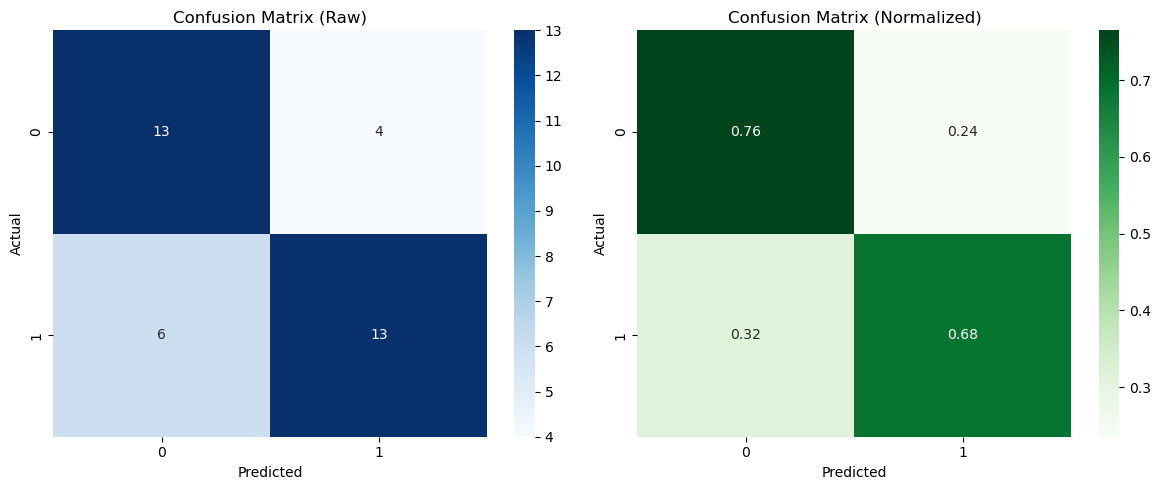

Feature Importance:
               Feature  Importance
46        z.ASRS_score    0.357693
24          Diff_Y_Max    0.160478
41  Cos2Theta_Kurtosis    0.119702
34           Angle_Min    0.110665
16      Pupil_Kurtosis    0.052372
44     Fixation_Length    0.046538
0               X_Mean    0.046292
38      Cos2Theta_Mean    0.041995
25     Diff_Y_Skewness    0.032133
49      z.ravens_score    0.032133


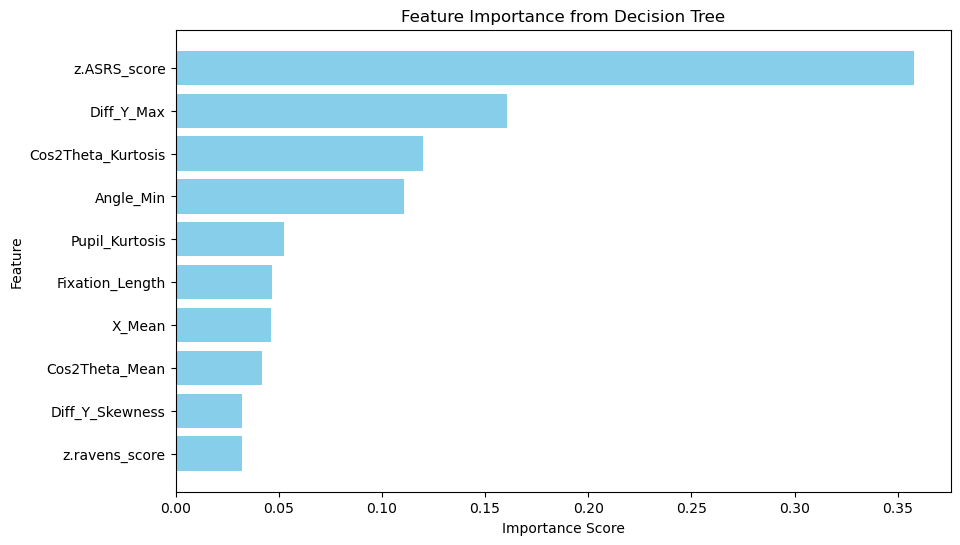

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train the Decision Tree model
DT_model = DecisionTreeClassifier()
DT_model.fit(X_train, Y_train)

# Predict on test data
Y_pred = DT_model.predict(X_test)

# Print Accuracy
print("Accuracy:", accuracy_score(Y_test, Y_pred))

# Raw Confusion Matrix
cm_raw = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:\n", cm_raw)

# Normalized Confusion Matrix
cm_norm = confusion_matrix(Y_test, Y_pred, normalize='true')
print("Normalized Confusion Matrix:\n", cm_norm)


# Visualize Raw Confusion Matrix
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Raw)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Visualize Normalized Confusion Matrix
plt.subplot(1, 2, 2)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens')
plt.title('Confusion Matrix (Normalized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()


# Get Feature Importance
feature_importance = DT_model.feature_importances_

# Convert to a DataFrame for better readability
importance_df = pd.DataFrame({'Feature': reduced_X.columns.tolist(), 'Importance': feature_importance})

# Remove features with zero importance
importance_df = importance_df[importance_df["Importance"] > 0]

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display top important features
print("Feature Importance:")
print(importance_df)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Feature Importance from Decision Tree')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.show()


In [94]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pandas as pd

# Define model
DT_model = DecisionTreeClassifier()

# Store average results for each fold setting
folds = [5, 10, 15]

for k in folds:
    print(f"\n{k}-Fold Cross-Validation:\n{'-' * 35}")
    DT_model = DecisionTreeClassifier()
    
    # Stratified splitting
    skf = StratifiedKFold(n_splits=k, shuffle=True)
    
    # Perform cross-validated predictions
    y_pred = cross_val_predict(DT_model, X, Y, cv=skf)
    
    # Classification reportLR
    report = classification_report(Y, y_pred, output_dict=True, zero_division=0)
    
    # Convert report to DataFrame
    report_df = pd.DataFrame(report).transpose()
    
    # Average metrics (excluding support and overall categories)
    avg_metrics = report_df.loc[~report_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
    avg_precision = avg_metrics['precision'].mean()
    avg_recall = avg_metrics['recall'].mean()
    avg_f1 = avg_metrics['f1-score'].mean()
    acc = accuracy_score(Y, y_pred)

    # Print metrics
    print(f"Average Precision : {avg_precision:.4f}")
    print(f"Average Recall    : {avg_recall:.4f}")
    print(f"Average F1-Score  : {avg_f1:.4f}")
    print(f"Accuracy          : {acc:.4f}")



5-Fold Cross-Validation:
-----------------------------------
Average Precision : 0.6478
Average Recall    : 0.6473
Average F1-Score  : 0.6468
Accuracy          : 0.6471

10-Fold Cross-Validation:
-----------------------------------
Average Precision : 0.7243
Average Recall    : 0.7230
Average F1-Score  : 0.7224
Accuracy          : 0.7227

15-Fold Cross-Validation:
-----------------------------------
Average Precision : 0.7321
Average Recall    : 0.7314
Average F1-Score  : 0.7309
Accuracy          : 0.7311


In [99]:
# STD of Folds
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Define model
DT_model = DecisionTreeClassifier()

# Store average results for each fold setting
folds = [5, 10, 15]

for k in folds:
    print(f"\n{k}-Fold Cross-Validation:\n{'-' * 35}")
    
    # Stratified splitting
    skf = StratifiedKFold(n_splits=k, shuffle=True)
    
    # Get accuracy scores for each fold
    scores = cross_val_score(DT_model, X, Y, cv=skf, scoring='accuracy')
    
    # Print results
    print(f"Accuracy Scores   : {np.round(scores, 4)}")
    print(f"Mean Accuracy     : {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")



5-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [0.625  0.75   0.7083 0.6667 0.6087]
Mean Accuracy     : 0.6717
Standard Deviation: 0.0522

10-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [0.6667 0.6667 0.8333 0.5833 0.5833 0.5833 0.9167 0.5    0.6667 0.7273]
Mean Accuracy     : 0.6727
Standard Deviation: 0.1192

15-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [0.25   1.     0.75   0.625  0.5    0.875  0.75   0.875  0.625  0.5
 0.625  0.875  0.75   0.5    0.7143]
Mean Accuracy     : 0.6810
Standard Deviation: 0.1868


Accuracy: 0.8055555555555556
Confusion Matrix:
 [[19  1]
 [ 6 10]]
Normalized Confusion Matrix:
 [[0.95  0.05 ]
 [0.375 0.625]]


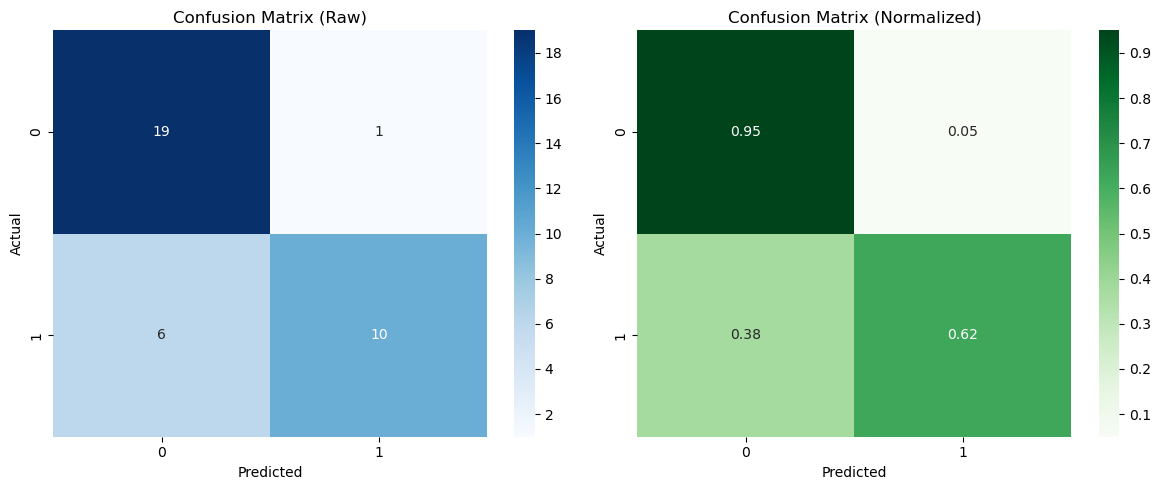

Feature Importance:
                  Feature  Importance
46           z.ASRS_score    0.178095
13              Pupil_Std    0.038572
33              Angle_Std    0.037439
2                   X_Min    0.033276
37         Angle_Kurtosis    0.033002
16         Pupil_Kurtosis    0.032906
36         Angle_Skewness    0.029860
5              X_Kurtosis    0.027140
30  Log_Velocity_Kurtosis    0.024653
7                   Y_Std    0.024437
31             Angle_Mean    0.024069
47   SymSpan.PartialScore    0.023239
32           Angle_Median    0.022887
39          Cos2Theta_Min    0.022787
24             Diff_Y_Max    0.022211
4              X_Skewness    0.020495
17            Diff_X_Mean    0.020484
12           Pupil_Median    0.019719
6                  Y_Mean    0.018890
43  Min_Cross_Correlation    0.018565
15         Pupil_Skewness    0.016962
41     Cos2Theta_Kurtosis    0.016828
0                  X_Mean    0.016761
11             Y_Kurtosis    0.015684
3                   X_Max    0

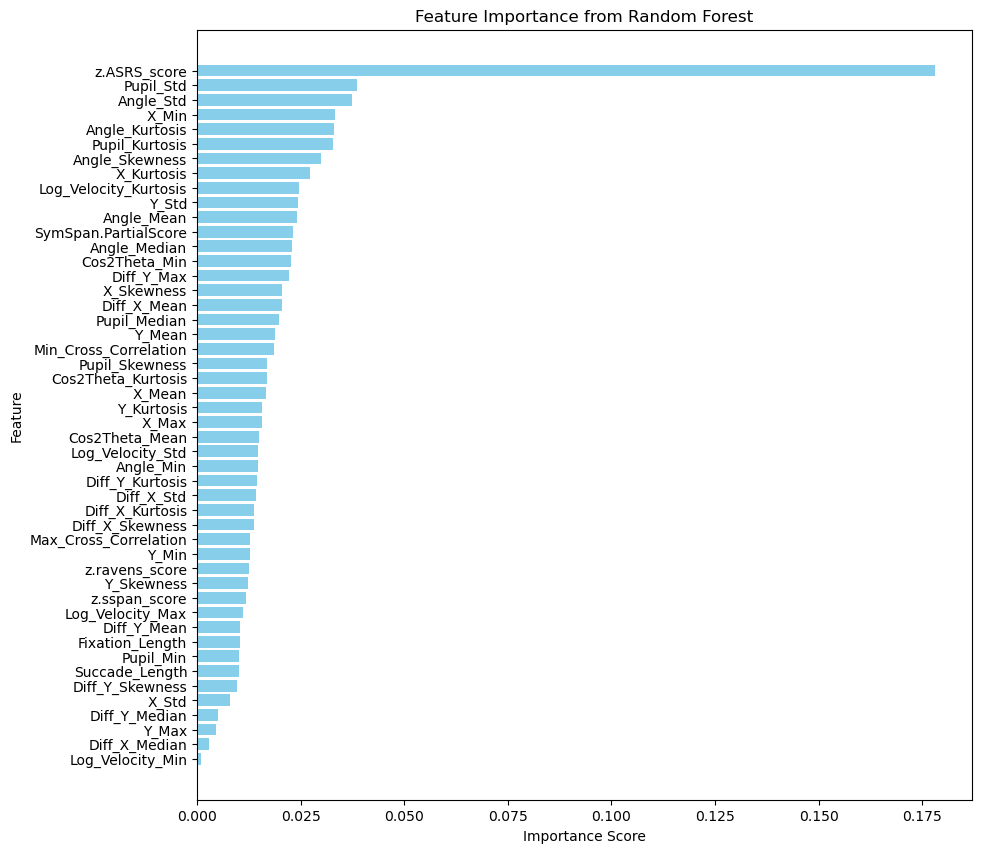

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


# Split data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, shuffle=True)

# Train the Random Forest model
RF_model = RandomForestClassifier(n_estimators=100)  # Using 100 trees
RF_model.fit(X_train, Y_train)

# Predict on test data
Y_pred = RF_model.predict(X_test)

# Print Accuracy
print("Accuracy:", accuracy_score(Y_test, Y_pred))


cm_raw = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:\n", cm_raw)

# Normalized Confusion Matrix
cm_norm = confusion_matrix(Y_test, Y_pred, normalize='true')
print("Normalized Confusion Matrix:\n", cm_norm)


# Visualize Raw Confusion Matrix
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Raw)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Visualize Normalized Confusion Matrix
plt.subplot(1, 2, 2)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens')
plt.title('Confusion Matrix (Normalized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Get Feature Importance
feature_importance = RF_model.feature_importances_

# Convert to a DataFrame for better readability
importance_df = pd.DataFrame({'Feature': reduced_X.columns.tolist(), 'Importance': feature_importance})

# Remove features with zero importance
importance_df = importance_df[importance_df["Importance"] > 0]

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display top important features
print("Feature Importance:")
print(importance_df)

# Plot Feature Importance
plt.figure(figsize=(10,10))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.show()


In [98]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pandas as pd

# Define model
RF_model = RandomForestClassifier()

# Store average results for each fold setting
folds = [5, 10, 15]

for k in folds:
    print(f"\n{k}-Fold Cross-Validation:\n{'-' * 35}")
    RF_model = RandomForestClassifier(n_estimators=100)  # Using 100 trees
    
    # Stratified splitting
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    
    # Perform cross-validated predictions
    y_pred = cross_val_predict(RF_model, X, Y, cv=skf)
    
    # Classification report
    report = classification_report(Y, y_pred, output_dict=True, zero_division=0)
    
    # Convert report to DataFrame
    report_df = pd.DataFrame(report).transpose()
    
    # Average metrics (excluding support and overall categories)
    avg_metrics = report_df.loc[~report_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
    avg_precision = avg_metrics['precision'].mean()
    avg_recall = avg_metrics['recall'].mean()
    avg_f1 = avg_metrics['f1-score'].mean()
    acc = accuracy_score(Y, y_pred)

    # Print metrics
    print(f"Average Precision : {avg_precision:.4f}")
    print(f"Average Recall    : {avg_recall:.4f}")
    print(f"Average F1-Score  : {avg_f1:.4f}")
    print(f"Accuracy          : {acc:.4f}")



5-Fold Cross-Validation:
-----------------------------------
Average Precision : 0.7750
Average Recall    : 0.7734
Average F1-Score  : 0.7729
Accuracy          : 0.7731

10-Fold Cross-Validation:
-----------------------------------
Average Precision : 0.7647
Average Recall    : 0.7647
Average F1-Score  : 0.7647
Accuracy          : 0.7647

15-Fold Cross-Validation:
-----------------------------------
Average Precision : 0.7581
Average Recall    : 0.7566
Average F1-Score  : 0.7560
Accuracy          : 0.7563


In [100]:
# STD of Folds
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Define model
RF_model = RandomForestClassifier(n_estimators=100)  # Using 100 trees

# Store average results for each fold setting
folds = [5, 10, 15]

for k in folds:
    print(f"\n{k}-Fold Cross-Validation:\n{'-' * 35}")
    
    # Stratified splitting
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    
    # Get accuracy scores for each fold
    scores = cross_val_score(RF_model, X, Y, cv=skf, scoring='accuracy')
    
    # Print results
    print(f"Accuracy Scores   : {np.round(scores, 4)}")
    print(f"Mean Accuracy     : {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")



5-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [0.875  0.6667 0.75   0.7917 0.7391]
Mean Accuracy     : 0.7645
Standard Deviation: 0.0684

10-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [0.75   0.9167 0.5833 0.6667 0.9167 0.5833 0.9167 0.75   0.75   0.8182]
Mean Accuracy     : 0.7652
Standard Deviation: 0.1217

15-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [1.     0.875  0.75   0.75   0.625  0.75   0.875  0.875  0.5    0.875
 0.875  0.625  0.625  0.875  0.8571]
Mean Accuracy     : 0.7821
Standard Deviation: 0.1321


Accuracy: 0.7777777777777778
Confusion Matrix:
 [[12  4]
 [ 4 16]]
Normalized Confusion Matrix:
 [[0.75 0.25]
 [0.2  0.8 ]]


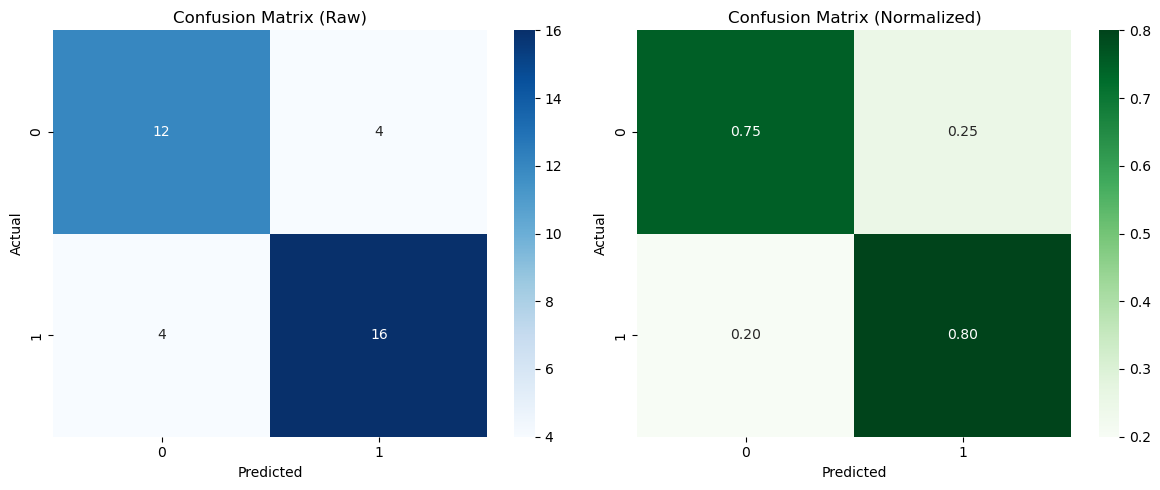

Feature Importance:
                  Feature    Importance
0                  X_Mean  3.894804e-07
14              Pupil_Min  1.469436e-06
20        Diff_X_Skewness  1.579015e-05
29       Log_Velocity_Max  2.801507e-05
43  Min_Cross_Correlation  5.967828e-05
15         Pupil_Skewness  1.138156e-04
10             Y_Skewness  1.391686e-04
32           Angle_Median  1.563206e-04
34              Angle_Min  2.048997e-04
3                   X_Max  2.270370e-04
11             Y_Kurtosis  3.967046e-04
44        Fixation_Length  7.419927e-04
18          Diff_X_Median  1.653874e-03
17            Diff_X_Mean  2.129569e-03
19             Diff_X_Std  2.248661e-03
36         Angle_Skewness  2.268595e-03
42  Max_Cross_Correlation  2.270655e-03
45         Succade_Length  2.466931e-03
26        Diff_Y_Kurtosis  2.525123e-03
21        Diff_X_Kurtosis  2.880978e-03
4              X_Skewness  3.315392e-03
27       Log_Velocity_Std  3.903619e-03
22            Diff_Y_Mean  3.990673e-03
5              X_Kur

<function matplotlib.pyplot.xlabel(xlabel, fontdict=None, labelpad=None, *, loc=None, **kwargs)>

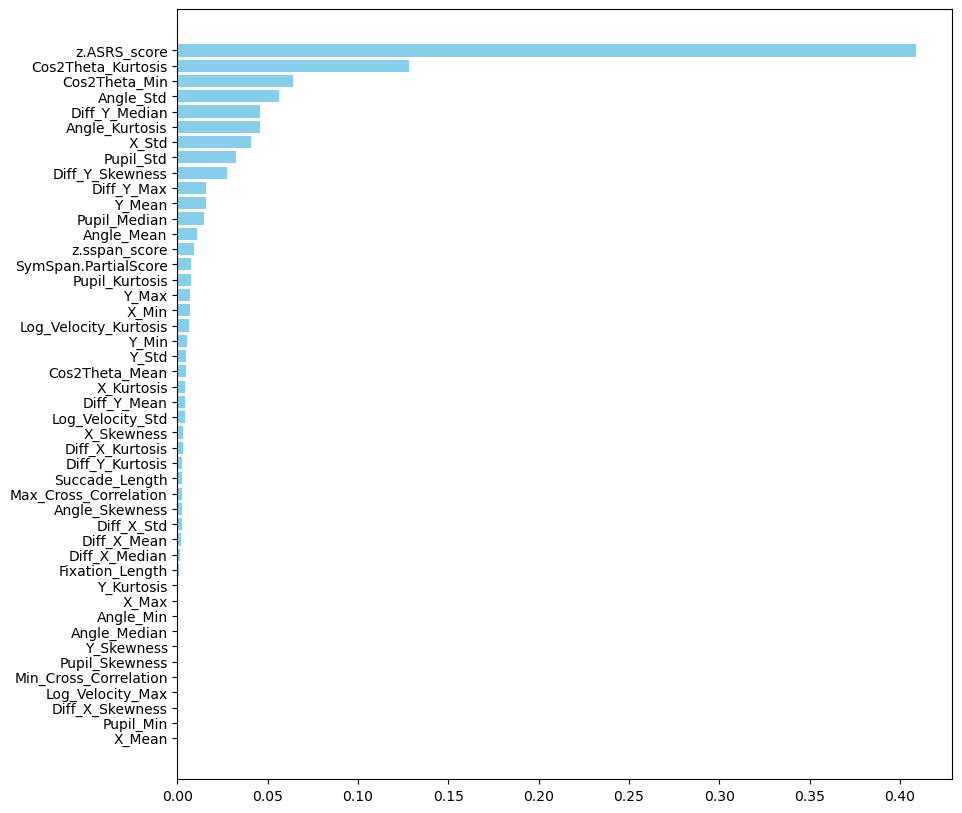

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, shuffle=True, random_state=42)

# Train the Gradient Boosting model
GB_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
GB_model.fit(X_train, Y_train)

# Predict on test data
Y_pred = GB_model.predict(X_test)

# Print Accuracy
print("Accuracy:", accuracy_score(Y_test, Y_pred))

# Raw Confusion Matrix
cm_raw = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:\n", cm_raw)

# Normalized Confusion Matrix
cm_norm = confusion_matrix(Y_test, Y_pred, normalize='true')
print("Normalized Confusion Matrix:\n", cm_norm)

# Visualize Confusion Matrices
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Raw)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1, 2, 2)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens')
plt.title('Confusion Matrix (Normalized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Get Feature Importance
feature_importance = GB_model.feature_importances_

# Convert to a DataFrame
importance_df = pd.DataFrame({
    'Feature': reduced_X.columns.tolist(),
    'Importance': feature_importance
})

# Filter out zero importance features
importance_df = importance_df[importance_df['Importance'] > 0]

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=True)

# Display top important features
print("Feature Importance:")
print(importance_df)

# Plot Feature Importance
plt.figure(figsize=(10, 10))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel


In [100]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import pandas as pd

# Define model
GB_model = GradientBoostingClassifier()

# Store average results for each fold setting
folds = [5, 10, 15]

for k in folds:
    print(f"\n{k}-Fold Cross-Validation:\n{'-' * 35}")
    GB_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
    
    # Stratified splitting
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    
    # Perform cross-validated predictions
    y_pred = cross_val_predict(GB_model, X, Y, cv=skf)
    
    # Classification report
    report = classification_report(Y, y_pred, output_dict=True, zero_division=0)
    
    # Convert report to DataFrame
    report_df = pd.DataFrame(report).transpose()
    
    # Average metrics (excluding support and overall categories)
    avg_metrics = report_df.loc[~report_df.index.isin(['accuracy', 'macro avg', 'weighted avg'])]
    avg_precision = avg_metrics['precision'].mean()
    avg_recall = avg_metrics['recall'].mean()
    avg_f1 = avg_metrics['f1-score'].mean()
    acc = accuracy_score(Y, y_pred)

    # Print metrics
    print(f"Average Precision : {avg_precision:.4f}")
    print(f"Average Recall    : {avg_recall:.4f}")
    print(f"Average F1-Score  : {avg_f1:.4f}")
    print(f"Accuracy          : {acc:.4f}")



5-Fold Cross-Validation:
-----------------------------------
Average Precision : 0.7279
Average Recall    : 0.7233
Average F1-Score  : 0.7214
Accuracy          : 0.7227

10-Fold Cross-Validation:
-----------------------------------
Average Precision : 0.7401
Average Recall    : 0.7397
Average F1-Score  : 0.7394
Accuracy          : 0.7395

15-Fold Cross-Validation:
-----------------------------------
Average Precision : 0.7153
Average Recall    : 0.7145
Average F1-Score  : 0.7141
Accuracy          : 0.7143


In [92]:
# STD of Folds
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Define model
GB_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Store average results for each fold setting
folds = [5, 10, 15]

for k in folds:
    print(f"\n{k}-Fold Cross-Validation:\n{'-' * 35}")
    
    # Stratified splitting
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    
    # Get accuracy scores for each fold
    scores = cross_val_score(GB_model, X, Y, cv=skf, scoring='accuracy')
    
    # Print results
    print(f"Accuracy Scores   : {np.round(scores, 4)}")
    print(f"Mean Accuracy     : {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")



5-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [0.875  0.5417 0.6667 0.7083 0.8261]
Mean Accuracy     : 0.7236
Standard Deviation: 0.1183

10-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [0.75   0.8333 0.6667 0.5833 0.75   0.5    0.8333 0.5833 0.75   0.9091]
Mean Accuracy     : 0.7159
Standard Deviation: 0.1235

15-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [0.875  0.875  0.75   0.75   0.5    0.5    0.875  0.75   0.375  0.75
 0.75   0.625  0.75   0.875  0.8571]
Mean Accuracy     : 0.7238
Standard Deviation: 0.1516


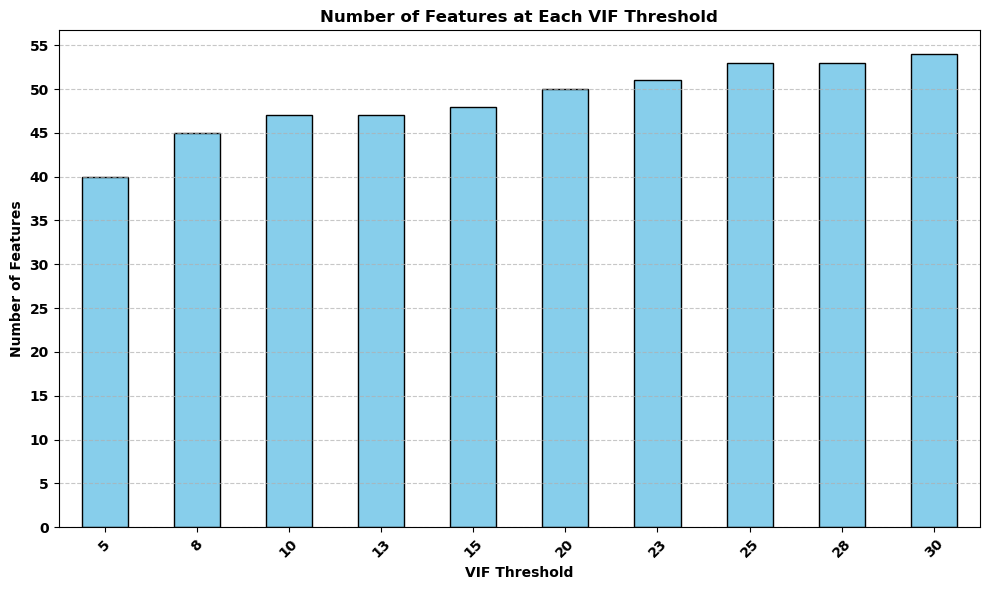

In [101]:
# VIF plot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the Excel file
df = pd.read_excel('VIF.xlsx')

# Count non-NaN values in each column
non_nan_counts = df.notna().sum()

# Plotting the bar chart
plt.figure(figsize=(10, 6))
non_nan_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Set bold font for title and labels
plt.title('Number of Features at Each VIF Threshold', fontweight='bold')
plt.xlabel('VIF Threshold', fontweight='bold')
plt.ylabel('Number of Features', fontweight='bold')

# Make x-tick and y-tick labels bold
plt.xticks(rotation=45, fontweight='bold')

# Set y-axis ticks in steps of 5
max_y = non_nan_counts.max()
plt.yticks(np.arange(0, max_y + 5, 5), fontweight='bold')

# Final layout adjustments
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [117]:
X_train.shape

(83, 50)

In [119]:
X_test.shape

(36, 50)


Naive Bayes Results
Accuracy: 0.6111111111111112
Confusion Matrix:
 [[13  4]
 [10  9]]
Normalized Confusion Matrix:
 [[0.76470588 0.23529412]
 [0.52631579 0.47368421]]


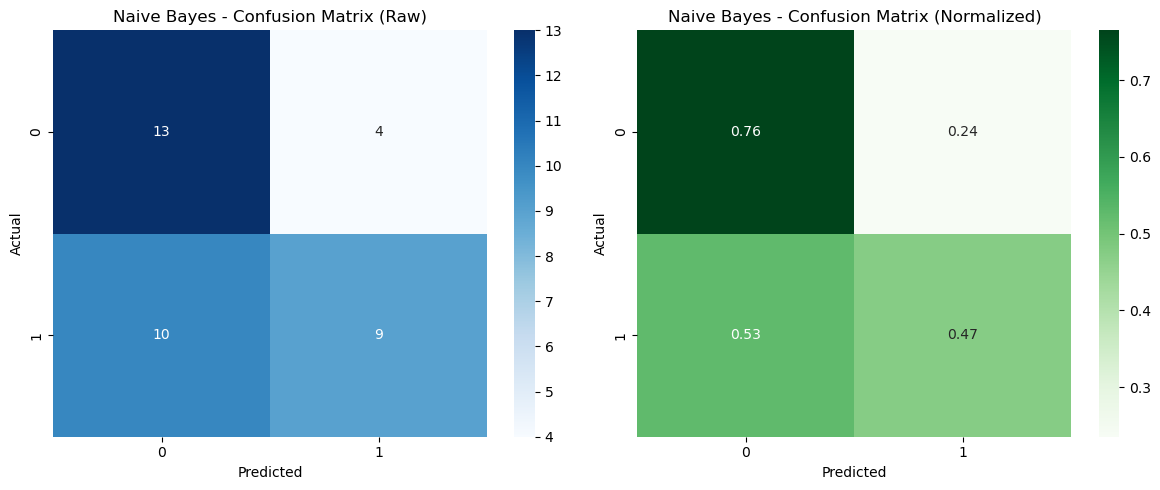


SVM Results
Accuracy: 0.6111111111111112
Confusion Matrix:
 [[12  1]
 [13 10]]
Normalized Confusion Matrix:
 [[0.92307692 0.07692308]
 [0.56521739 0.43478261]]


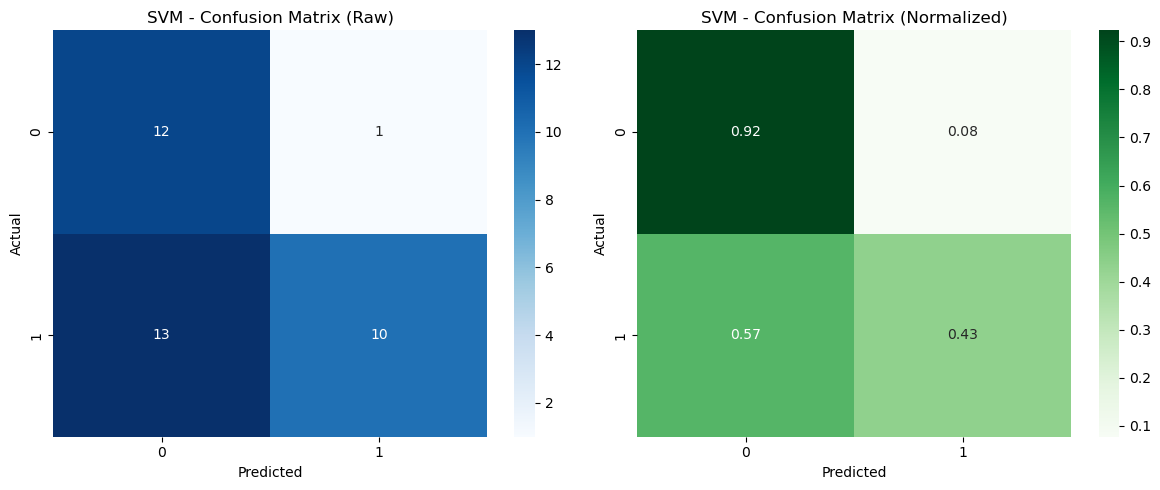

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Function to plot confusion matrices
def plot_conf_matrices(y_true, y_pred, title_prefix="Model"):
    cm_raw = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

    print("Confusion Matrix:\n", cm_raw)
    print("Normalized Confusion Matrix:\n", cm_norm)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{title_prefix} - Confusion Matrix (Raw)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.subplot(1, 2, 2)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens')
    plt.title(f'{title_prefix} - Confusion Matrix (Normalized)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.tight_layout()
    plt.show()

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, shuffle=True)

# === Naive Bayes ===
nb_model = GaussianNB()
nb_model.fit(X_train, Y_train)
nb_preds = nb_model.predict(X_test)
print("\nNaive Bayes Results")
print("Accuracy:", accuracy_score(Y_test, nb_preds))
#print(classification_report(Y_test, nb_preds))
plot_conf_matrices(Y_test, nb_preds, "Naive Bayes")

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, shuffle=True)

# === SVM ===
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, Y_train)
svm_preds = svm_model.predict(X_test)
print("\nSVM Results")
print("Accuracy:", accuracy_score(Y_test, svm_preds))
#print(classification_report(Y_test, svm_preds))
plot_conf_matrices(Y_test, svm_preds, "SVM")



In [110]:
import numpy as np
from sklearn.metrics import log_loss

def compute_aic_bic(model, X_test, Y_test, model_name="Model"):
    """
    Compute AIC and BIC from predicted probabilities for classification models.
    Assumes model has `predict_proba`.
    """
    n = len(Y_test)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
        eps = 1e-15
        log_likelihood = np.sum(np.log(proba[range(n), Y_test] + eps))
    else:
        raise ValueError(f"{model_name} does not support predict_proba")

    # Estimate number of parameters
    try:
        k = model.coef_.size + 1  # +1 for intercept
    except AttributeError:
        # For Naive Bayes: k ≈ features * classes
        k = X_test.shape[1] * len(np.unique(Y_test))

    aic = 2 * k - 2 * log_likelihood
    bic = np.log(n) * k - 2 * log_likelihood

    print(f"{model_name} - AIC: {aic:.2f}, BIC: {bic:.2f}")


In [111]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, Y_train)
compute_aic_bic(log_model, X_test, Y_test, model_name="Logistic Regression")

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, Y_train)
compute_aic_bic(nb_model, X_test, Y_test, model_name="Naive Bayes")


Logistic Regression - AIC: 149.39, BIC: 230.15
Naive Bayes - AIC: 313.94, BIC: 472.29


In [105]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# List of folds
folds = [5, 10, 15]

# Loop over each fold configuration
for k in folds:
    print(f"\n{k}-Fold Cross-Validation:\n{'-' * 35}")
    
    # Define model
    nb_model = GaussianNB()
    
    # Define stratified KFold
    skf = StratifiedKFold(n_splits=k, shuffle=True)
    
    # Perform cross-validated predictions
    y_pred = cross_val_predict(nb_model, X, Y, cv=skf)
    
    # Generate classification report
    report = classification_report(Y, y_pred, output_dict=True, zero_division=0)
    
    # Convert report to DataFrame
    report_df = pd.DataFrame(report).transpose()
    
    # Extract macro avg and accuracy directly
    macro_avg = report["macro avg"]
    acc = accuracy_score(Y, y_pred)

    # Print metrics
    print(f"Accuracy          : {acc:.4f}")
    print(f"Macro Precision   : {macro_avg['precision']:.4f}")
    print(f"Macro Recall      : {macro_avg['recall']:.4f}")
    print(f"Macro F1-Score    : {macro_avg['f1-score']:.4f}")



5-Fold Cross-Validation:
-----------------------------------
Accuracy          : 0.6303
Macro Precision   : 0.6303
Macro Recall      : 0.6301
Macro F1-Score    : 0.6300

10-Fold Cross-Validation:
-----------------------------------
Accuracy          : 0.7143
Macro Precision   : 0.7145
Macro Recall      : 0.7141
Macro F1-Score    : 0.7141

15-Fold Cross-Validation:
-----------------------------------
Accuracy          : 0.6975
Macro Precision   : 0.6977
Macro Recall      : 0.6973
Macro F1-Score    : 0.6973


In [105]:
# STD of Folds
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Define model
nb_model = GaussianNB()

# List of folds
folds = [5, 10, 15]

# Loop over each fold configuration
for k in folds:
    print(f"\n{k}-Fold Cross-Validation:\n{'-' * 35}")
    
    # Stratified splitting
    skf = StratifiedKFold(n_splits=k, shuffle=True)
    
    # Get accuracy scores for each fold
    scores = cross_val_score(nb_model, X, Y, cv=skf, scoring='accuracy')
    
    # Print results
    print(f"Accuracy Scores   : {np.round(scores, 4)}")
    print(f"Mean Accuracy     : {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")



5-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [0.5    0.5833 0.6667 0.5833 0.7826]
Mean Accuracy     : 0.6232
Standard Deviation: 0.0956

10-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [0.5833 0.8333 0.6667 0.8333 0.75   0.6667 0.6667 0.5833 0.5833 0.9091]
Mean Accuracy     : 0.7076
Standard Deviation: 0.1120

15-Fold Cross-Validation:
-----------------------------------
Accuracy Scores   : [0.75   0.5    0.875  0.625  0.75   0.75   0.75   0.75   0.875  0.75
 0.75   0.625  0.875  0.375  0.7143]
Mean Accuracy     : 0.7143
Standard Deviation: 0.1325


In [106]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# List of folds
folds = [5, 10, 15]

# Loop through each fold setting
for k in folds:
    print(f"\n{k}-Fold Cross-Validation (SVM):\n{'-' * 40}")
    
    # Define the SVM model
    svm_model = SVC(kernel='rbf')  # You can change to 'linear' if needed
    
    # Define stratified k-fold
    skf = StratifiedKFold(n_splits=k, shuffle=True)
    
    # Perform cross-validated prediction
    y_pred = cross_val_predict(svm_model, X, Y, cv=skf)
    
    # Classification report
    report = classification_report(Y, y_pred, output_dict=True, zero_division=0)
    
    # Accuracy and macro-average
    acc = accuracy_score(Y, y_pred)
    macro_avg = report["macro avg"]

    # Print metrics
    print(f"Accuracy          : {acc:.4f}")
    print(f"Macro Precision   : {macro_avg['precision']:.4f}")
    print(f"Macro Recall      : {macro_avg['recall']:.4f}")
    print(f"Macro F1-Score    : {macro_avg['f1-score']:.4f}")



5-Fold Cross-Validation (SVM):
----------------------------------------
Accuracy          : 0.6975
Macro Precision   : 0.6975
Macro Recall      : 0.6975
Macro F1-Score    : 0.6975

10-Fold Cross-Validation (SVM):
----------------------------------------
Accuracy          : 0.7227
Macro Precision   : 0.7233
Macro Recall      : 0.7229
Macro F1-Score    : 0.7226

15-Fold Cross-Validation (SVM):
----------------------------------------
Accuracy          : 0.7143
Macro Precision   : 0.7153
Macro Recall      : 0.7145
Macro F1-Score    : 0.7141


In [106]:
# STD of Folds for SVM
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# List of folds
folds = [5, 10, 15]

# Loop through each fold setting
for k in folds:
    print(f"\n{k}-Fold Cross-Validation (SVM):\n{'-' * 40}")
    
    # Define the SVM model
    svm_model = SVC(kernel='rbf')  # You can change to 'linear' if needed
    
    # Define stratified k-fold
    skf = StratifiedKFold(n_splits=k, shuffle=True)
    
    # Get accuracy scores for each fold
    scores = cross_val_score(svm_model, X, Y, cv=skf, scoring='accuracy')
    
    # Print metrics
    print(f"Accuracy Scores   : {np.round(scores, 4)}")
    print(f"Mean Accuracy     : {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")



5-Fold Cross-Validation (SVM):
----------------------------------------
Accuracy Scores   : [0.7917 0.7917 0.625  0.5833 0.6957]
Mean Accuracy     : 0.6975
Standard Deviation: 0.0849

10-Fold Cross-Validation (SVM):
----------------------------------------
Accuracy Scores   : [0.5833 0.6667 0.8333 0.5    0.8333 0.5833 0.8333 0.75   0.75   0.7273]
Mean Accuracy     : 0.7061
Standard Deviation: 0.1127

15-Fold Cross-Validation (SVM):
----------------------------------------
Accuracy Scores   : [0.75   0.625  1.     0.75   0.875  0.625  0.75   0.875  0.625  0.75
 0.375  0.25   0.75   0.875  0.7143]
Mean Accuracy     : 0.7060
Standard Deviation: 0.1860


In [127]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100)
}

for name, model in models.items():
    print(f"\n{name} Parameters:")
    for param, value in model.get_params().items():
        print(f"  {param}: {value}")



Logistic Regression Parameters:
  C: 1.0
  class_weight: None
  dual: False
  fit_intercept: True
  intercept_scaling: 1
  l1_ratio: None
  max_iter: 100
  multi_class: auto
  n_jobs: None
  penalty: l2
  random_state: None
  solver: lbfgs
  tol: 0.0001
  verbose: 0
  warm_start: False

Naive Bayes Parameters:
  priors: None
  var_smoothing: 1e-09

Decision Tree Parameters:
  ccp_alpha: 0.0
  class_weight: None
  criterion: gini
  max_depth: None
  max_features: None
  max_leaf_nodes: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 2
  min_weight_fraction_leaf: 0.0
  random_state: None
  splitter: best

Random Forest Parameters:
  bootstrap: True
  ccp_alpha: 0.0
  class_weight: None
  criterion: gini
  max_depth: None
  max_features: sqrt
  max_leaf_nodes: None
  max_samples: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 2
  min_weight_fraction_leaf: 0.0
  n_estimators: 100
  n_jobs: None
  oob_score: False
  random_state: N

In [128]:
X_vif=X_bak
X_vif = np.asarray(X_vif)
X_vif_df = pd.DataFrame(X_vif, columns=Feature_names)


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_inf

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_inf

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_inf

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\

VIF Threshold = 5: Accuracy = 0.7062
VIF Threshold = 10: Accuracy = 0.7460
VIF Threshold = 15: Accuracy = 0.6812
VIF Threshold = 20: Accuracy = 0.7395
VIF Threshold = 25: Accuracy = 0.7141
VIF Threshold = 30: Accuracy = 0.7315
VIF Threshold = 35: Accuracy = 0.6975
VIF Threshold = 40: Accuracy = 0.7141
VIF Threshold = 45: Accuracy = 0.7069
VIF Threshold = 50: Accuracy = 0.6895


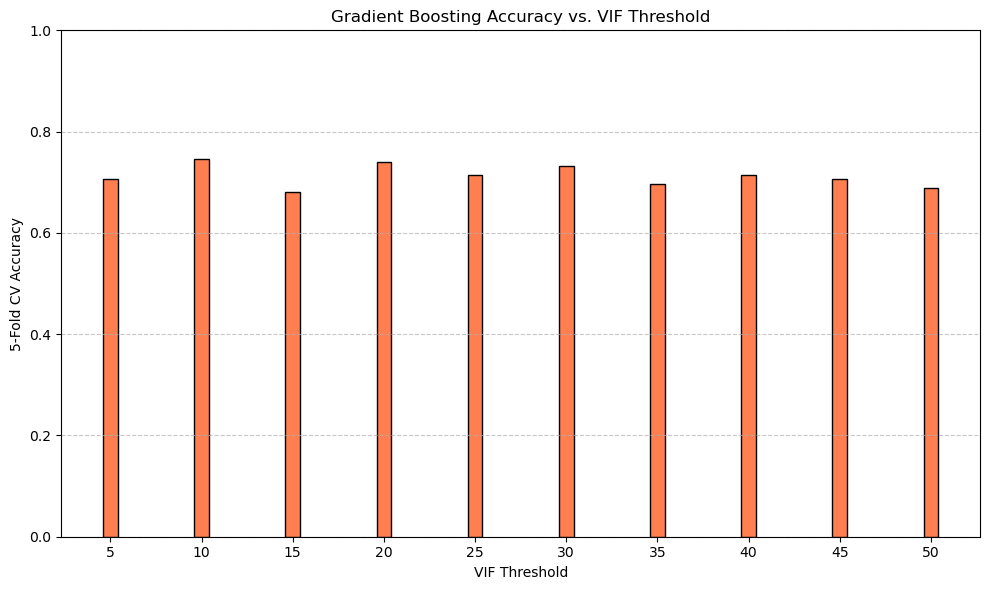

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Step 1: Scale and clean the data
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_vif_df), columns=X_vif_df.columns)

# Remove inf and NaNs
X_scaled.replace([np.inf, -np.inf], np.nan, inplace=True)
X_scaled.dropna(inplace=True)
Y_cleaned = Y.loc[X_scaled.index] if isinstance(Y, pd.Series) else Y[np.array(X_scaled.index)]

# Step 2: VIF calculation function with error handling
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns
    vif_values = []
    for i in range(X.shape[1]):
        try:
            vif_val = variance_inflation_factor(X.values, i)
            if np.isnan(vif_val) or np.isinf(vif_val):
                vif_val = np.nan
        except:
            vif_val = np.nan
        vif_values.append(vif_val)
    vif_data['VIF'] = vif_values
    return vif_data

# Step 3: Apply VIF thresholds and evaluate Gradient Boosting
vif_thresholds = range(5, 55, 5)
accuracy_results = []

for thresh in vif_thresholds:
    X_selected = X_scaled.copy()

    # Remove features with VIF above threshold
    while True:
        vif = calculate_vif(X_selected).dropna()
        if vif.empty:
            break
        max_vif = vif['VIF'].max()
        if max_vif > thresh:
            drop_feature = vif.sort_values('VIF', ascending=False).iloc[0]['feature']
            X_selected.drop(columns=[drop_feature], inplace=True)
        else:
            break

    if X_selected.shape[1] == 0:
        accuracy_results.append(np.nan)
        continue

    # Gradient Boosting Classifier with 10-fold cross-validation
    gbc = GradientBoostingClassifier(n_estimators=100)
    cv = StratifiedKFold(n_splits=5, shuffle=True)
    scores = cross_val_score(gbc, X_selected, Y_cleaned, cv=cv, scoring='accuracy')
    accuracy_results.append(scores.mean())

# Step 4: Show results
for thresh, acc in zip(vif_thresholds, accuracy_results):
    print(f"VIF Threshold = {thresh}: Accuracy = {acc:.4f}")

# Step 5: Bar chart of accuracy results vs VIF thresholds
plt.figure(figsize=(10, 6))
plt.bar(vif_thresholds, accuracy_results, color='coral', edgecolor='black')
plt.title('Gradient Boosting Accuracy vs. VIF Threshold')
plt.xlabel('VIF Threshold')
plt.ylabel('5-Fold CV Accuracy')
plt.xticks(vif_thresholds)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Step 1: Scale and clean the data
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_vif_df), columns=X_vif_df.columns)

# Remove inf and NaNs
X_scaled.replace([np.inf, -np.inf], np.nan, inplace=True)
X_scaled.dropna(inplace=True)
Y_cleaned = Y.loc[X_scaled.index] if isinstance(Y, pd.Series) else Y[np.array(X_scaled.index)]

# Step 2: VIF calculation function with error handling
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns
    vif_values = []
    for i in range(X.shape[1]):
        try:
            vif_val = variance_inflation_factor(X.values, i)
            if np.isnan(vif_val) or np.isinf(vif_val):
                vif_val = np.nan
        except:
            vif_val = np.nan
        vif_values.append(vif_val)
    vif_data['VIF'] = vif_values
    return vif_data

# Step 3: Apply VIF thresholds and evaluate Gradient Boosting
vif_thresholds = range(5, 55, 5)
accuracy_results = []

for thresh in vif_thresholds:
    X_selected = X_scaled.copy()

    # Remove features with VIF above threshold
    while True:
        vif = calculate_vif(X_selected).dropna()
        if vif.empty:
            break
        max_vif = vif['VIF'].max()
        if max_vif > thresh:
            drop_feature = vif.sort_values('VIF', ascending=False).iloc[0]['feature']
            X_selected.drop(columns=[drop_feature], inplace=True)
        else:
            break

    if X_selected.shape[1] == 0:
        accuracy_results.append(np.nan)
        continue

    # Random Forest Classifier with 5-fold cross-validation
    rfc = RandomForestClassifier()
    cv = StratifiedKFold(n_splits=5, shuffle=True)
    scores = cross_val_score(rfc, X_selected, Y_cleaned, cv=cv, scoring='accuracy')
    accuracy_results.append(scores.mean())



C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_inf

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_inf

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_inf

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\

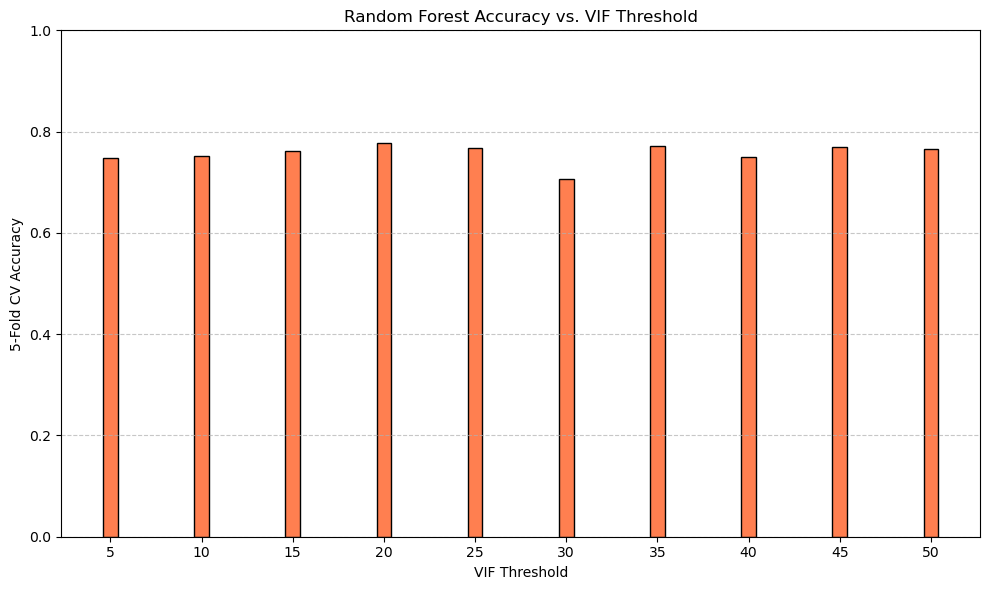

In [148]:
# Step 5: Bar chart of accuracy results vs VIF thresholds
plt.figure(figsize=(10, 6))
plt.bar(vif_thresholds, accuracy_results, color='coral', edgecolor='black')
plt.title('Random Forest Accuracy vs. VIF Threshold')
plt.xlabel('VIF Threshold')
plt.ylabel('5-Fold CV Accuracy')
plt.xticks(vif_thresholds)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
